# Automation and Affordability in U.S. Counties

Is the task composition of local work associated with what residents can afford?

Chris Bell  
Julian Pacheco

In [1]:
import os
import sys
os.environ["R_HOME"]=os.path.join(sys.prefix, "lib", "R")
%load_ext rpy2.ipython
import rpy2.robjects as ro
from great_tables import style, loc
ro.r('''
suppressMessages({
  library(ggplot2)
  library(patchwork)
  library(scales)
})

BLUE <- "#2A78D6"
ORANGE <- "#EB6834"
GREEN <- "#1BAF7A"
PINK <- "#C2255C"
GREY <- "#8F8D87"

# Reserve colors, available if a new semantic group needs its own. Raw hex,
# unvalidated. RED is in active use for the fig-diagnostics loess trend line.
RED <- "#F21A00"
PURPLE <- "#35274A"
FOREST <- "#0B775E"
BROWN <- "#79402E"
MAGENTA <- "#E6A0C4"

# Task groups and purchasing power. Scoped to these five categorical series
# only; lightness varies within each hue family so the same-family pairs stay
# distinguishable under red-green color vision deficiency. Purchasing power sits
# on its own hue, outside both task families, since it is the outcome.
PP_PURPLE <- "#8659C4"
RC_TEAL <- "#51C3CC"
RM_TEAL <- "#006666"
NRC_ORANGE <- "#FFAD65"
NRM_ORANGE <- "#993F00"
TASK_COLORS <- c(
  "Purchasing Power" = PP_PURPLE,
  "Routine Cognitive" = RC_TEAL,
  "Routine Manual" = RM_TEAL,
  "Non-Routine Cognitive" = NRC_ORANGE,
  "Non-Routine Manual" = NRM_ORANGE
  )

# Dollar axis labels, used by every figure reporting purchasing power.
dollar_axis <- function(v) ifelse(is.na(v), "", ifelse(v == 0, "$0",
  sprintf("%s$%s", ifelse(v < 0, "-", ""), formatC(abs(v), format="d", big.mark=","))))

theme_set(
  theme_minimal(base_size=9.5) +
    theme(
      panel.background=element_rect(fill=NA, color=NA),
      plot.background=element_rect(fill=NA, color=NA),
      panel.grid=element_blank(),
      plot.title=element_text(face="bold", size=13, color="#0B0B0B", hjust=0.5, margin=margin(b=4)),
      plot.subtitle=element_text(size=8.5, color="#52514E", margin=margin(b=8)),
      strip.background=element_blank(),
      strip.text=element_text(face="bold", size=9, color="#0B0B0B"),
      axis.line=element_line(color="#0B0B0B", linewidth=0.4),
      axis.ticks=element_blank(),
      axis.text=element_text(size=9, color="#0B0B0B", face="bold"),
      axis.title=element_text(size=9.5, color="#0B0B0B"),
      legend.position="bottom",
      legend.title=element_blank(),
      legend.text=element_text(size=8.5, color="#0B0B0B"),
      legend.key=element_blank(),
      plot.margin=margin(10, 14, 8, 10)
    )
)
''')

def style_table(gt):
    """Shared table typography, applied to every GT table in the report so table
    text reads clearly smaller than body prose (great_tables defaults to 16px,
    matching body text)."""
    return gt.tab_options(
        table_font_size="12.5px",
        table_background_color="transparent",
        heading_title_font_size="14px",
        heading_subtitle_font_size="12px",
        column_labels_font_size="12.5px",
        column_labels_font_weight="bold",
        source_notes_font_size="10.5px",
    ).tab_style(
        style=style.text(style="italic"),
        locations=loc.source_notes(),
    )

R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: package ‘ggplot2’ was built under R version 4.5.3 
  

# Introduction

According to Gallup, 22% of American workers worried technology would make their job obsolete in 2023, up seven percentage points from 2021 ([Saad 2023](#ref-Gallup2023)). Concerns about automation were evident years earlier. In 2017, the Pew Research Center reported that 72% of Americans surveyed worried about a future in which technology could perform many jobs currently done by humans ([Smith and Anderson 2017](#ref-Pew2017)).Underlying these concerns was automation, in which technology assumes tasks that were previously performed by human workers. These concerns have a clear economic basis. Job displacement can result in large and long-lasting reductions in worker earnings ([Couch and Placzek 2010](#ref-CouchPlaczek2010)).

A study found that displaced worker’s earnings fell by more than 30% from 1993 to 2004, remaining about 15% lower six years later([Cozzi and Fella 2016](#ref-CozziFella2016)). The burden of those earnings losses depended in part on local prices. As demonstrated by Moretti ([2013](#ref-Moretti2013)), the same income could support different living standards in different cities in the united states. This variation also makes the geographic scale of measurement important. As a result, a single value representing an entire state or metropolitan area can obscure the variations in prices and household resources across different communities. For this reason, measuring these conditions locally provides a more realistic view of where households face greater economic strain ([Curran et al. 2006](#ref-Curran2006)).

Examining whether these concerns corresponded with local economic conditions required a measurable indicator of automation risk. Autor’s task based framework provided the basis for measuring automation risk through the tasks performed in local labor markets. Autor, Levy, and Murnane ([2003](#ref-Autor2003)) first demonstrated that computers replaced routine tasks while complementing non-routine ones, which made it possible to identify work more susceptible to automation. Acemoglu and Autor ([2011](#ref-AcemogluAutor2011)) later expanded the framework by treating tasks as the production unit and different skill groups as their suppliers. Autor and Dorn ([2013](#ref-AutorDorn2013)) then applied the framework to local labor markets, finding that areas concentrated in routine work experienced employment polarization.

Building on this task based framework, we investigated the relationship between county automation and purchasing power, which is defined as household income adjusted for variations in local price levels. The analysis used a county-level panel spanning from 2008 to 2023, excluding the year 2020, encompassing 11,983 observations across 840 counties. These counties collectively represented a substantial portion of the U.S. population, reaching approximately 84% ([U.S. Census Bureau 2023b](#ref-census_popest2023)). County employment was organized into four task groups to capture differences in the kinds of work performed across local economies.

We conducted a panel regression analysis to investigate the relationship between purchasing power and county task groups, while controlling for factors such as poverty, unemployment, and population. Year indicators accounted for changes over time, and standard errors were clustered by county for statistical inference. Diagnostic checks favored a log specification, while random forest and neural network models assessed whether nonlinear relationships captured patterns missed by the regression model. The most notable finding was that a one percentage point shift from non-routine cognitive to non-routine manual work was associated with approximately \$846 less purchasing power at the panel mean (95% confidence interval, ±\$38). Task groups remained associated with purchasing power after accounting for poverty and unemployment. These findings have practical implications for policymakers and economic development agencies by helping identify counties that appear similar on conventional indicators but differ in what residents can afford.

# Background

Autor developed a task-based approach to measure the variation in automation risk across different types of work. Initially, Autor, Levy, and Murnane ([2003](#ref-Autor2003)) distinguished between routine and non-routine tasks by demonstrating that technology impacts tasks differently based on their potential to be formalized into explicit procedures. Acemoglu and Autor ([2011](#ref-AcemogluAutor2011)) further expanded his framework by treating tasks as production units and analyzing how workers with varying skills are distributed among them. This progression laid the conceptual foundation for the four task groups depicted in Figure 1, linking technological advancements to shifts in the demand for different types of work.

Building upon this framework, Autor and Dorn ([2013](#ref-AutorDorn2013)) applied the task-based approach to local labor markets. Areas with higher initial concentrations of routine work experienced more pronounced employment polarization. Employment growth was observed at both the upper and lower ends of the wage distribution, while it declined in the middle. These patterns indicated that the local impacts of technological change varied depending on the types of tasks concentrated within each economy. This provided a foundation for exploring whether differences in county task groups were also linked to variations in purchasing power.

In [2]:
import os
import numpy as np
import pandas as pd
from sqlalchemy import create_engine, text

# This is the one cell in the writeup that reads the data lake rather than the
# warehouse: autorack stores only the four aggregated groups, and this figure needs
# the detailed occupations underneath them.
if not os.environ.get("THOMAS_URL"):
    raise RuntimeError(
        "THOMAS_URL is not set. fig-taskframework reads the detailed occupation list "
        "from the thomas data lake, which autorack does not store."
    )
lake=create_engine(os.environ["THOMAS_URL"], pool_pre_ping=True, pool_recycle=300)
with lake.connect() as conn:
    occ=pd.read_sql(text("select soc_code, title from occupation_crosswalk order by soc_code"),
                    conn)
lake.dispose()

# the live occupation to task group assignment, matching sql_final_erd.sql in the
# companion workbook repository, applied at the Standard Occupational Classification
# major group. Community and social service (21) and military (55) are deliberately
# absent: they are assigned to no group and do not enter the four group total. Two
# major groups split internally, as the American Community Survey categories do.
NRC="Non-Routine Cognitive"
NRM="Non-Routine Manual"
RC="Routine Cognitive"
RM="Routine Manual"
major={"11":NRC,"13":NRC,"15":NRC,"17":NRC,"19":NRC,"23":NRC,"25":NRC,"27":NRC,
       "31":NRM,"33":NRM,"35":NRM,"37":NRM,"39":NRM,
       "41":RC,"43":RC,
       "45":RM,"47":RM,"49":RM,"51":RM}

def assign(code):
    """healthcare practitioners (29-1) are non-routine cognitive while health
    technicians (29-2) are non-routine manual; material moving (53-7) is routine
    manual while the rest of transportation is non-routine manual."""
    mg=code[:2]
    if mg=="29": return NRC if code[3]=="1" else NRM
    if mg=="53": return RM if code[3]=="7" else NRM
    return major.get(mg)

occ["group"]=occ.soc_code.map(assign)
occ=occ[occ.group.notna()].reset_index(drop=True)

# quadrant sign: x is manual (negative) to cognitive (positive), y is routine
# (negative) to non-routine (positive). Assignment is categorical, so position within
# a quadrant is scatter drawn from a fixed seed and carries no measured value.
quad={NRC:(1,1), NRM:(-1,1), RC:(1,-1), RM:(-1,-1)}
rng=np.random.default_rng(510)
sx=occ.group.map(lambda g: quad[g][0]).to_numpy()
sy=occ.group.map(lambda g: quad[g][1]).to_numpy()
# the clip bounds keep a clear band at each edge so no point can run under a
# quadrant heading.
occ["x"]=sx*np.clip(np.abs(rng.normal(0.82, 0.34, len(occ))), 0.10, 1.50)
occ["y"]=sy*np.clip(np.abs(rng.normal(0.70, 0.29, len(occ))), 0.09, 1.24)

# a readable subset carries a short display name; the full list is far too dense to
# label, and the points carry the group assignment on their own.
named={"29-12XX":"Physicians","23-1011":"Lawyers","17-2051":"Civil Engineers",
       "25-2020":"Teachers","15-1252":"Software Developers","29-1141":"Registered Nurses",
       "19-1020":"Biological Scientists","11-1021":"General Managers",
       "43-6014":"Secretaries","43-3031":"Bookkeeping Clerks","43-9021":"Data Entry Keyers",
       "41-2010":"Cashiers","43-3071":"Tellers","43-9061":"Office Clerks",
       "43-4171":"Receptionists",
       "51-4041":"Machinists","51-2020":"Assemblers","47-2031":"Carpenters",
       "51-4120":"Welders","47-2111":"Electricians","51-91XX":"Production Workers",
       "53-7062":"Material Movers","47-2061":"Construction Laborers",
       "31-1121":"Home Health Aides","31-1122":"Personal Care Aides","35-3031":"Waiters",
       "39-9011":"Childcare Workers","37-201X":"Janitors","33-9030":"Security Guards",
       "35-2010":"Cooks","53-3030":"Truck Drivers"}
missing=sorted(set(named)-set(occ.soc_code))
if missing:
    raise RuntimeError(f"labeled occupation codes absent from the crosswalk: {missing}")
occ["label"]=occ.soc_code.map(named)
occ_df=occ[["group","x","y","label"]]
n_occ=len(occ_df)
n_labeled=int(occ_df.label.notna().sum())

In addition: Warning message:
package ‘ggrepel’ was built under R version 4.5.3 

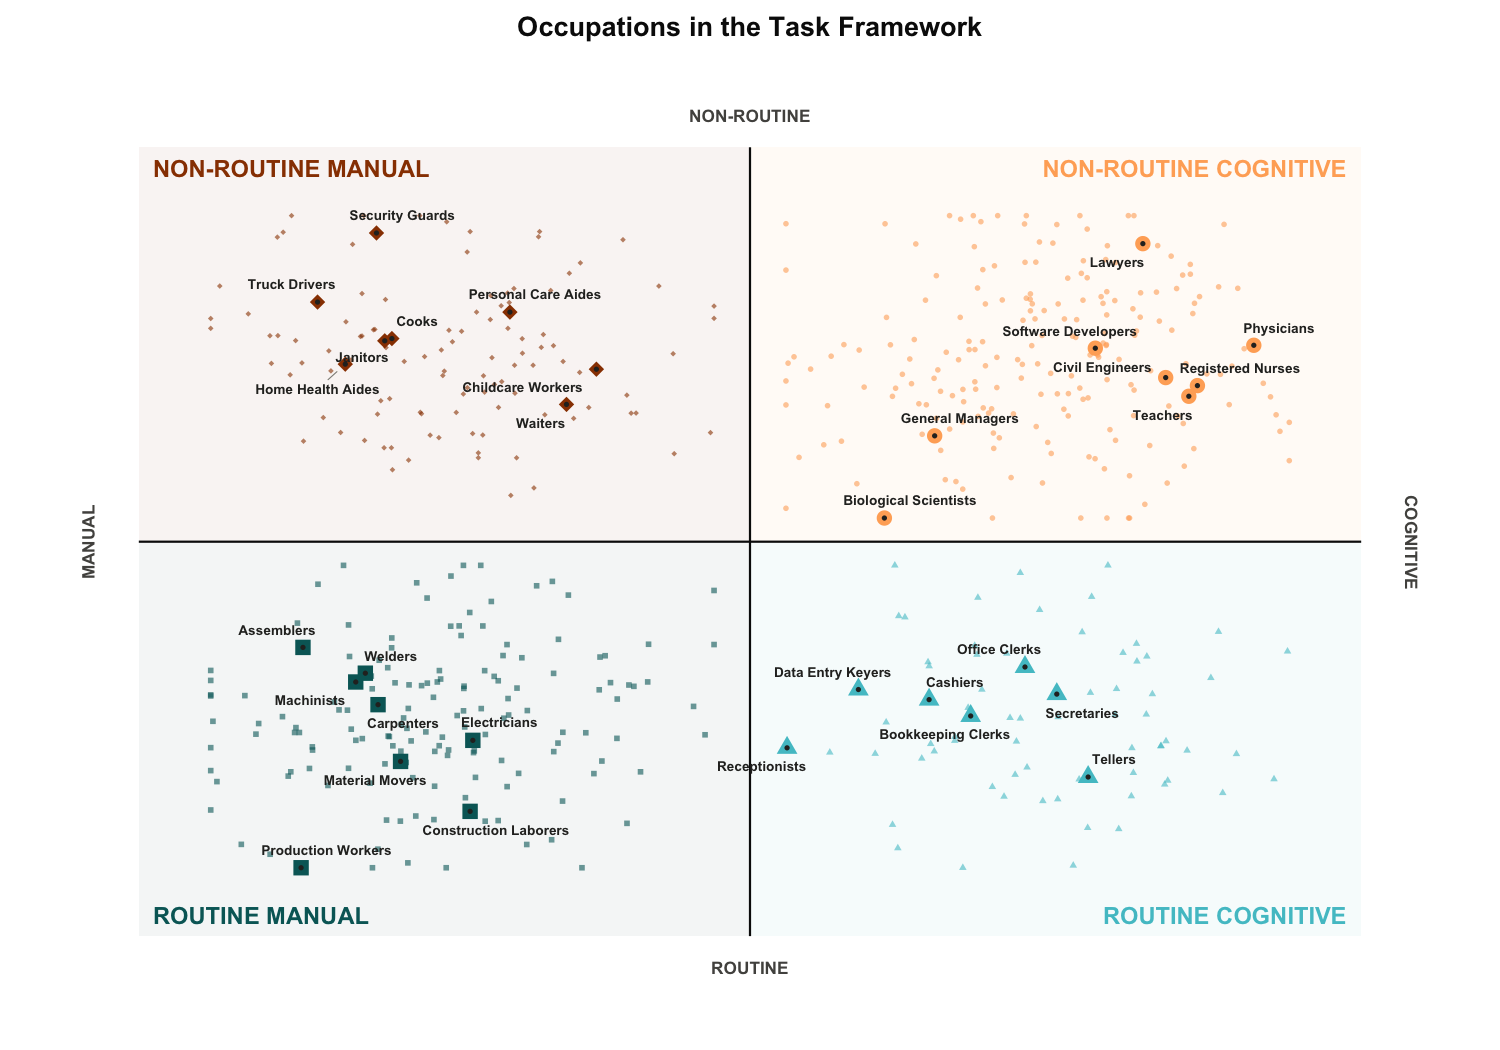

In [3]:
%%R -i occ_df -w 10 -h 7 -u in -r 150 -b transparent
# every occupation is one point; labeled points are the same points drawn larger.
suppressMessages(library(ggrepel))
lab <- occ_df[!is.na(occ_df$label), ]

ggplot(occ_df, aes(x=x, y=y, color=group, shape=group)) +
  annotate("rect", xmin=-1.70, xmax=0, ymin=0, ymax=1.50, fill="#993F00", alpha=0.05) +
  annotate("rect", xmin=0, xmax=1.70, ymin=0, ymax=1.50, fill="#FFAD65", alpha=0.05) +
  annotate("rect", xmin=-1.70, xmax=0, ymin=-1.50, ymax=0, fill="#006666", alpha=0.05) +
  annotate("rect", xmin=0, xmax=1.70, ymin=-1.50, ymax=0, fill="#51C3CC", alpha=0.05) +
  annotate("segment", x=0, xend=0, y=-1.50, yend=1.50, color="#0B0B0B", linewidth=0.5) +
  annotate("segment", x=-1.70, xend=1.70, y=0, yend=0, color="#0B0B0B", linewidth=0.5) +
  geom_point(size=1, alpha=0.6, stroke=0.4) +
  geom_point(data=lab, size=3, alpha=1, stroke=0.7) +
  geom_point(data=lab, aes(x=x, y=y), inherit.aes=FALSE, shape=16, size=0.9,
             color="#2B2B28") +
  geom_text_repel(data=lab, aes(x=x, y=y, label=label), inherit.aes=FALSE,
                  size=2.3, fontface="bold", color="#2B2B28", seed=510,
                  box.padding=0.36, point.padding=0.3, min.segment.length=0.2,
                  segment.color="#8F8D87", segment.size=0.25, max.overlaps=Inf) +
  scale_color_manual(values=c("Routine Cognitive"="#51C3CC", "Routine Manual"="#006666",
                              "Non-Routine Cognitive"="#FFAD65",
                              "Non-Routine Manual"="#993F00"), guide="none") +
  scale_shape_manual(values=c("Routine Cognitive"=17, "Routine Manual"=15,
                              "Non-Routine Cognitive"=16,
                              "Non-Routine Manual"=18), guide="none") +
  annotate("text", x=c(1.66,-1.66,1.66,-1.66), y=c(1.42,1.42,-1.42,-1.42), hjust=c(1,0,1,0),
           label=c("NON-ROUTINE COGNITIVE","NON-ROUTINE MANUAL",
                   "ROUTINE COGNITIVE","ROUTINE MANUAL"),
           fontface="bold", size=4,
           color=c("#FFAD65", "#993F00", "#51C3CC", "#006666")) +
  annotate("text", x=0, y=1.62, label="NON-ROUTINE", size=2.9, color="#52514E", fontface="bold") +
  annotate("text", x=0, y=-1.62, label="ROUTINE", size=2.9, color="#52514E", fontface="bold") +
  annotate("text", x=-1.84, y=0, label="MANUAL", angle=90, size=2.9, color="#52514E", fontface="bold") +
  annotate("text", x=1.84, y=0, label="COGNITIVE", angle=-90, size=2.9, color="#52514E", fontface="bold") +
  coord_cartesian(xlim=c(-1.76,1.76), ylim=c(-1.70,1.70), clip="off") +
  theme(axis.line=element_blank(), axis.text=element_blank(), axis.ticks=element_blank(),
        legend.position="none", plot.margin=margin(8,26,8,26)) +
  labs(title="Occupations in the Task Framework", x=NULL, y=NULL)

Once occupations are categorized based on their task content, it becomes easier to measure differences across local economies. The occupation taxonomy developed by Autor and Dorn ([2013](#ref-AutorDorn2013)) served as the foundation for assigning employment to the four task groups used in this study. Their own measure scored each occupation continuously on a single routine task intensity index built from ratings of its task content. Acemoglu and Autor ([2011](#ref-AcemogluAutor2011)) provided economic significance to these differences by treating tasks as units of production supplied by workers possessing varying skills. Technological advancements can shift labor demand across different types of tasks. These differences in county task groups provide a way to examine whether local work structures are associated with purchasing power.

Accurately measuring purchasing power requires accounting for differences in local price levels. Regional Price Parities (RPPs), published by the Bureau of Economic Analysis (BEA), offer a measure of these differences relative to the national average. A score of 100 in the RPP represents the national price level. Relative to this baseline, values above 100 indicate higher local price levels, while values below 100 indicate lower local price levels. The index combines prices for goods and services such as housing, food, transportation, medical care, education, and recreation. RPPs became an official BEA statistic in 2014, with estimates available back to 2008. However, BEA does not publish RPPs directly for individual counties. Instead, estimates are available for states, metropolitan areas, and nonmetropolitan portions of states, which can mask price differences among counties within the same region.

Multiple indicators collectively capture different aspects of local economic conditions. Poverty measures the proportion of residents living below an established income threshold. Unemployment measures the share of the labor force actively seeking work. Median household income represents the midpoint of the household income distribution, and RPPs compare local price levels with the national average. Each captures a different dimension of local conditions, and the four produce distinct geographic patterns across counties (Figure 2).

In [4]:
import geopandas as gpd
from sqlalchemy import create_engine

engine=create_engine(os.environ["AUTORACK_URL"], pool_pre_ping=True, pool_recycle=300)

In [5]:
context_year = 2023
context_df = pd.read_sql("""
    select cb.county_fips, cb.poverty_rate, cb.unemployment_rate,
           cb.median_household_income, ca.affordability_salary as purchasing_power
    from county_baseline cb
    join county_affordability ca
      on ca.county_fips = cb.county_fips and ca.year = cb.year
    where cb.year = %(yr)s
""", engine, params={"yr": context_year})
context_df["fips"] = context_df["county_fips"].astype(str).str.zfill(5)
# RPP recovered from the already computed purchasing power measure (@eq-afford, inverted):
# purchasing power = income / (RPP / 100), so RPP = income / purchasing power * 100.
context_df["rpp"] = context_df["median_household_income"] / context_df["purchasing_power"] * 100

gdf_context = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_county_500k.zip"
)
gdf_context = gdf_context.rename(columns={"GEOID": "fips"})
merged_context = gdf_context.merge(
    context_df[["fips", "poverty_rate", "unemployment_rate",
                "median_household_income", "rpp"]],
    on="fips", how="left"
)
merged_context = merged_context[
    ~merged_context["STATEFP"].isin(["02", "15", "60", "66", "69", "72", "78"])
].copy()

pov_ctx_vmin = float(context_df["poverty_rate"].quantile(0.02))
pov_ctx_vmax = float(context_df["poverty_rate"].quantile(0.98))
unemp_ctx_vmin = float(context_df["unemployment_rate"].quantile(0.02))
unemp_ctx_vmax = float(context_df["unemployment_rate"].quantile(0.98))
inc_ctx_vmin = float(context_df["median_household_income"].quantile(0.02))
inc_ctx_vmax = float(context_df["median_household_income"].quantile(0.98))
rpp_ctx_vmin = float(context_df["rpp"].quantile(0.02))
rpp_ctx_vmax = float(context_df["rpp"].quantile(0.98))

os.makedirs("output", exist_ok=True)
merged_context[["fips", "poverty_rate", "unemployment_rate",
                "median_household_income", "rpp", "geometry"]].to_file(
    "output/county_context.geojson", driver="GeoJSON"
)

In [6]:
%%R -i pov_ctx_vmin -i pov_ctx_vmax -i unemp_ctx_vmin -i unemp_ctx_vmax -i inc_ctx_vmin -i inc_ctx_vmax -i rpp_ctx_vmin -i rpp_ctx_vmax -w 10 -h 9 -u in -r 150 -b transparent
suppressMessages(library(sf))

context_sf <- st_read("output/county_context.geojson", quiet=TRUE)

context_panel_theme <- theme_void() +
  theme(legend.position="bottom", legend.key.width=unit(1.1, "cm"),
        plot.title=element_text(face="bold", size=11, hjust=0.5),
        plot.background=element_rect(fill=NA, color=NA))

bottom_guide <- guide_colorbar(direction="horizontal", title.position="bottom", title.hjust=0.5)

p_pov <- ggplot(context_sf) +
  geom_sf(aes(fill=poverty_rate), color="white", linewidth=0.05) +
  scale_fill_gradient(low="#FCFCFB", high=ORANGE, limits=c(pov_ctx_vmin, pov_ctx_vmax),
                      oob=scales::squish, na.value="#EEEEEE", name="Poverty Rate (%)",
                      guide=bottom_guide) +
  coord_sf(crs=st_crs(5070), datum=NA) +
  context_panel_theme +
  labs(title="Poverty Rate")

p_unemp <- ggplot(context_sf) +
  geom_sf(aes(fill=unemployment_rate), color="white", linewidth=0.05) +
  scale_fill_gradient(low="#FCFCFB", high=PINK, limits=c(unemp_ctx_vmin, unemp_ctx_vmax),
                      oob=scales::squish, na.value="#EEEEEE", name="Unemployment Rate (%)",
                      guide=bottom_guide) +
  coord_sf(crs=st_crs(5070), datum=NA) +
  context_panel_theme +
  labs(title="Unemployment Rate")

p_inc <- ggplot(context_sf) +
  geom_sf(aes(fill=median_household_income), color="white", linewidth=0.05) +
  scale_fill_gradient(low="#FCFCFB", high=GREEN, limits=c(inc_ctx_vmin, inc_ctx_vmax),
                      oob=scales::squish, na.value="#EEEEEE",
                      labels=function(v) sprintf("$%.0fk", v/1000),
                      name="Median Household Income",
                      guide=bottom_guide) +
  coord_sf(crs=st_crs(5070), datum=NA) +
  context_panel_theme +
  labs(title="Median Household Income")

p_rpp <- ggplot(context_sf) +
  geom_sf(aes(fill=rpp), color="white", linewidth=0.05) +
  scale_fill_gradient(low="#FCFCFB", high=BLUE, limits=c(rpp_ctx_vmin, rpp_ctx_vmax),
                      oob=scales::squish, na.value="#EEEEEE",
                      name="Regional Price Parity",
                      guide=bottom_guide) +
  coord_sf(crs=st_crs(5070), datum=NA) +
  context_panel_theme +
  labs(title="Regional Price Parity")

(p_pov | p_unemp) / (p_inc | p_rpp) +
  plot_annotation(title="Four Views of County Economic Conditions",
                  tag_levels="A", tag_suffix=")",
                  theme=theme(plot.title=element_text(face="bold", size=13, hjust=0.5),
                              plot.tag=element_text(face="bold", size=11, color="#0B0B0B")))

Geographic scale presented an additional measurement challenge because broader geographic units could obscure economic differences between nearby counties. Local prices and household resources varied within the same labor market, while earlier studies often combined several counties into a single regional measure. This aggregation could mask meaningful local variation that remained visible at the county level. Curran et al. ([2006](#ref-Curran2006)) showed that accounting for geographic cost of living differences alters how places compare on economic wellbeing, which makes the choice of geographic unit consequential for any measure of household resources. By measuring purchasing power at the county level, we preserved more of this variation by incorporating both household income and local price levels. Additionally, we evaluated whether the association between purchasing power and county task groups was better represented in dollar terms or proportional terms. This approach addressed a gap in prior research, which examined task groups in relation to employment and wages without evaluating their association with purchasing power at the county level.

# Data

## Data sources and study period

This study integrated five federal datasets published by three agencies, summarized in <a href="#tbl-sources" class="quarto-xref">Table 1</a>, along with the number of records and variables provided by each source. Most sources reported data at the county level, and they were joined using the county Federal Information Processing Standards (FIPS) code and the year. RPPs were published at the metropolitan area level and required an additional matching step. Counties were first linked to their metropolitan areas using the Census Bureau Core Based Statistical Area (CBSA) delineation file and then matched to the corresponding BEA price measure ([U.S. Bureau of Economic Analysis 2024](#ref-bea_rpp); [U.S. Census Bureau 2023a](#ref-census_cbsa)).

In [7]:
import pandas as pd
from great_tables import GT

sources_df=pd.DataFrame({
    "Data Source": ["Small Area Income and Poverty Estimates",
                    "Bureau of Economic Analysis Regional Price Parities",
                    "Core Based Statistical Area delineation",
                    "American Community Survey 1 year estimates",
                    "Bureau of Labor Statistics Local Area Unemployment Statistics"],
    "Abbreviation": ["Census SAIPE","BEA RPP","Census CBSA",
                     "Census ACS","BLS LAUS"],
    "Records": [50283, 884, 387, 15690, 88004],
    "Measures": ["median household income, poverty rate",
                 "county price level relative to the national average",
                 "county to metropolitan area crosswalk",
                 "population, occupational employment by category",
                 "unemployment rate"],
    "Destination Table": ["`county_baseline`","`cbsa_rpp`","`cbsa`",
                          "`county_baseline`, `county_task_exposure`","`county_baseline`"],
})

style_table(GT(sources_df)
  .fmt_integer(columns="Records", use_seps=True)
  .fmt_markdown(columns=["Destination Table"])
  .cols_align(align="center", columns=["Abbreviation","Records","Measures","Destination Table"])
  .cols_align(align="left", columns="Data Source")
  .tab_source_note("Scale: 3,143 counties per year, 15 years (2008 to 2023, excluding 2020), 47,140 county year universe, 11,983 rows in the analytical panel.")
  .tab_source_note("Records count rows retrieved from each source rather than analytical observations. The ACS publishes 1 year estimates only for areas above 65,000 residents, which reduces the universe to the 848 county panel.")
  .tab_source_note("All sources retrieved June 2026 through agency APIs or bulk file download."))

The study spans 2008 through 2023 but excludes 2020, because the American Community Survey (ACS) did not publish data due to disruptions of data collection during the COVID-19 pandemic ([U.S. Census Bureau 2024a](#ref-census_acs)). Those estimates served as the occupational employment counts used to construct the task groups. Over the subsequent fifteen years, the Small Area Income and Poverty Estimates (SAIPE) program provided an initial sample of 47,140 county-year observations ([U.S. Census Bureau 2024b](#ref-census_saipe)).[1]

## Analytical sample

The initial sample restriction stemmed from the coverage of the ACS occupational estimates. The Census Bureau published ACS 1 year occupational estimates exclusively for counties with populations of at least 65,000. Consequently, counties below this threshold lacked the employment counts necessary to construct the four task groups. Consequently, applying this restriction reduced the sample to 12,087 county-year observations across 848 counties. A subsequent restriction mandated the inclusion of complete model covariates, resulting in the removal of 104 observations with missing unemployment rates.[2] However, population, median household income, and poverty rate data were complete throughout the sample.

The final analytical sample comprised 11,983 county-year observations from 840 counties. All models presented in <a href="#sec-analysis" class="quarto-xref">Section 4</a> and <a href="#sec-results" class="quarto-xref">Section 5</a> used these same observations. To ensure unbiased machine learning evaluation, counties were exclusively included in either the training or test set, preventing observations from the same county from appearing in both partitions. <a href="#sec-analysis" class="quarto-xref">Section 4</a> provides a detailed description of the evaluation procedure.

The population threshold imposed a limitation on the scope of the results. While the 840 retained counties accounted for approximately 84% of the United States population, they represented a minority of all counties. Consequently, rural counties were underrepresented because the retained counties were generally more populous and metropolitan. The results were applicable to counties above the ACS publication threshold rather than the entire nation, a limitation discussed in <a href="#sec-conclusions" class="quarto-xref">Section 6</a>.

## Construction of task group measures

Following the framework introduced in <a href="#sec-background" class="quarto-xref">Section 2</a>, we classified broad occupational categories in the ACS 1 year estimates into four task groups, applying the task type distinctions of Autor, Levy, and Murnane ([2003](#ref-Autor2003)) and the occupation taxonomy of Autor and Dorn ([2013](#ref-AutorDorn2013)). For instance, clerical and sales occupations were categorized as routine cognitive tasks, while service occupations were classified as non-routine manual tasks. Subsequently, we summed employment within each task group for every county and year.

<span id="eq-totals">$$
T_{g,c,t} = \sum_{o \in g} E_{o,c,t}
 \qquad(1)$$</span>

Here, $T_{g,c,t}$ represented total employment in task group $g$ for county $c$ in year $t$. The sum ran over the occupational categories $o$ assigned to that group, and $E_{o,c,t}$ represented employment in a single category. Since the calculation used employment counts without task intensity weights, each total represented the number of jobs in that group. Scoring each occupation continuously, as Autor and Dorn ([2013](#ref-AutorDorn2013)) did, would have required employment counts for detailed occupations, which the Census Bureau did not publish for counties. Every job within a broad category therefore carried equal weight, and variation in task content inside those categories went unmeasured. Dividing each group’s total by the total across all four groups, as shown in <a href="#eq-group" class="quarto-xref">Equation 2</a>, converted these totals into proportions between zero and one that summed to one.

<span id="eq-group">$$
G_{g,c,t} = \frac{T_{g,c,t}}{\sum_{g'} T_{g',c,t}}
 \qquad(2)$$</span>

Here, $G_{g,c,t}$ represented the proportion of employment in task group $g$, and $g'$ indexed the four groups summed in the denominator.

These proportions assigned counties of varying sizes to a common scale. Since the four proportions added up to one, non-routine cognitive work was excluded from the regression as the reference group, and the remaining coefficients were interpreted in relation to it. We maintained the four task groups as separate entities because a single routine intensity index would obscure differences between types of work. For instance, a shift away from clerical work and a shift away from assembly work could otherwise appear identical. <a href="#sec-analysis" class="quarto-xref">Section 4</a> provides an explanation of how the task groups were incorporated into the models.

Additionally, the Census Bureau revised its occupational classification between 2009 and 2010. While some category boundaries changed, their assignment to the four task groups remained consistent. <a href="#sec-analysis" class="quarto-xref">Section 4</a> reports the corresponding robustness checks.

## Construction of the purchasing power measure

Median household income was used because it represented the income of a typical household better than the mean, which was more sensitive to high incomes in a positively skewed distribution ([Chiripanhura 2011](#ref-Chiripanhura2011)). It described what households received rather than what they could buy.

The outcome was measured as purchasing power to account for variations in what household income could purchase across different counties. We calculated it by adjusting the county median household income from SAIPE ([U.S. Census Bureau 2024b](#ref-census_saipe)) using RPPs. These provided local price levels relative to the national average ([U.S. Bureau of Economic Analysis 2024](#ref-bea_rpp)). Since the index was expressed as a percentage, dividing it by 100 converted it into a price multiplier. Subsequently, we divided the median household income by this multiplier to determine purchasing power, as illustrated in <a href="#eq-afford" class="quarto-xref">Equation 3</a>.

<span id="eq-afford">$$
A_{c,t} = \frac{\text{Median household income}_{c,t}}{\text{RPP}_{c,t} / 100}
 \qquad(3)$$</span>

Here, $A_{c,t}$ represented purchasing power for county $c$ in year $t$, and $\text{RPP}_{c,t}$ represented its Regional Price Parity.

For instance, consider a county with a median household income of \$60,000 and an RPP of 120. This means that its income could buy approximately what \$50,000 would buy at the national average prices. This adjustment made household income more comparable across counties by accounting for variations in local prices. However, since BEA did not publish separate RPPs for counties outside metropolitan areas, those counties were assigned the corresponding state-level parity. Within the analytical panel, 45.5% of county-year observations used a metropolitan parity, while 54.5% used the state measure. Consequently, more than half of the panel relied on a state average that did not account for price differences within the state.

### Inflation and year indicators

RPPs were adjusted for variations across regions but not for changes in the national price level over time. Consequently, purchasing power was reported in nominal U.S. dollars. A national deflator would apply the same annual adjustment to every county. In the log specification, this adjustment would be incorporated into the year indicators, leaving the task group and control coefficients unchanged. Additionally, the year indicators captured other changes that occurred simultaneously across counties within a year, making it impossible to interpret their coefficients solely as inflation. <a href="#sec-analysis" class="quarto-xref">Section 4</a> provides an explanation of how the year indicators were incorporated into the model, while <a href="#sec-conclusions" class="quarto-xref">Section 6</a> addresses this limitation.

## Control variables

The analysis incorporated poverty rate, unemployment rate, and population as county-level covariates. Poverty and unemployment captured the economic distress mentioned in <a href="#sec-background" class="quarto-xref">Section 2</a>, enabling the analysis to determine if task groups provided information beyond these measures. Median household income directly entered the purchasing power outcome, so it was not included as a control variable. Population accounted for variations in county size, which could otherwise affect the estimates.

Figure 3 displayed the distributions of poverty rate, unemployment rate, population, and median household income across the same task group panel used in Figure 9. All four variables were right skewed, but population was the most extreme and therefore entered the analysis in logarithmic form. Poverty rate, unemployment rate, and median household income remained in their original units. This supported the log respecification in <a href="#sec-analysis" class="quarto-xref">Section 4</a> as a response to the outcome’s own distribution rather than a transformation applied across all variables.

[1] The District of Columbia and Kalawao County, Hawaii, are excluded because they are absent from the county reference file. Connecticut counties leave the panel after 2021 because the state replaced its legacy counties with planning regions beginning in 2022.

[2] All 104 missing observations came from Connecticut’s eight legacy counties, where unemployment rates were unavailable at the required geography ([U.S. Bureau of Labor Statistics 2024](#ref-bls_laus)). Because the missingness reflected geography rather than unemployment itself, it was treated as missing at random.

In [8]:
import os
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()
engine=create_engine(os.environ["AUTORACK_URL"], pool_pre_ping=True, pool_recycle=300)
baseline_df=pd.read_sql("""
select ca.county_fips, ca.year, cb.poverty_rate, cb.unemployment_rate,
    cb.population, cb.median_household_income
from county_affordability ca
join county_task_exposure cte on ca.county_fips=cte.county_fips and ca.year=cte.year
join county_baseline cb on ca.county_fips=cb.county_fips and ca.year=cb.year
""", engine)

baseline_names={"poverty_rate":"Poverty Rate (%)", "unemployment_rate":"Unemployment Rate (%)",
                "population":"Population", "median_household_income":"Median Household Income ($)"}
baseline_long=baseline_df.melt(value_vars=list(baseline_names.keys()),
                               var_name="variable", value_name="value")
baseline_long["variable"]=baseline_long["variable"].map(baseline_names)

In [9]:
%%R -i baseline_long -w 9 -h 7 -u in -r 150 -b transparent
baseline_order <- c("Poverty Rate (%)","Unemployment Rate (%)","Population","Median Household Income ($)")
baseline_long$variable <- factor(baseline_long$variable, levels=baseline_order)

p_pov <- ggplot(subset(baseline_long, variable=="Poverty Rate (%)"), aes(x=variable, y=value)) +
  geom_violin(fill=ORANGE, color=ORANGE, alpha=0.35, linewidth=0.6, trim=TRUE) +
  geom_boxplot(width=0.12, fill="white", color="grey30", alpha=0.7,
               outlier.size=0.8, outlier.alpha=0.5) +
  scale_y_continuous(labels=function(v) sprintf("%g%%", v), breaks=scales::pretty_breaks(n=4)) +
  labs(title="Poverty Rate", x=NULL, y="Percent") +
  theme(axis.text.x=element_blank(), plot.title=element_text(size=11),
        panel.grid=element_blank())

p_unemp <- ggplot(subset(baseline_long, variable=="Unemployment Rate (%)"), aes(x=variable, y=value)) +
  geom_violin(fill=PINK, color=PINK, alpha=0.35, linewidth=0.6, trim=TRUE) +
  geom_boxplot(width=0.12, fill="white", color="grey30", alpha=0.7,
               outlier.size=0.8, outlier.alpha=0.5) +
  scale_y_continuous(labels=function(v) sprintf("%g%%", v), breaks=scales::pretty_breaks(n=4)) +
  labs(title="Unemployment Rate", x=NULL, y="Percent") +
  theme(axis.text.x=element_blank(), plot.title=element_text(size=11),
        panel.grid=element_blank())

p_pop <- ggplot(subset(baseline_long, variable=="Population"), aes(x=variable, y=value)) +
  geom_violin(fill="#2A78D6", color="#2A78D6", alpha=0.35, linewidth=0.6, trim=TRUE) +
  geom_boxplot(width=0.12, fill="white", color="grey30", alpha=0.7,
               outlier.size=0.8, outlier.alpha=0.5) +
  scale_y_log10(labels=label_comma(), breaks=scales::log_breaks(n=4)) +
  labs(title="Population", x=NULL, y="Residents (Log Scale)") +
  theme(axis.text.x=element_blank(), plot.title=element_text(size=11),
        panel.grid=element_blank())

p_inc <- ggplot(subset(baseline_long, variable=="Median Household Income ($)"), aes(x=variable, y=value)) +
  geom_violin(fill=GREEN, color=GREEN, alpha=0.35, linewidth=0.6, trim=TRUE) +
  geom_boxplot(width=0.12, fill="white", color="grey30", alpha=0.7,
               outlier.size=0.8, outlier.alpha=0.5) +
  scale_y_continuous(labels=dollar_axis, breaks=scales::pretty_breaks(n=4)) +
  labs(title="Median Household Income", x=NULL, y="Dollars") +
  theme(axis.text.x=element_blank(), plot.title=element_text(size=11),
        panel.grid=element_blank())

(p_pov | p_unemp) / (p_pop | p_inc) +
  plot_annotation(title="Distribution of the Control Variables",
                  tag_levels="A", tag_suffix=")",
                  theme=theme(plot.title=element_text(face="bold", size=13, hjust=0.5),
                              plot.tag=element_text(face="bold", size=11, color="#0B0B0B")))

R callback write-console: In addition:   
R callback write-console: Warning messages:
  
R callback write-console: 1: Removed 104 rows containing non-finite outside the scale range
(`stat_ydensity()`). 
  
R callback write-console: 2: Removed 104 rows containing non-finite outside the scale range
(`stat_boxplot()`). 
  

## Data architecture and organization

The data architecture separated raw source records from the tables used for analysis. Raw retrievals and intermediate results were stored in a PostgreSQL data lake containing 41 tables, which remained unnormalized to maintain traceability. Processed data were then written to an analytical warehouse containing eleven tables. In this warehouse, county identifiers were standardized, records were restricted to the study period, jurisdictions outside the panel were removed, and foreign key constraints were enforced.

Figure 4 provided a diagram that summarized the path from federal sources through the data lake and warehouse to the analysis-ready tables.

In [10]:
import graphviz

def entity(name, rows):
    body = f'<TR><TD COLSPAN="3" BGCOLOR="#2A78D6"><FONT COLOR="white" POINT-SIZE="15"><B>{name}</B></FONT></TD></TR>'
    for typ, col, marker in rows:
        m = f'<FONT COLOR="#8F8D87" POINT-SIZE="10">{marker}</FONT>' if marker else ""
        body += f'<TR><TD ALIGN="LEFT"><FONT POINT-SIZE="10">{typ}</FONT></TD><TD ALIGN="LEFT"><FONT POINT-SIZE="13">{col}</FONT></TD><TD ALIGN="LEFT">{m}</TD></TR>'
    return f'<<TABLE BORDER="1" CELLBORDER="0" CELLSPACING="0" CELLPADDING="3" BGCOLOR="white">{body}</TABLE>>'

CENSUS_FILL = "#DCEEF7"; CENSUS_BORDER = "#2A78D6"
BEA_FILL = "#DCF3EA"; BEA_BORDER = "#1BAF7A"
BLS_FILL = "#F7DCE6"; BLS_BORDER = "#C2255C"
OUT_FILL = "#FBE3D3"; OUT_BORDER = "#EB6834"
LAKE_FILL = "#EDEDEA"; LAKE_BORDER = "#8F8D87"

dot = f'''
digraph architecture {{
  rankdir=TB
  compound=true
  bgcolor="transparent"
  fontname="Helvetica"
  label=<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="0"><TR><TD><FONT FACE="Helvetica-Bold" POINT-SIZE="24">Data Pipeline Architecture</FONT></TD></TR></TABLE>>
  labelloc="t"
  nodesep=0.4
  ranksep=0.9
  node [fontname="Helvetica", shape=box, style="rounded", color="#C3C2B7"]
  edge [fontname="Helvetica", color="black", arrowsize=0.6]

  subgraph cluster_source {{
    label="Data Sources"
    labeljust="c"
    fontsize=16
    fontname="Helvetica-Bold"
    style="rounded"
    color="#C3C2B7"
    bgcolor="#F2F8FC"
    margin=18
    node [style="filled,rounded", margin="0.1,0.05", fontsize=14]
    src_census [label="Census Bureau\\nSAIPE · ACS 1yr · CBSA delineation", fillcolor="{CENSUS_FILL}", color="{CENSUS_BORDER}"]
    src_bea [label="BEA\\nRegional Price Parities", fillcolor="{BEA_FILL}", color="{BEA_BORDER}"]
    src_bls [label="BLS\\nLAUS", fillcolor="{BLS_FILL}", color="{BLS_BORDER}"]
  }}

  subgraph cluster_lake {{
    label="Data Lake"
    labeljust="c"
    fontsize=16
    fontname="Helvetica-Bold"
    style="rounded"
    color="#C3C2B7"
    bgcolor="#F4F4F1"
    margin=18
    node [style="filled,rounded", fillcolor="{LAKE_FILL}", color="{LAKE_BORDER}", margin="0.1,0.05", fontsize=14]
    lake [label="Raw retrievals and intermediate results\\n41 tables, unnormalized"]
  }}

  subgraph cluster_warehouse {{
    label="Data Warehouse (3NF)"
    labeljust="c"
    fontsize=16
    fontname="Helvetica-Bold"
    style="rounded"
    color="#C3C2B7"
    bgcolor="#F2FAF6"
    margin=18
    node [shape=plain]

    state [label={entity("state", [("varchar","state_code","PK"),("varchar","state_name","")])}]
    county [label={entity("county", [("bigint","county_fips","PK"),("varchar","county_name",""),("varchar","state_code","FK")])}]
    county_baseline [label={entity("county_baseline", [("bigint","county_fips","PK,FK"),("int","year","PK"),("numeric","population",""),("numeric","median_household_income",""),("numeric","poverty_rate",""),("numeric","unemployment_rate","")])}]
    county_task_exposure [label={entity("county_task_exposure", [("bigint","county_fips","PK,FK"),("int","year","PK"),("numeric","routine_cognitive_share","generated"),("numeric","routine_manual_share","generated"),("numeric","non_routine_cognitive_share","generated"),("numeric","non_routine_manual_share","generated")])}]
    county_affordability [label={entity("county_affordability", [("bigint","county_fips","PK,FK"),("int","year","PK"),("numeric","affordability_salary","")])}]
    county_cbsa_code [label={entity("county_cbsa_code", [("bigint","county_fips","PK,FK"),("varchar","cbsa_code","PK,FK")])}]
    cbsa [label={entity("cbsa", [("varchar","cbsa_code","PK"),("varchar","cbsa_name","")])}]
    cbsa_rpp [label={entity("cbsa_rpp", [("varchar","cbsa_code","PK,FK"),("int","year","PK"),("numeric","rpp_value","")])}]

    {{rank=same; county_baseline; county_task_exposure; county_affordability}}

    state -> county
    county -> county_baseline
    county -> county_task_exposure
    county -> county_affordability
    county -> county_cbsa_code
    county_cbsa_code -> cbsa
    cbsa -> cbsa_rpp
  }}

  subgraph cluster_output {{
    label="Modeling Tables"
    labeljust="c"
    fontsize=16
    fontname="Helvetica-Bold"
    style="rounded"
    color="#C3C2B7"
    bgcolor="#FDF5EF"
    margin=18
    node [style="filled,rounded", fillcolor="{OUT_FILL}", color="{OUT_BORDER}", margin="0.1,0.05", fontsize=14]
    analysis_table [label="Analysis ready county year table\\n(joined on county_fips and year)"]
    models [label="Statistical and ML models"]
    figures [label="Figures and tables"]
    {{rank=same; models; figures}}
    analysis_table -> models
    analysis_table -> figures
  }}

  src_census -> lake [ltail="cluster_source", lhead="cluster_lake", minlen=2]
  src_bea -> lake [ltail="cluster_source", lhead="cluster_lake", minlen=2]
  src_bls -> lake [ltail="cluster_source", lhead="cluster_lake", minlen=2]
  lake -> state [ltail="cluster_lake", lhead="cluster_warehouse", minlen=2]
  county_affordability -> analysis_table [ltail="cluster_warehouse", lhead="cluster_output", minlen=2]
  county_baseline -> analysis_table [style=invis]
  county_task_exposure -> analysis_table [style=invis]
}}
'''
graphviz.Source(dot)

The warehouse is organized around a county table, which is keyed by FIPS code and linked to the state as a reference table. Three analytical tables join to each county by FIPS code and year. The county_baseline table contains population, median household income, poverty rate, and unemployment rate. The county_task_exposure table contains the four task group totals defined in <a href="#eq-totals" class="quarto-xref">Equation 1</a>, while the county_affordability table contains the purchasing power outcome.

# Analysis

In [11]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()

engine=create_engine(os.environ["AUTORACK_URL"], pool_pre_ping=True, pool_recycle=300)
df=pd.read_sql("""
select ca.county_fips, ca.year, ca.affordability_salary,
    cte.routine_cognitive_share, cte.routine_manual_share,
    cte.non_routine_cognitive_share, cte.non_routine_manual_share,
    cb.poverty_rate, cb.unemployment_rate, cb.population
from county_affordability ca
join county_task_exposure cte on ca.county_fips=cte.county_fips and ca.year=cte.year
join county_baseline cb on ca.county_fips=cb.county_fips and ca.year=cb.year
""", engine)
df["log_population"]=np.log(df["population"])

In [12]:
# level model: OLS with year indicators, standard errors clustered by county
reg_cols=["routine_cognitive_share","routine_manual_share","non_routine_manual_share",
          "poverty_rate","unemployment_rate","log_population"]

reg=df.dropna(subset=reg_cols+["affordability_salary"]).copy()

X_panel=pd.concat([reg[reg_cols],
                   pd.get_dummies(reg["year"], prefix="year", drop_first=True).astype(float)], axis=1)
X_panel=sm.add_constant(X_panel)

model=sm.OLS(reg["affordability_salary"], X_panel).fit(
    cov_type="cluster", cov_kwds={"groups": reg["county_fips"]})

reg["fitted"]=model.fittedvalues
reg["resid"]=model.resid

# log respecification, same design matrix
reg["actual_log"]=np.log(reg["affordability_salary"])
model_log=sm.OLS(reg["actual_log"], X_panel).fit(
    cov_type="cluster", cov_kwds={"groups": reg["county_fips"]})
reg["resid_log"]=model_log.resid
reg["fitted_log"]=model_log.fittedvalues

## The unadjusted relationship

The analysis commenced by examining the unadjusted relationship between task groups and purchasing power. Figure 5 plotted purchasing power against each of the four task groups across the panel. The two manual groups exhibited the most pronounced negative relationships, while non-routine cognitive tasks showed a positive correlation, and routine cognitive tasks remained relatively flat. None of these relationships were strong enough to stand alone, prompting the subsequent adjustment analysis. Interestingly, the same ordering persisted after the adjustment.

In [13]:
uni_labels={
    "routine_cognitive_share":"Routine Cognitive",
    "routine_manual_share":"Routine Manual",
    "non_routine_cognitive_share":"Non-Routine Cognitive",
    "non_routine_manual_share":"Non-Routine Manual",
}
uni_pts=df.melt(id_vars="affordability_salary", value_vars=list(uni_labels.keys()),
                var_name="group", value_name="share").dropna()
uni_pts["group"]=uni_pts["group"].map(uni_labels)
uni_pts["share"]=uni_pts["share"]*100  # express as percent of county employment

uni_pts["bin"]=uni_pts.groupby("group")["share"].transform(
    lambda s: pd.qcut(s, 20, labels=False, duplicates="drop"))
uni_bins=(uni_pts.groupby(["group","bin"])[["share","affordability_salary"]]
          .mean().reset_index())
uni_order=list(uni_labels.values())

In [14]:
%%R -i uni_pts -i uni_bins -i uni_order -w 10 -h 6 -u in -r 150 -b transparent
uni_pts$group <- factor(uni_pts$group, levels=unlist(uni_order))
uni_bins$group <- factor(uni_bins$group, levels=unlist(uni_order))

# the strip carries the group name alone, centered; the letter tag sits just above
# the top of each panel's y axis, clear of both the strip and the axis labels
tag_df <- data.frame(group=factor(unlist(uni_order), levels=unlist(uni_order)),
                     tag=paste0(LETTERS[seq_along(unlist(uni_order))], ")"))

ggplot(uni_pts, aes(x=share, y=affordability_salary)) +
  geom_point(alpha=0.08, size=0.25, color="grey40") +
  geom_line(data=uni_bins, aes(color=group), linewidth=0.8, show.legend=FALSE) +
  geom_point(data=uni_bins, aes(color=group), size=1.8, show.legend=FALSE) +
  geom_text(data=tag_df, aes(x=-Inf, y=Inf, label=tag), inherit.aes=FALSE,
            hjust=1.2, vjust=-0.45, fontface="bold", size=4.2, color="#0B0B0B") +
  # axes="all_y" repeats the y axis on the right column too; the scale stays shared
  facet_wrap(~group, ncol=2, scales="free_x", axes="all_y") +
  coord_cartesian(clip="off") +
  scale_color_manual(values=TASK_COLORS) +
  scale_x_continuous(breaks=scales::pretty_breaks(n=8)) +
  scale_y_continuous(labels=dollar_axis) +
  labs(title="Purchasing Power Against Each Task Group",
       x="Percent of County Employment", y="Purchasing Power") +
  theme(plot.title=element_text(hjust=0.5),
        strip.text=element_text(size=12, hjust=0.5),
        axis.ticks.x=element_line(color="#C3C2B7", linewidth=0.3),
        panel.grid=element_blank(),
        panel.spacing=unit(1.4, "lines"))

## Variance decomposition

Purchasing power and task groups exhibit variations both across counties and within a county over time, each carrying distinct implications. Figure 6 effectively divides each group’s variation into these two components. The manual groups show almost complete variation between counties, which contributes to the durability of the purchasing power differences they represent. In contrast, routine cognitive is the only group with substantial within-county movement.

In [15]:
df10=df[df["year"]>=2010].copy()
input_cols=["routine_cognitive_share","routine_manual_share","non_routine_manual_share"]

within_vals=[]
for col in input_cols:
    yd=df10[col]-df10.groupby("year")[col].transform("mean")
    within=(yd-yd.groupby(df10["county_fips"]).transform("mean")).var()
    within_vals.append(within/yd.var()*100)

bw_labels=["Routine Cognitive","Routine Manual","Non-Routine Manual"]
bw_df=pd.concat([
    pd.DataFrame({"group":bw_labels, "value":[100-v for v in within_vals],
                  "component":"Between Counties"}),
    pd.DataFrame({"group":bw_labels, "value":within_vals,
                  "component":"Within Counties Over Time"}),
], ignore_index=True)
bw_text_df=pd.concat([
    pd.DataFrame({"group":bw_labels, "x":[(100-v)/2 for v in within_vals],
                  "label":[f"{100-v:.0f}%" for v in within_vals], "component":"Between Counties"}),
    pd.DataFrame({"group":bw_labels, "x":[100-v/2 for v in within_vals],
                  "label":[f"{v:.0f}%" for v in within_vals], "component":"Within Counties Over Time"}),
], ignore_index=True)

In [16]:
%%R -i bw_df -i bw_text_df -w 9 -h 3.5 -u in -r 150 -b transparent
bw_df$group <- factor(bw_df$group,
    levels=rev(c("Routine Cognitive","Routine Manual","Non-Routine Manual")))
bw_df$component <- factor(bw_df$component,
    levels=c("Within Counties Over Time","Between Counties"))
bw_text_df$group <- factor(bw_text_df$group, levels=levels(bw_df$group))

bw_text_df$text_color <- ifelse(bw_text_df$component == "Between Counties",
                                "#FFFFFF", "#0B0B0B")

ggplot(bw_df, aes(x=value, y=group, fill=component)) +
  geom_col(width=0.7) +
  geom_text(data=bw_text_df, aes(x=x, y=group, label=label, color=text_color),
            inherit.aes=FALSE, size=3.4) +
  scale_color_identity() +
  scale_fill_manual(values=c("Between Counties"=BLUE,
                             "Within Counties Over Time"=ORANGE), name=NULL) +
  guides(fill=guide_legend(reverse=TRUE)) +
  # in-bar labels carry the values, so the axis is dropped rather than encoding
  # the same numbers twice. Same rule applied to fig-ablation and fig-importance.
  scale_x_continuous(expand=c(0, 0)) +
  scale_y_discrete(expand=expansion(add=c(0.3, 0.3))) +
  labs(title="Between County vs. Within County Variation by Task Group",
       x=NULL, y=NULL) +
  # expand=c(0,0) runs the bars flush to 100 with no trailing gap; the right plot
  # margin holds the 100 tick label, which would otherwise clip at the panel edge
  theme(legend.position="bottom", plot.margin=margin(10, 16, 8, 10),
        axis.text.x=element_blank(), axis.ticks.x=element_blank(),
        panel.grid=element_blank())

The Census occupation coding change between 2009 and 2010, as described in <a href="#sec-data" class="quarto-xref">Section 3</a>, inflates the apparent variation in routine cognitive occupations within counties. This inflation arises from the coding of the source data rather than any inherent property of the counties. The figure is computed on a panel restricted to 2010 onward, with each year’s cross-county mean removed.

## Model specification

Non-routine cognitive tasks served as the reference group because the four task group proportions summed to one. Each remaining coefficient therefore represented the change in purchasing power associated with a shift from non-routine cognitive work to that group, while holding the other variables constant. This made the coefficients interpretable as comparisons between task groups rather than as independent changes in employment. Task group values ranged from zero to one, and coefficients were divided by 100 when reported as percentage point changes.

Year indicators captured the shared conditions across all counties within a specific year, encompassing events like the 2008 recession, its subsequent recovery, and the national price movements described in <a href="#sec-data" class="quarto-xref">Section 3</a>. By including these indicators, we prevented attributing national changes to variations in county task groups. Since the year coefficients absorbed all common changes within a year, they were treated as nuisance parameters rather than evidence of increasing purchasing power. Figure 7 illustrated their pattern across the panel.

In [17]:
# year coefficients from both specifications, converted to their reporting units:
# dollars for the level model, percent for the log model via (exp(b)-1)*100
def _year_frame(m, pct=False):
    co=m.params.filter(like="year_"); ci=m.conf_int().filter(like="year_", axis=0)
    d=pd.DataFrame({"year":[int(s.split("_")[1]) for s in co.index],
                    "estimate":co.values, "lo":ci[0].values, "hi":ci[1].values})
    if pct:
        for c in ["estimate","lo","hi"]: d[c]=(np.exp(d[c])-1)*100
    return d

year_eff_level=_year_frame(model)
year_eff_log=_year_frame(model_log, pct=True)

In [18]:
%%R -i year_eff_level -i year_eff_log -w 8 -h 6.5 -u in -r 150 -b transparent
year_panel <- function(d, ylab, lab_fn) {
  y_lo <- min(d$lo, na.rm=TRUE); y_hi <- max(d$hi, na.rm=TRUE)
  covid_y <- y_lo + 0.88 * (y_hi - y_lo)
  ggplot(d, aes(x=year, y=estimate)) +
    # the band spans the gap between the 2019 and 2021 points, marking 2020 as a
    # year with no estimate rather than a year the series passed through. Drawn
    # first so the ribbon and line sit on top of it.
    annotate("rect", xmin=2019, xmax=2021, ymin=-Inf, ymax=Inf,
             fill="#8F8D87", alpha=0.13) +
    annotate("text", x=2020, y=covid_y, label="COVID-19\nno ACS data",
             hjust=0.5, size=2.9, color="#52514E", lineheight=1.05,
             fontface="bold") +
    geom_hline(yintercept=0, linetype="dashed", color=GREY, linewidth=0.4) +
    geom_ribbon(aes(ymin=lo, ymax=hi), fill="#2A78D6", alpha=0.18) +
    geom_line(color="#2A78D6", linewidth=0.7) +
    geom_point(color="#2A78D6", size=1.8) +
    scale_y_continuous(labels=lab_fn) +
    # a tick on every year in the window, 2020 included, so the gap is labeled
    # rather than silently skipped over
    scale_x_continuous(breaks=sort(unique(c(d$year, 2020)))) +
    labs(x=NULL, y=ylab)
}

p_lvl <- year_panel(year_eff_level, "Difference in Purchasing Power", dollar_axis) +
  labs(title="Level Specification")
p_log <- year_panel(year_eff_log, "Percent Difference", function(v) sprintf("%g%%", v)) +
  labs(title="Log Specification")

(p_lvl / p_log) +
  plot_annotation(title="Year Effects Relative to 2008",
                  tag_levels="A", tag_suffix=")",
                  theme=theme(plot.title=element_text(face="bold", size=13, hjust=0.5),
                              plot.tag=element_text(face="bold", size=11, color="#0B0B0B"))) &
  theme(panel.grid=element_blank())

Standard errors were clustered by county because repeated observations within the same county over fifteen years were not independent. A Durbin Watson statistic of 0.496 indicated this dependence. Clustering allowed observations within a county to be correlated, which prevented the uncertainty around the estimated associations from being underestimated. The estimated coefficients are reported in <a href="#sec-results" class="quarto-xref">Section 5</a>.

### Collinearity and the reference group

The unnormalized employment totals of <a href="#eq-totals" class="quarto-xref">Equation 1</a> are not suitable for regression analysis. A variance inflation factor (VIF) quantifies the extent to which a coefficient is affected by its correlation with other inputs, and a value exceeding 10 is considered a serious concern. The four employment totals exhibit factors ranging from 13 to 27, as they all represent employment counts that are proportional to county size and therefore exhibit a strong correlation. When fitted on these totals, the coefficients were unstable, and their standard errors were notably large compared to their magnitudes, which are typical indicators of multicollinearity. The specification proposed by Figure 8 addresses this issue twice. Normalizing the data by the four group total, as described in <a href="#sec-data" class="quarto-xref">Section 3</a>, eliminates the shared scale, while dropping non-routine cognitive as the reference group removes the constraint that the four proportions must sum to one. Consequently, every factor in the estimated specification falls within the range of 1.2 to 1.6.

In [19]:
raw=pd.read_sql("""
    select routine_cognitive, routine_manual, non_routine_cognitive, non_routine_manual
    from county_task_exposure
    """, engine)

raw_cols=["routine_cognitive","routine_manual","non_routine_cognitive","non_routine_manual"]
X_raw=sm.add_constant(raw[raw_cols])
vif_raw=pd.Series([variance_inflation_factor(X_raw.values, i) for i in range(1, X_raw.shape[1])],
                  index=raw_cols)

X_vif_level=sm.add_constant(reg[reg_cols])
vif_share=pd.Series([variance_inflation_factor(X_vif_level.values, i) for i in range(1, X_vif_level.shape[1])],
                    index=reg_cols)

group_display=["Routine Cognitive","Routine Manual","Non-Routine Cognitive","Non-Routine Manual"]

vif_dot_df=pd.concat([
    pd.DataFrame({"group":group_display, "vif":vif_raw.values,
                  "spec":"Unnormalized Employment Totals"}),
    pd.DataFrame({"group":["Routine Cognitive","Routine Manual","Non-Routine Manual"],
                  "vif":vif_share[["routine_cognitive_share","routine_manual_share",
                                   "non_routine_manual_share"]].values,
                  "spec":"Group Proportions, as Estimated"}),
], ignore_index=True)

# wide form for the before-to-after arrow on each row (excludes the reference group,
# which has no estimated point)
vif_seg_df=pd.DataFrame({
    "group":["Routine Cognitive","Routine Manual","Non-Routine Manual"],
    "raw":vif_raw[["routine_cognitive","routine_manual","non_routine_manual"]].values,
    "share":vif_share[["routine_cognitive_share","routine_manual_share",
                       "non_routine_manual_share"]].values,
})

In [20]:
%%R -i vif_dot_df -w 8 -h 4 -u in -r 150 -b transparent
vif_dot_df$group <- factor(vif_dot_df$group,
    levels=rev(c("Routine Cognitive","Routine Manual",
                 "Non-Routine Cognitive","Non-Routine Manual")))
vif_dot_df$spec <- factor(vif_dot_df$spec,
    levels=c("Group Proportions, as Estimated","Unnormalized Employment Totals"),
    labels=c("Group proportions","Employment counts"))

ggplot(vif_dot_df, aes(x=vif, y=group)) +
  # bold black thresholds, heavier than the connector segments so they read as
  # reference lines rather than as part of the data
  geom_vline(xintercept=5, linetype="dotted", linewidth=1.1, color="#0B0B0B") +
  geom_vline(xintercept=10, linetype="dashed", linewidth=1.2, color="#0B0B0B") +
  annotate("text", x=5, y=Inf, label="VIF = 5", hjust=-0.15, vjust=1.4, color="#0B0B0B", size=3.1, fontface="bold") +
  annotate("text", x=10, y=Inf, label="VIF = 10", hjust=-0.15, vjust=1.4, color="#0B0B0B", size=3.3, fontface="bold") +
  geom_line(aes(group=group), color="#0B0B0B", linewidth=0.6) +
  geom_point(aes(color=spec), size=3.2) +
  geom_text(aes(label=sprintf("%.1f", vif), color=spec), vjust=-1.1, size=3.2, show.legend=FALSE) +
  scale_x_continuous(limits=c(0, 30), breaks=seq(0, 30, by=2.5)) +
  scale_y_discrete(labels=function(x) ifelse(x=="Non-Routine Cognitive", "Non-Routine Cognitive *", x)) +
  scale_color_manual(values=c("Group proportions"=GREEN,
                              "Employment counts"=ORANGE)) +
  labs(title="Variance Inflation Factors by Task Specification",
       x="Variance Inflation Factor", y=NULL, color=NULL) +
  theme(legend.position="bottom",
        plot.title=element_text(face="bold", hjust=0.5),
        panel.grid=element_blank(),
        axis.ticks.x=element_line(color="#0B0B0B", linewidth=0.6),
        axis.ticks.length.x=unit(6, "pt"))

## Specification diagnostics

### Distribution of the analytical variables

The analysis next delved into the distributions of the variables used in the specification. Figure 9 presented purchasing power and the four task groups across the panel. The skewness and outliers it shows guided the diagnostic checks that followed. Purchasing power exhibited right skewness, with a skewness coefficient of 1.17 and a central tendency near \$57,000. A long upper tail extended beyond the center of the distribution, so the extremes carry most of the information about model fit.

In [21]:
dist_label_map={
    "affordability_salary":"Purchasing Power ($)",
    "routine_cognitive_share":"Routine Cognitive",
    "routine_manual_share":"Routine Manual",
    "non_routine_cognitive_share":"Non-Routine Cognitive",
    "non_routine_manual_share":"Non-Routine Manual",
}
dists_df=df.melt(value_vars=list(dist_label_map.keys()),
                 var_name="variable", value_name="value")
dists_df["variable"]=dists_df["variable"].map(dist_label_map)

In [22]:
%%R -i dists_df -w 10 -h 5.5 -u in -r 150 -b transparent
pp_vals <- subset(dists_df, variable=="Purchasing Power ($)")$value
pp_ylim <- c(0, max(pp_vals) * 1.02)

p_pp <- ggplot(subset(dists_df, variable=="Purchasing Power ($)"), aes(x=variable, y=value)) +
  geom_violin(fill="#8659C4", color="#8659C4", alpha=0.35, linewidth=0.6, trim=TRUE) +
  geom_boxplot(width=0.12, fill="white", color="grey30", alpha=0.7,
               outlier.size=0.8, outlier.alpha=0.5) +
  scale_y_continuous(labels=dollar_axis, breaks=scales::pretty_breaks(n=7)) +
  coord_cartesian(ylim=pp_ylim) +
  labs(title="Purchasing Power", x=NULL, y="Purchasing Power") +
  theme(axis.text.x=element_blank(), axis.ticks.x=element_blank(),
        plot.margin=margin(3, 6, 3, 6)) +
  theme(plot.title=element_text(size=11))

task_box_df <- subset(dists_df, variable %in% c("Routine Cognitive", "Routine Manual",
                                                 "Non-Routine Cognitive", "Non-Routine Manual"))
task_box_df$variable <- factor(task_box_df$variable,
    levels=c("Non-Routine Cognitive", "Non-Routine Manual", "Routine Cognitive", "Routine Manual"))

p_tasks <- ggplot(task_box_df, aes(x=variable, y=value, fill=variable, color=variable)) +
  geom_violin(alpha=0.35, linewidth=0.6, trim=TRUE) +
  geom_boxplot(width=0.12, fill="white", alpha=0.7,
               outlier.size=0.6, outlier.alpha=0.4) +
  scale_fill_manual(values=TASK_COLORS, guide="none") +
  scale_color_manual(values=TASK_COLORS, guide="none") +
  scale_y_continuous(labels=percent, breaks=scales::pretty_breaks(n=7)) +
  coord_cartesian(ylim=c(0.05, 0.65)) +
  scale_x_discrete(labels=function(x) gsub(" ", "\n", x)) +
  labs(title="Task Groups", x=NULL, y=NULL) +
  theme(axis.text.x=element_text(size=8))

(p_pp | p_tasks) + plot_layout(widths=c(1, 1.6)) +
  plot_annotation(title="Distribution of Purchasing Power and Task Groups",
                  tag_levels="A", tag_suffix=")",
                  theme=theme(plot.title=element_text(face="bold", size=13, hjust=0.5),
                              plot.tag=element_text(face="bold", size=11, color="#0B0B0B"))) &
  theme(panel.grid=element_blank())

### Residual and quantile diagnostics

A linear model assumes a constant rate of association across the data range and symmetric, evenly distributed errors around the fit. Three diagnostics test these assumptions: residuals plotted against fitted values, a quantile-quantile (QQ) plot of the residuals, and the variance inflation factors already reported. The raw scale model shows clear systematic curvature in the residuals and a marked upper tail departure in the QQ plot (Figure 12, Panels A and B). The model underestimates both the lowest and highest purchasing power counties while fitting the middle well, and the upper tail departure indicates a residual skew of 1.01.

The level model still provides the interpretable dollar estimates we report. However, its own diagnostics reveal that the data exhibit structure that a straight line in dollars cannot represent. The curvature in the residual smoother and the widening spread with fitted values suggest a specific failure in the fixed slope specification, and each subsequent model relaxes the assumption behind it.

### Influential points

In [23]:
cooks_infl=model.get_influence()
reg["cooks_d"]=cooks_infl.cooks_distance[0]
reg["leverage"]=cooks_infl.hat_matrix_diag
reg["std_resid"]=cooks_infl.resid_studentized_internal

county_state_names=pd.read_sql(
    "select c.county_fips, c.county_name, s.state_name "
    "from county c join state s on c.state_code=s.state_code", engine)

influence_pts=(reg[["county_fips","year","leverage","std_resid","cooks_d"]]
                .merge(county_state_names, on="county_fips", how="left"))
influence_pts["label"]=influence_pts["county_name"]+", "+influence_pts["state_name"]

# Cook's distance contours: D = (r^2 / p) * (h / (1 - h)), so a level traces
# r = +/- sqrt(D * p * (1 - h) / h). The conventional 0.5 and 1.0 sit far outside
# the data, so the drawn levels are the 99th percentile cutoff and observed maximum.
n_params=model.df_model+1
d99_level=float(reg["cooks_d"].quantile(0.99))
dmax_level=float(reg["cooks_d"].max())
r_lo, r_hi=float(reg["std_resid"].min()), float(reg["std_resid"].max())
h_grid=np.linspace(reg["leverage"].min(), reg["leverage"].max(), 400)

contour_frames=[]
for level, key in [(d99_level, "d99"), (dmax_level, "dmax")]:
    r_curve=np.sqrt(level*n_params*(1-h_grid)/h_grid)
    for sign in (1, -1):
        contour_frames.append(pd.DataFrame({"h": h_grid, "r": sign*r_curve,
                                            "level": key, "branch": f"{key}{sign}"}))
influence_contours=pd.concat(contour_frames)
influence_contours=influence_contours[(influence_contours["r"]>=r_lo-0.3)
                                      &(influence_contours["r"]<=r_hi+0.3)]

# each contour is labeled on its own curve rather than through a legend, so the
# value sits where the reader is already looking. Anchored partway along the upper
# branch, where the curve has flattened and the scatter has thinned out.
def _contour_anchor(key, frac=0.60):
    branch=influence_contours[(influence_contours["level"]==key)
                              &(influence_contours["r"]>0)].sort_values("h")
    row=branch.iloc[int(len(branch)*frac)]
    return float(row["h"]), float(row["r"])

contour_labels=pd.DataFrame([
    dict(zip(("h","r"), _contour_anchor("dmax")), level="dmax",
         txt=f"Cook's D = {dmax_level:.4f} (observed maximum)"),
    dict(zip(("h","r"), _contour_anchor("d99")), level="d99",
         txt=f"Cook's D = {d99_level:.4f} (99th percentile)"),
])

# highlight every one of the most influential county years, not just each county's
# worst, so a county that sits high in many years reads as persistently extreme
# rather than as a single unusual observation
influence_marked=influence_pts.nlargest(15, "cooks_d")

# the four highest standardized residuals among the marked points: the top of the
# vertical run, read straight down the figure. The year is carried in the label, so a
# county appearing twice stays distinguishable
influence_labels=influence_marked.nlargest(4, "std_resid").copy()
influence_labels["label"]=(influence_labels["label"].str.replace(" County", "", regex=False)
                           +" "+influence_labels["year"].astype(str))
influence_labels["ny"]=[0.0, 0.0, 0.42, -0.42]
r_at_threshold=float(np.sqrt(1.0*n_params*(1-reg["leverage"].max())/reg["leverage"].max()))

# sensitivity check: refit excluding the top 1 percent most influential rows
influence_cutoff=reg["cooks_d"].quantile(0.99)
influence_keep=reg["cooks_d"]<=influence_cutoff
n_excluded=int((~influence_keep).sum())

model_robust=sm.OLS(reg.loc[influence_keep, "affordability_salary"], X_panel.loc[influence_keep]).fit(
    cov_type="cluster", cov_kwds={"groups": reg.loc[influence_keep, "county_fips"]})

sens_labels={
    "routine_cognitive_share":"Routine Cognitive",
    "routine_manual_share":"Routine Manual",
    "non_routine_manual_share":"Non-Routine Manual",
    "poverty_rate":"Poverty Rate",
    "unemployment_rate":"Unemployment Rate",
    "log_population":"Log Population",
}
sensitivity_df=pd.DataFrame({
    "Variable": [sens_labels[c] for c in reg_cols],
    "Full Sample": [model.params[c] for c in reg_cols],
    "Excluding Top 1%": [model_robust.params[c] for c in reg_cols],
})
sensitivity_df["Change (%)"]=(sensitivity_df["Excluding Top 1%"]/sensitivity_df["Full Sample"]-1)*100

A fourth diagnostic, Cook’s distance, evaluates whether any single county year disproportionately influences the level specification’s coefficients. None of the observations exceed the conventional threshold of 1.0, so no point warrants further investigation. The highest value recorded is 0.009. Figure 10 plots every county year by its leverage and standardized residual, with dashed curves tracing constant Cook’s distance. The conventional 0.5 and 1.0 contours fall well outside the plotted range, since reaching 1.0 at the highest observed leverage would require a standardized residual near 40. The labeled points are the four county years with the largest standardized residuals. Loudoun and Stafford County, Virginia, are both high purchasing power counties located in the Washington D.C. exurbs. Williamson County, Tennessee, is a high purchasing power Nashville exurb. Apache County, Arizona, a low purchasing power county situated on the Navajo Nation, sits among the marked points at a lower residual. These counties are the same high-end outliers that Figure 9 already depicts in the purchasing power distribution.

In [24]:
%%R -i influence_pts -i influence_contours -i influence_marked -i influence_labels -i contour_labels -i r_at_threshold -w 9 -h 5.5 -u in -r 150 -b transparent
x_min <- min(influence_pts$leverage); x_max <- max(influence_pts$leverage)
y_min <- min(influence_pts$std_resid); y_max <- max(influence_pts$std_resid)
x_rng <- x_max - x_min; y_rng <- y_max - y_min

# the labelled points sit in one tight low leverage clump, so an inline label there
# lands on a neighbouring marked point. They are pulled out into a stacked callout
# column in the empty space above the contours and joined to their own point by a
# leader line. A labelled point out in open space would keep an inline label instead.
is_clumped <- influence_labels$leverage < (x_min + 0.15 * x_rng)
lab_call <- influence_labels[is_clumped, ]
lab_inline <- influence_labels[!is_clumped, ]
lab_call <- lab_call[order(-lab_call$std_resid), ]
lab_call$lx <- x_min + 0.26 * x_rng
lab_call$ly <- y_max + 0.17 * y_rng - (seq_len(nrow(lab_call)) - 1) * 0.075 * y_rng

# every drawn curve carries its own value, mirrored branch included, so no line is
# left for the reader to infer from the one above it
contour_anchor <- function(key, sgn, frac) {
  br <- influence_contours[influence_contours$level == key & sign(influence_contours$r) == sgn, ]
  br <- br[order(br$h), ]
  if (nrow(br) < 3) return(NULL)
  br[max(1, round(nrow(br) * frac)), ]
}
# 0.45 rather than 0.60: the mirrored maximum contour survives clipping only as a
# short stub at the right edge, and anchoring further along would push its label off
lower_labels <- do.call(rbind, lapply(c("d99", "dmax"), function(k) {
  a <- contour_anchor(k, -1, 0.45)
  if (is.null(a)) return(NULL)
  data.frame(h=a$h, r=a$r, level=k, txt=contour_labels$txt[contour_labels$level == k])
}))
# a label anchored in the right third would overrun the axis now that the panel stops
# at the data, so those right align and run back into the empty space instead
lower_labels$hj <- ifelse(lower_labels$h > x_min + 0.70 * x_rng, 1, 0.5)

ggplot() +
  geom_hline(yintercept=0, color="#0B0B0B", linewidth=0.4) +
  annotate("text", x=x_max, y=0, label="Zero Residual", hjust=1, vjust=-0.6,
           size=2.7, color="#0B0B0B") +
  geom_point(data=influence_pts, aes(x=leverage, y=std_resid),
             size=0.8, color="#2B2B28", alpha=0.32) +
  geom_line(data=influence_contours, aes(x=h, y=r, group=branch,
                                         color=level, linetype=level), linewidth=0.7) +
  geom_label(data=contour_labels, aes(x=h, y=r, label=txt, color=level),
             hjust=0.5, vjust=-0.5, size=2.9, fontface="bold", fill="#FCFCFB",
             linewidth=0, label.padding=unit(0.10, "lines"), show.legend=FALSE) +
  geom_label(data=lower_labels, aes(x=h, y=r, label=txt, color=level),
             hjust=lower_labels$hj, vjust=1.5, size=2.9, fontface="bold", fill="#FCFCFB",
             linewidth=0, label.padding=unit(0.10, "lines"), show.legend=FALSE) +
  # purple rather than grey: the shared theme draws gridlines in grey, so a grey
  # contour read as one. linetype duplicates the color split so levels stay separable
  # under color vision deficiency, and direct labels replace the legend.
  scale_color_manual(values=c(d99="#35274A", dmax="#F21A00"), guide="none") +
  scale_linetype_manual(values=c(d99="dotted", dmax="dashed"), guide="none") +
  geom_point(data=influence_marked, aes(x=leverage, y=std_resid), size=1.9, color="#F21A00") +
  geom_segment(data=lab_call, aes(x=leverage, y=std_resid, xend=lx, yend=ly),
               color="#B4B2AA", linewidth=0.3) +
  geom_text(data=lab_call, aes(x=lx, y=ly, label=label),
            size=3.0, color="#252525", hjust=-0.04) +
  geom_text(data=lab_inline, aes(x=leverage, y=std_resid+ny, label=label),
            size=3.0, color="#252525", hjust=-0.11) +
  # the axis stops just past the largest observed leverage rather than running on to
  # an empty 0.014; the wide right expansion existed only to seat the removed note
  scale_x_continuous(labels=scales::label_number(accuracy=0.001),
                     breaks=scales::breaks_pretty(n=8),
                     limits=c(NA, x_max),
                     expand=expansion(mult=c(0.02, 0.03))) +
  scale_y_continuous(breaks=scales::breaks_pretty(n=14),
                     expand=expansion(mult=c(0.06, 0.22))) +
  # the one figure in the report that keeps gridlines: points are read against the
  # Cook's distance contours, which needs a reference grid behind them
  theme(panel.grid.major=element_line(color="#E4E3DE", linewidth=0.25)) +
  labs(title="Residuals Against Leverage With Cook's Distance Contours",
       x="Leverage (Hat Value)", y="Standardized Residual (Standard Deviations)")

/opt/anaconda3/envs/capstone/lib/python3.12/site-packages/rpy2/robjects/pandas2ri.py:56: UserWarning: DataFrame contains duplicated elements in the index, which will lead to loss of the row names in the resulting data.frame
  warnings.warn('DataFrame contains duplicated elements in the index, '

No single point threatened the overall fit, so the more informative check was to refit the model after removing the most influential 1% of the panel, 120 county year observations. <a href="#tbl-influence-sensitivity" class="quarto-xref">Table 2</a> reported the results. The task group coefficients changed by single digit to low double digit percentages, while the poverty coefficient remained relatively stable. This indicated that the main associations were not driven by a small number of extreme counties.

Unemployment rate was the exception. As reported in <a href="#sec-results" class="quarto-xref">Section 5</a>, it was the smallest and least precisely estimated control, and its coefficient changed by approximately one third. A second stability check examined whether the main estimates were consistent over time. The model was refit separately for the pre pandemic period from 2010 to 2019 and the post pandemic period from 2021 to 2023, with <a href="#sec-results" class="quarto-xref">Section 5</a> reporting the stability of the coefficients across the two periods.

In [25]:
style_table(GT(sensitivity_df)
  .fmt_currency(columns=["Full Sample","Excluding Top 1%"], decimals=0)
  .fmt_number(columns="Change (%)", decimals=1)
  .tab_source_note(f"{n_excluded} of {len(reg)} county year observations excluded, the top 1% by Cook's distance."))

## Log respecification

The level model indicated that a constant dollar association was insufficient to accurately describe the relationship. Logging purchasing power was tested to see whether the association was better represented proportionally, enabling a comparable shift in a task group to correspond to a larger dollar difference in counties with higher purchasing power. The Figure 11 visualization demonstrated how the transformation reduced the right skew in purchasing power and laid the groundwork for reevaluating the residual pattern.

In [26]:
level_skew=float(reg["affordability_salary"].skew())
log_skew=float(reg["actual_log"].skew())
logt_df=pd.concat([
    pd.DataFrame({"value":reg["affordability_salary"], "dist":"level"}),
    pd.DataFrame({"value":reg["actual_log"], "dist":"log"}),
], ignore_index=True)

In [27]:
%%R -i logt_df -i level_skew -i log_skew -w 11 -h 4.8 -u in -r 150 -b transparent

lv <- subset(logt_df, dist=="level")$value
lg <- subset(logt_df, dist=="log")$value

# density curve with the median and mean marked; the gap between the two lines is
# the skew each panel reports, made visible rather than only stated
dens_panel <- function(v, title, skew, xlab, dollars, fill) {
  # density on the dollar scale is ~2e-05, which R prints in scientific notation;
  # force plain decimals there and leave the log panel on default labels
  y_labels <- if (dollars) function(v) sprintf("%.5f", v) else waiver()
  d <- density(v)
  dd <- data.frame(x=d$x, y=d$y)
  md <- median(v); mn <- mean(v); ytop <- max(dd$y)
  p <- ggplot(dd, aes(x=x, y=y)) +
    geom_area(fill=fill, alpha=0.9) +
    geom_line(color="#0B0B0B", linewidth=0.7) +
    geom_vline(xintercept=md, color="#0B0B0B", linewidth=0.6) +
    geom_vline(xintercept=mn, color="#0B0B0B", linewidth=0.6, linetype="dashed") +
    annotate("text", x=md, y=ytop*1.06, label="Median", size=2.9, hjust=1.12, color="#0B0B0B") +
    annotate("text", x=mn, y=ytop*1.06, label="Mean", size=2.9, hjust=-0.12, color="#0B0B0B") +
    scale_y_continuous(labels=y_labels, expand=expansion(mult=c(0, 0.12))) +
    labs(title=title, subtitle=sprintf("Skewness = %.2f", skew), x=xlab, y="Density") +
    theme(plot.title=element_text(size=11),
          plot.subtitle=element_text(size=9, hjust=0.5, face="italic"))
  if (dollars) p <- p + scale_x_continuous(labels=dollar_axis)
  p
}

p_level <- dens_panel(lv, "Original Scale", level_skew, "Purchasing Power", TRUE, ORANGE)
p_log   <- dens_panel(lg, "Log Scale", log_skew, "Log Purchasing Power", FALSE, GREEN)

(p_level | p_log) +
  plot_annotation(title="Distribution of Purchasing Power Before and After Log Transformation",
                  tag_levels="A", tag_suffix=")",
                  theme=theme(plot.title=element_text(face="bold", size=13, hjust=0.5),
                              plot.tag=element_text(face="bold", size=11, color="#0B0B0B"))) &
  theme(panel.grid=element_blank())

Refitting the same specification using log purchasing power resolved most of the problems identified in the level model. Figure 12 showed less systematic curvature in the residuals, while the QQ points followed the reference line more closely after the transformation. Some tail deviation remained, but residual skew declined from 1.01 to 0.09. The log linear specification therefore provided the baseline for evaluating the more flexible models that followed.

In [28]:
resid_df=reg[["fitted","resid"]].copy()
resid_log_df=reg[["fitted_log","resid_log"]].copy()

In [29]:
%%R -i resid_df -i resid_log_df -w 9 -h 7 -u in -r 150 -b transparent
resid_df$std_resid <- as.numeric(scale(resid_df$resid))
resid_log_df$std_resid <- as.numeric(scale(resid_log_df$resid_log))

p1 <- ggplot(resid_df, aes(x=fitted, y=resid)) +
  geom_bin2d(bins=55, aes(fill=after_stat(count))) +
  scale_fill_gradient(low="#E8EEF4", high=BLUE, guide="none") +
  geom_hline(yintercept=0, linewidth=0.4, linetype="dashed", color="grey40") +
  geom_smooth(method="loess", formula=y~x, se=FALSE, color=RED, linewidth=0.9) +
  scale_x_continuous(labels=dollar_axis) +
  scale_y_continuous(labels=dollar_axis, breaks=scales::pretty_breaks(n=7)) +
  labs(x="Fitted Purchasing Power", y="Residual, Raw", title="Residuals vs. Fitted") +
  theme(plot.title=element_text(size=11))

p2 <- ggplot(resid_df, aes(sample=std_resid)) +
  stat_qq(color=BLUE, alpha=0.35, size=0.8) +
  stat_qq_line(color="#0B0B0B", linewidth=0.8) +
  scale_y_continuous(breaks=scales::pretty_breaks(n=7)) +
  labs(x="Theoretical Quantiles", y="Standardized Residual", title="Normal Q-Q") +
  theme(plot.title=element_text(size=11))

p3 <- ggplot(resid_log_df, aes(x=fitted_log, y=resid_log)) +
  geom_bin2d(bins=55, aes(fill=after_stat(count))) +
  scale_fill_gradient(low="#E8F4EE", high=GREEN, guide="none") +
  geom_hline(yintercept=0, linewidth=0.4, linetype="dashed", color="grey40") +
  geom_smooth(method="loess", formula=y~x, se=FALSE, color=RED, linewidth=0.9) +
  scale_y_continuous(breaks=scales::pretty_breaks(n=7)) +
  labs(x="Fitted Log Purchasing Power", y="Residual, Log")

p4 <- ggplot(resid_log_df, aes(sample=std_resid)) +
  stat_qq(color=GREEN, alpha=0.35, size=0.8) +
  stat_qq_line(color="#0B0B0B", linewidth=0.8) +
  scale_y_continuous(breaks=scales::pretty_breaks(n=7)) +
  labs(x="Theoretical Quantiles", y="Standardized Residual")

# gridlines off on every panel; the dashed zero line and the QQ
# reference line are the references that matter here
grid_off <- theme(panel.grid=element_blank())
p1 <- p1 + grid_off; p2 <- p2 + grid_off; p3 <- p3 + grid_off; p4 <- p4 + grid_off

(p1 | p2) / (p3 | p4) +
  plot_annotation(title="Regression Diagnostics, Level vs. Log Specification",
                  tag_levels="A", tag_suffix=")",
                  theme=theme(plot.title=element_text(face="bold", size=13, hjust=0.5),
                              plot.tag=element_text(face="bold", size=11, color="#0B0B0B")))

Figure 13 presents the same comparison in the units of the outcome. On the level scale, the model closely tracks purchasing power throughout the middle of the distribution, where most counties are located. However, both tail bins deviate substantially from their predictions, coming in approximately \$8,000 to \$9,000 above the expected values. On the log scale, the points closely follow the line throughout the distribution.

In [30]:
reg.loc[:, "bin"]=pd.qcut(reg["fitted"], 20, labels=False)
binned=reg.groupby("bin")[["fitted","affordability_salary"]].mean()
reg.loc[:, "bin_log"]=pd.qcut(reg["fitted_log"], 20, labels=False)
binned_log=reg.groupby("bin_log")[["fitted_log","actual_log"]].mean()

pts_df=pd.concat([
    pd.DataFrame({"fitted":reg["fitted"], "actual":reg["affordability_salary"],
                  "target":"Level Target"}),
    pd.DataFrame({"fitted":reg["fitted_log"], "actual":reg["actual_log"],
                  "target":"Log Target"}),
], ignore_index=True)
bins_df=pd.concat([
    pd.DataFrame({"fitted":binned["fitted"], "actual":binned["affordability_salary"],
                  "target":"Level Target"}),
    pd.DataFrame({"fitted":binned_log["fitted_log"], "actual":binned_log["actual_log"],
                  "target":"Log Target"}),
], ignore_index=True)

In [31]:
%%R -i pts_df -i bins_df -w 10 -h 5 -u in -r 150 -b transparent
dollar_axis <- function(v) ifelse(is.na(v), "", ifelse(v == 0, "$0",
  sprintf("%s$%s", ifelse(v < 0, "-", ""), formatC(abs(v), format="d", big.mark=","))))

# patchwork rather than facets: the two panels carry different units, so each needs
# its own axis titles, and only separate plots can take A) and B) tags
panel <- function(tg, col, xlab, ylab, title, dollars) {
  p <- ggplot(subset(pts_df, target==tg), aes(x=fitted, y=actual)) +
    geom_point(alpha=0.05, size=0.3, color="grey50") +
    geom_abline(slope=1, intercept=0, linewidth=0.9, color="#0B0B0B") +
    geom_point(data=subset(bins_df, target==tg), size=2.4, color=col) +
    scale_x_continuous(breaks=scales::pretty_breaks(n=5),
                       labels=if (dollars) dollar_axis else waiver()) +
    scale_y_continuous(breaks=scales::pretty_breaks(n=5),
                       labels=if (dollars) dollar_axis else waiver()) +
    labs(x=xlab, y=ylab, title=title) +
    theme(plot.title=element_text(size=11))
  p
}

p_level <- panel("Level Target", ORANGE, "Fitted Purchasing Power",
                 "Actual Purchasing Power", "Level Target", TRUE)
p_log   <- panel("Log Target", GREEN, "Fitted Log Purchasing Power",
                 "Actual Log Purchasing Power", "Log Target", FALSE)

(p_level | p_log) +
  plot_annotation(title="Binned Fit Accuracy, Level vs. Log Specification",
                  tag_levels="A", tag_suffix=")",
                  theme=theme(plot.title=element_text(face="bold", size=13, hjust=0.5),
                              plot.tag=element_text(face="bold", size=11, color="#0B0B0B"))) &
  theme(panel.grid=element_blank())

The residual pattern did not disappear entirely after the transformation. The remaining structure could reflect nonlinearity, interactions among the variables, or omitted factors that the diagnostics alone could not distinguish. This motivated the use of a random forest, which could capture nonlinear relationships and interactions without specifying them in advance. The log linear specification served as the benchmark, allowing us to test whether a more flexible model captured additional signal in held out counties.

## Predictive modeling

The predictive comparison used the county year panel assembled earlier, incorporating state identifiers for the subsequent models. Model complexity only increased when additional flexibility enhanced performance on the held-out counties. The log respecification addressed the issues identified in the level model, while the remaining residual structure prompted testing a random forest capable of capturing nonlinear relationships and interactions. A three hidden layer feedforward neural network served as an additional test to determine if greater model flexibility further improved performance.

All models were evaluated on the same held-out counties from the grouped split, so any differences in performance reflected model structure rather than variations in the evaluation observations. If the more flexible models failed to improve held-out performance, the log linear specification was retained as the simpler representation of the relationship.

In [32]:
# state_code isn't in the panel regression's df, add it here
state_lookup=pd.read_sql(
    "select c.county_fips, c.state_code, s.state_name "
    "from county c join state s on c.state_code=s.state_code", engine
)
state_name_map=state_lookup.drop_duplicates("state_code").set_index("state_code")["state_name"]
df_ml=df.merge(state_lookup, on="county_fips", how="left")

### Evaluation design

#### Feature set and reference groups

In [33]:
feature_cols=[
    "routine_cognitive_share",
    "routine_manual_share",
    "non_routine_cognitive_share",
    "non_routine_manual_share",
    "poverty_rate",
    "unemployment_rate",
    "year",
    "state_code",
]

model_df=df_ml.dropna(subset=feature_cols).reset_index(drop=True).copy()

Each task group was defined based on its proportion of total employment, ensuring that the sum of the four values equaled one for each county and year. Since increasing one group inevitably reduced at least one of the others, all four proportions could not simultaneously enter the linear specification without perfect collinearity. Consequently, non-routine cognitive tasks were excluded as the reference group, aligning with the panel regression approach. This decision maintained consistency in interpreting the task group coefficients across both inferential and predictive analyses.

State indicators also required a comparable reference category. Figure 14 illustrated the variation in mean purchasing power across states, identifying a state situated near the center of the distribution as the reference point. By selecting a state near the middle, comparisons were avoided to states with exceptionally high or low purchasing power, simplifying the interpretation of the resulting coefficients. While the choice of reference state did not affect the overall model fit, it influenced the expression of the state coefficients.

#### Grouped train and test split

This is not a forecasting exercise, and a time ordered split is not required for its usual reason. A grouped split is still necessary, because a county’s economic profile barely moves year to year, which makes its 2018 and 2019 rows near duplicates. If two adjacent rows land on opposite sides of the split, the model can recall a county rather than learn a relationship. We group by county and split on row membership before any further feature engineering. The split assigns 9,565 county year observations to training and holds out the remaining 2,418, with no county contributing rows to both. Every test set prediction therefore comes from a county the model has seen nothing of, which tests whether the pattern generalizes to new places.

In [34]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

target_col="affordability_salary"
groups=model_df["county_fips"]

gss=GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx=next(gss.split(model_df, groups=groups))

groups_train=groups.iloc[train_idx]

assert len(set(groups.iloc[train_idx]) & set(groups.iloc[test_idx]))==0

#### Year and state indicators

A grouped train and test split was used because observations from the same county were closely related across years. A random split could inadvertently place observations from the same county in both sets, potentially allowing the model to use information about a county it had already encountered. By grouping observations by county, we effectively eliminated this overlap and provided a more robust test of whether the observed relationship could generalize to new locations.

The split allocated 9,565 county-year observations to the training set and 2,418 to the testing set, ensuring that each county appeared in only one of the two sets. All feature engineering was conducted after the split to maintain this separation. Consequently, every test observation originated from a county that was not represented in the training data.

In [35]:
model_df["year"]=model_df["year"].astype("category")
model_df["state_code"]=model_df["state_code"].astype("category")

REFERENCE_YEAR=model_df["year"].cat.categories.min()  # earliest year as reference

# pool states with too few counties to support a stable, independent coefficient
county_counts=model_df.groupby("state_code", observed=True)["county_fips"].nunique()
THIN_STATE_THRESHOLD=5
thin_states=county_counts[county_counts<THIN_STATE_THRESHOLD].index.tolist()

model_df["state_code_grouped"]=model_df["state_code"].astype(str)
model_df["state_code_grouped"]=model_df["state_code_grouped"].where(
    ~model_df["state_code_grouped"].isin(thin_states), "OTHER"
)
model_df["state_code_grouped"]=model_df["state_code_grouped"].astype("category")

state_affordability=model_df.groupby("state_code_grouped", observed=True)["affordability_salary"].mean().sort_values()

median_state=state_affordability.index[len(state_affordability)//2]
REFERENCE_STATE=median_state
# resolved once here so the prose, the figure accent, and the held out indicator
# all name the same state rather than each re-deriving it
reference_state_label=state_name_map.get(REFERENCE_STATE, str(REFERENCE_STATE))

year_dummies=pd.get_dummies(model_df["year"], prefix="year")
year_dummies=year_dummies.drop(columns=[f"year_{REFERENCE_YEAR}"])

state_dummies=pd.get_dummies(model_df["state_code_grouped"], prefix="state")
state_dummies=state_dummies.drop(columns=[f"state_{REFERENCE_STATE}"])

model_df=pd.concat([model_df, year_dummies, state_dummies], axis=1)

year_cols_model=list(year_dummies.columns)
state_cols_model=list(state_dummies.columns)

The reference state was Texas, whose mean purchasing power was close to the median of the state distribution depicted in Figure 14. By selecting a state near the center, we avoided anchoring comparisons to an unusually high or low purchasing power state, making the coefficients more interpretable. While most state coefficients remained within a few percent of the reference, the largest differences reached 17%. Once the economic controls and year indicators were included, as demonstrated by the permutation results below, state indicators contributed little to held-out performance.

In [36]:
state_df=state_affordability.reset_index()
state_df.columns=["state","mean_pp"]
state_df["state_label"]=state_df["state"].map(state_name_map)
# the pooled thin-state bucket is not a state; excluded from the ranking display below
state_df=state_df[state_df["state"]!="OTHER"].copy()
state_median=float(state_affordability.median())
state_df["comparison"]=state_df["mean_pp"].ge(state_median).map({True:"Above Average", False:"Below Average"})

In [37]:
%%R -i state_df -i state_median -i reference_state_label -w 8 -h 10 -u in -r 150 -b transparent
state_df$state_label <- factor(state_df$state_label, levels=state_df$state_label)

ACCENT <- "#2A78D6"
ref_i <- which(state_df$state_label == reference_state_label)
state_df$pt_color <- ifelse(seq_len(nrow(state_df)) %in% ref_i, ACCENT, "#0B0B0B")
state_df$pt_size  <- ifelse(seq_len(nrow(state_df)) %in% ref_i, 3.8, 2.6)

# the reference state's axis label picks up the same blue as its point. the styling rides
# on the label text as markdown, since a vectorised element_text() is unsupported
is_ref <- as.character(state_df$state_label) == reference_state_label
axis_labels <- ifelse(is_ref,
                      sprintf("**<span style='color:%s'>%s</span>**", ACCENT,
                              as.character(state_df$state_label)),
                      as.character(state_df$state_label))
state_df$axis_label <- factor(axis_labels, levels=axis_labels)

median_label <- sprintf("Median: $%.0fk", state_median/1000)
n_states <- length(levels(state_df$state_label))
pp_range <- range(state_df$mean_pp)

x_lo <- 30000
x_hi <- pp_range[2] * 1.05

state_breaks <- seq(0, 200000, by=5000)
state_breaks <- state_breaks[state_breaks >= x_lo & state_breaks <= x_hi]

low_mid  <- (x_lo + state_median) / 2
high_mid <- (state_median + x_hi) / 2

suppressPackageStartupMessages(library(ggtext))

ggplot(state_df, aes(x=mean_pp, y=axis_label)) +
  annotate("rect", xmin=-Inf, xmax=state_median, ymin=-Inf, ymax=Inf,
           fill="#C0392B", alpha=0.10) +
  annotate("rect", xmin=state_median, xmax=Inf, ymin=-Inf, ymax=Inf,
           fill="#1BAF7A", alpha=0.10) +
  annotate("text", x=low_mid, y=n_states / 2, label="Lower\nPurchasing\nPower",
           color="#C0392B", fontface="bold", size=5.5, hjust=0.5, vjust=0.5,
           alpha=1, lineheight=0.95) +
  annotate("text", x=high_mid, y=n_states / 2, label="Higher\nPurchasing\nPower",
           color="#1BAF7A", fontface="bold", size=5.5, hjust=0.5, vjust=0.5,
           alpha=1, lineheight=0.95) +
  geom_vline(xintercept=state_median, linetype="dotted", linewidth=0.8, color=ACCENT) +
  annotate("text", x=state_median + (x_hi - x_lo) * 0.012, y=n_states + 1.9, label=median_label,
           size=3, color="black", hjust=0, vjust=0) +
  geom_segment(aes(x=state_median, xend=mean_pp, yend=axis_label),
               linewidth=0.9, alpha=0.5, color="black") +
  geom_point(aes(color=pt_color, size=pt_size)) +
  scale_color_identity() +
  scale_size_identity() +
  scale_x_continuous(labels=label_dollar(scale=1e-3, suffix="k"),
                     breaks=state_breaks) +
  coord_cartesian(xlim=c(x_lo, x_hi)) +
  scale_y_discrete(expand=expansion(add=c(0.6, 2.6))) +
  labs(title="Mean Purchasing Power by State",
       x="Mean Purchasing Power", y=NULL) +
  theme(
    axis.text.y=element_markdown(size=7, colour="#0B0B0B"),
    panel.grid=element_blank(),
    plot.margin=margin(10,10,10,10)
  )

#### Collinearity of the indicator blocks

The reference group logic demonstrated in Figure 8 applies here as well. The additional concern was whether the year and state indicators introduced new collinearity after being added to the predictive specification. Figure 15 revealed that they did not, as all reported variance inflation factors remained below the conventional threshold of 5. This confirmed that the indicator blocks could be retained without materially destabilizing the estimated coefficients.

In [38]:
exposure_check_cols=["routine_cognitive_share",
    "routine_manual_share",
    "non_routine_cognitive_share",
    "non_routine_manual_share"]

REFERENCE_EXPOSURE="non_routine_cognitive_share"
exposure_cols_model=[c for c in exposure_check_cols if c!=REFERENCE_EXPOSURE]
core_features=exposure_cols_model+["poverty_rate", "unemployment_rate"]

In [39]:
vif_features=core_features+year_cols_model+state_cols_model

X_vif=sm.add_constant(model_df[vif_features].astype(float))

vif_data=pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
})
vif_top=vif_data[vif_data["feature"].isin(year_cols_model+state_cols_model)].sort_values("VIF", ascending=False).head(10).copy()
vif_top["Indicator"]=(vif_top["feature"]
                      .str.replace("year_", "", regex=False)
                      .str.replace("state_", "State ", regex=False))
vif_tbl_df=vif_top[["Indicator","VIF"]].sort_values("VIF", ascending=False)

In [40]:
%%R -i vif_tbl_df -w 8 -h 4 -u in -r 150 -b transparent
vif_tbl_df$Indicator <- factor(vif_tbl_df$Indicator,
    levels=rev(vif_tbl_df$Indicator[order(-vif_tbl_df$VIF)]))
x_max <- max(5.6, max(vif_tbl_df$VIF) * 1.15)

ggplot(vif_tbl_df, aes(x=VIF, y=Indicator)) +
  geom_col(fill="#1BAF7A", width=0.72) +
  # threshold styled to match Figure 8, so the two VIF displays read as one language
  geom_vline(xintercept=5, linetype="dotted", linewidth=1.1, color="#0B0B0B") +
  annotate("text", x=5, y=Inf, label="VIF = 5", hjust=-0.15, vjust=1.4,
           color="#0B0B0B", size=3.1, fontface="bold") +
  geom_text(aes(label=sprintf("%.2f", VIF)), hjust=-0.25, size=3.2, color="#3A3730") +
  scale_x_continuous(limits=c(0, x_max), breaks=seq(0, 6, by=1), expand=c(0, 0)) +
  labs(title="Variance Inflation Factors for the Indicator Blocks",
       x="Variance Inflation Factor", y=NULL) +
  theme(plot.title=element_text(face="bold", hjust=0.5),
        panel.grid=element_blank(),
        axis.ticks.x=element_line(color="#0B0B0B", linewidth=0.6),
        axis.ticks.length.x=unit(6, "pt"))

In [41]:
# feature matrix, built now that the year and state indicators and the reference
# group logic above are settled; sliced using the grouped split made earlier
feature_cols_reg=core_features+year_cols_model+state_cols_model

X_ml=model_df[feature_cols_reg].astype(float)
y=model_df[target_col]

X_train, X_test=X_ml.iloc[train_idx], X_ml.iloc[test_idx]
y_train, y_test=y.iloc[train_idx], y.iloc[test_idx]

# baseline feature set (no year/state), reusing the SAME row split as the full model
feature_cols_base=exposure_cols_model+["poverty_rate", "unemployment_rate"]
X_base=model_df[feature_cols_base].astype(float)
X_train_base, X_test_base=X_base.iloc[train_idx], X_base.iloc[test_idx]

### Linear benchmark

This specification is a predictive benchmark rather than a second inferential model. It reuses the diagnostic insights established by the panel regression above, now applied to the training split alone. This shared split enables direct comparability with the subsequent random forest and neural network models. We present two versions of each linear model, estimated using ordinary least squares (OLS). The baseline model uses only the task groups with poverty and unemployment, while the full model incorporates year and state controls. Reporting both versions highlights the changes introduced by time and geography. Among the two, the full model is the one that is carried forward.

#### Baseline specification

In [42]:
X_train_base_sm=sm.add_constant(X_train_base)
ols_model_base=sm.OLS(y_train, X_train_base_sm).fit()

The baseline specification yielded an R² of 0.766. Relative to non-routine cognitive work, the coefficients for the other three task groups were negative, indicating lower purchasing power as counties shifted toward those groups. The largest negative association was observed for non-routine manual work, where a one percentage point shift was associated with approximately \$1,305 lower purchasing power. <a href="#tbl-ols-comparison" class="quarto-xref">Table 3</a> reports these estimates alongside those from the full specification.

#### Full specification

In [43]:
X_train_sm=sm.add_constant(X_train)
ols_model=sm.OLS(y_train, X_train_sm).fit()

Adding year and state indicators increased the coefficient from 0.766 to 0.871, indicating that time and geography contributed to additional variation in purchasing power. The unemployment rate coefficient shifted from approximately in the baseline specification to in the full specification for each one percentage point increase in unemployment. This change in direction suggested that the baseline estimate accounted for geographic and temporal differences that were not previously considered. In contrast, the task group coefficients maintained their direction and relative ordering.

Figure 12 demonstrated that residual curvature persisted even after the full level specification. This figure was important because the increase in the coefficient alone suggested that incorporating year and state indicators effectively improved the model. However, the diagnostics revealed that while these variables enhanced the overall fit, they failed to eliminate the systematic pattern in the residuals. This distinction indicated that the underlying issue was the functional form of purchasing power on its original dollar scale, rather than omitted time or geographic differences.

#### Full specification on the logged outcome

Figure 13 showed that the level specification did not fit purchasing power evenly across its range. The largest departures occurred at the lower and upper ends of the distribution, where observed purchasing power was roughly \$8,000 to \$9,000 above the fitted values. This systematic pattern suggested that the remaining problem was related to the scale of purchasing power rather than omitted controls, providing a clear reason to test the outcome in logarithmic form.

In [44]:
assert (y<=0).sum()==0  # confirm log is safe

y_train_log=np.log(y_train)
y_test_log=np.log(y_test)

ols_model_log=sm.OLS(y_train_log, X_train_sm).fit()

X_test_sm=sm.add_constant(X_test, has_constant="add")
y_pred_ols_log=ols_model_log.predict(X_test_sm)
y_pred_ols_log_dollars=np.exp(y_pred_ols_log)

ols_log_test_r2_log=r2_score(y_test_log, y_pred_ols_log)
ols_log_test_r2=r2_score(y_test, y_pred_ols_log_dollars)
ols_log_test_mae=mean_absolute_error(y_test, y_pred_ols_log_dollars)

Logging purchasing power reduced the residual pattern observed in Figure 12 and enhanced the performance of the linear specification. After transforming the predictions back to dollars, the log linear model achieved an in-sample accuracy of 0.913 and a held-out R² of 0.896. This close agreement suggested that the model effectively generalized to counties not included in the training data.

#### Coefficient comparison

<a href="#tbl-specmatrix" class="quarto-xref">Table 4</a> compared the three specifications. The log specification was chosen for inference because the diagnostics for the level specification indicated that its functional form was unsuitable, making its coefficient estimates less reliable for interpretation.

In [45]:
log_coefs=ols_model_log.params[feature_cols_base]

# task groups are 0 to 1 scale (1pp=0.01 units); poverty and unemployment are already in point units
unit_per_point={
    "routine_cognitive_share": 0.01,
    "routine_manual_share": 0.01,
    "non_routine_manual_share": 0.01,
    "poverty_rate": 1.0,
    "unemployment_rate": 1.0,
}

pct_change_per_point={
    feat: (np.exp(log_coefs[feat]*unit_per_point[feat])-1)*100
    for feat in feature_cols_base
}

label_map={
    "routine_cognitive_share":"Routine Cognitive",
    "routine_manual_share":"Routine Manual",
    "non_routine_manual_share":"Non-Routine Manual",
    "poverty_rate":"Poverty Rate",
    "unemployment_rate":"Unemployment Rate",
}

task_feats={"routine_cognitive_share","routine_manual_share","non_routine_manual_share"}

comparison_ols=pd.DataFrame({
    "Group": ["Task Groups" if f in task_feats else "Economic Controls"
              for f in feature_cols_base],
    "Variable": [label_map[f] for f in feature_cols_base],
    "Baseline": ols_model_base.params[feature_cols_base].values,
    "Full": ols_model.params[feature_cols_base].values,
    "Coefficient": ols_model_log.params[feature_cols_base].values,
    "Percent per point": [pct_change_per_point[f] for f in feature_cols_base],
})
task_rows=[i for i,g in enumerate(comparison_ols["Group"]) if g=="Task Groups"]

style_table(GT(comparison_ols, rowname_col="Variable", groupname_col="Group")
  .fmt_currency(columns=["Baseline","Full"], decimals=0)
  .fmt_number(columns="Coefficient", decimals=3)
  .fmt_number(columns="Percent per point", decimals=2)
  .cols_label(**{"Percent per point": "% per 1 pp"})
  .tab_spanner(label="Purchasing Power", columns=["Baseline","Full"])
  .tab_spanner(label="Log Transformed Purchasing Power", columns=["Coefficient","Percent per point"])
  .tab_style(style=style.text(weight="bold"),
             locations=loc.body(columns="Percent per point", rows=task_rows))
  .tab_style(style=style.text(align="center", weight="bold"), locations=loc.row_groups())
  .tab_source_note("Non-routine cognitive is the reference task group. Task group coefficients in the three model columns are per unit of group proportion; the final column converts the log coefficients to the percent change in purchasing power associated with a one percentage point shift."))

<a href="#tbl-ols-comparison" class="quarto-xref">Table 3</a> revealed that the task group coefficients maintained the same direction across all three specifications, although their magnitudes changed after incorporating controls. The non-routine manual coefficient shifted from approximately -\$130,549 in the baseline specification to -\$91,904 in the full level specification. Routine cognitive changed from about -\$81,085 to -\$87,421, while routine manual changed from -\$71,490 to -\$81,143. These results demonstrated that adjustments altered the magnitude of the associations without altering their overall order.

The poverty rate coefficient increased in magnitude from approximately -\$1,376 to -\$1,729 for each additional percentage point of poverty. In contrast, the unemployment rate coefficient changed from approximately -\$1,207 in the baseline specification to +\$450 in the full level specification. This difference showed that poverty remained strongly associated with purchasing power after adjustment, while the unemployment association was comparatively weak and sensitive to specification.

In [46]:
spec_summary = pd.DataFrame({
    "Metric": ["Outcome", "Year and State Controls", "R²",
               "Residual Diagnostics", "Primary Specification"],
    "Baseline": ["Purchasing Power", "No", f"{ols_model_base.rsquared:.3f}", "—", "No"],
    "Full Model": ["Purchasing Power", "Yes", f"{ols_model.rsquared:.3f}", "Failed", "No"],
    "Log Model": ["log(Purchasing Power)", "Yes", f"{ols_model_log.rsquared:.3f}", "Passed", "Yes"],
})

In [47]:
style_table(GT(spec_summary, rowname_col="Metric")
  .tab_style(style=style.text(weight="bold"),
             locations=loc.body(columns="Log Model", rows=[2, 3, 4]))
  .tab_source_note("R² is in sample, fit on the 9,565 training rows only."))

In the log specification, each additional percentage point of poverty was associated with approximately 2.9% lower purchasing power, assuming task groups, time, and geography remained constant. This proportional association was larger than that of any individual task group. Poverty was therefore the strongest single association among the variables reported in <a href="#tbl-ols-comparison" class="quarto-xref">Table 3</a>.

### Random forest

For the random forest model, hyperparameters were selected using a grid search with grouped five-fold cross-validation on the training counties. The search explored various configurations, including the number of trees ranging from 600 to 1,000, maximum depth from 10 to 20 or unlimited, minimum leaf size from 1 to 5, and the proportion of features considered at each split. Grouping by county ensured that the separation between places during tuning was preserved, reducing the risk of selecting parameters that performed well only due to observations from the same county appearing across folds. The final model used 1,000 trees, unlimited depth, a minimum leaf size of 1, and half of the available features at each split.

In [48]:
# grid search actually run once; kept for documentation of the search space,
# not re-executed on render. Best params hardcoded in the following chunk.

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, GroupKFold

rf=RandomForestRegressor(random_state=42, n_jobs=-1)

param_grid={
    "n_estimators": [600, 1000],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 5],
    "max_features": [1.0, "sqrt", 0.5],
}

group_cv=GroupKFold(n_splits=5)
gcv=GridSearchCV(rf, param_grid, cv=group_cv, scoring="r2", n_jobs=-1)
gcv.fit(X_train, y_train, groups=groups_train)

In [49]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

# grid search above was run once over the full param_grid; best params found were:
# {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 1000}
best_params={
    "max_depth": None,
    "max_features": 0.5,
    "min_samples_leaf": 1,
    "n_estimators": 1000,
}

best_rf=RandomForestRegressor(**best_params, random_state=42, n_jobs=2)
best_rf.fit(X_train, y_train)

y_pred_rf=best_rf.predict(X_test)
rf_test_r2=r2_score(y_test, y_pred_rf)
rf_test_mae=mean_absolute_error(y_test, y_pred_rf)
rf_train_r2=best_rf.score(X_train, y_train)

The random forest model achieved an R² value of 0.876 on the held-out counties, which was slightly lower compared to the log linear model’s R² of 0.896 on the same held-out counties. This 0.020 difference suggested that the additional flexibility of the random forest model did not substantially enhance its performance. Additionally, the random forest model achieved an R² value of 0.989 on the training counties, resulting in a 0.113 gap between training and held-out performance. This gap indicated that the random forest model captured additional structure in the training data that did not generalize to counties it had not encountered.

In [50]:
rf_resid_df=pd.DataFrame({"pred":y_pred_rf, "resid":y_test-y_pred_rf})

In [51]:
%%R -i rf_resid_df -w 7 -h 5 -u in -r 150 -b transparent
# local dollar formatter, kept in the cell; the negative branch matters here
# because the y axis is residuals
dollar_axis <- function(v) ifelse(is.na(v), "", ifelse(v == 0, "$0",
  sprintf("%s$%s", ifelse(v < 0, "-", ""), formatC(abs(v), format="d", big.mark=","))))

ggplot(rf_resid_df, aes(x=pred, y=resid)) +
  geom_point(alpha=0.3, size=0.6, color="#C2255C") +
  geom_hline(yintercept=0, linetype="dashed", linewidth=0.9, color="#0B0B0B") +
  scale_x_continuous(labels=dollar_axis) +
  scale_y_continuous(labels=dollar_axis, n.breaks=10, minor_breaks=waiver(),
                     guide=guide_axis(minor.ticks=TRUE)) +
  labs(title="Random Forest Residuals vs. Predicted Values",
       x="Predicted Values", y="Residuals") +
  # gridlines off, so tick marks carry the scale instead. the shared theme blanks
  # ticks globally, so they are switched back on here. the y axis adds minor ticks,
  # drawn shorter than major ones so the labeled breaks still read first
  theme(panel.grid=element_blank(),
        axis.ticks=element_line(color="#0B0B0B", linewidth=0.4),
        axis.ticks.length=unit(3.5, "pt"),
        axis.minor.ticks.length=rel(0.5))

Figure 16 demonstrated no systematic curvature or trend in the random forest residuals across the range of predicted values. This suggested that the random forest effectively captured the nonlinear structure that posed challenges for the level linear model without transforming purchasing power. However, the lower held-out R² value of 0.876 and the large gap between training and test performance indicated that this ability to capture the structure did not translate into improved generalization to unseen counties.

In [52]:
perm_imp=permutation_importance(
    best_rf, X_test, y_test, n_repeats=20, random_state=42, n_jobs=1
)

#### Ablation and permutation importance

In [53]:
rf_log=RandomForestRegressor(**best_params, random_state=42, n_jobs=2)
rf_log.fit(X_train, y_train_log)

y_pred_rf_log=rf_log.predict(X_test)
y_pred_rf_log_dollars=np.exp(y_pred_rf_log)

rf_log_test_r2_log=r2_score(y_test_log, y_pred_rf_log)
rf_log_test_r2=r2_score(y_test, y_pred_rf_log_dollars)
rf_log_test_mae=mean_absolute_error(y_test, y_pred_rf_log_dollars)

The random forest is largely insensitive to whether purchasing power is modeled on its original or logarithmic scale. Fitting the model to the logged outcome and then back-transforming the predictions yields an R² of 0.877, which is slightly higher than the R² of 0.876 obtained when the outcome is modeled directly. Since the log specification is also used for the primary linear model, the log target random forest is used for the subsequent ablations and model comparisons. The interpretability measures, including permutation and partial dependence, are computed on the raw target random forest, which reports directly in dollars.

In [54]:
feature_cols_no_exposure=[c for c in feature_cols_reg if c not in exposure_cols_model]
X_train_ne=X_train[feature_cols_no_exposure]
X_test_ne=X_test[feature_cols_no_exposure]

rf_no_exposure=RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
rf_no_exposure.fit(X_train_ne, y_train_log)
rf_no_exposure_r2=r2_score(y_test, np.exp(rf_no_exposure.predict(X_test_ne)))

Ablation analysis revealed the model’s effectiveness in compensating for the removal of an entire group of variables and subsequent refitting from scratch. The removal of task groups resulted in a decline in the held out R² value from 0.876 to 0.834, a decrease of 0.042. Since the random forest was retrained after removing the task groups, the remaining variables had the opportunity to recover any overlapping information. Consequently, the remaining decline indicated that poverty, unemployment, time, and geography could not fully replace the information provided by the task groups.

In [55]:
feature_cols_no_econ=[c for c in feature_cols_reg if c not in ["poverty_rate", "unemployment_rate"]]
X_train_ne2=X_train[feature_cols_no_econ]
X_test_ne2=X_test[feature_cols_no_econ]

rf_no_econ=RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
rf_no_econ.fit(X_train_ne2, y_train_log)
rf_no_econ_r2=r2_score(y_test, np.exp(rf_no_econ.predict(X_test_ne2)))

In comparison, eliminating poverty and unemployment reduced the held out R² from 0.877 to 0.698, resulting in a decline of 0.179. This drop was substantially larger than the 0.042 decline observed when the task groups were removed, suggesting that the economic controls provided more of the model’s explanatory power. Even after incorporating the task groups into the economic controls, performance improved, indicating that they contributed information not fully captured by poverty and unemployment alone. All three models used the same random forest specification, logged outcome, and held-out counties, ensuring direct comparability of their performance differences.

#### Grouped permutation importance

Joint permutation provided a complementary measure of how strongly the fitted random forest relied on the task groups. Permuting the three modeled task group proportions together reduced the held out R² by 0.153 while leaving the fitted model unchanged. This decline was much larger than the 0.042 reduction from removing the task groups and refitting the random forest.

In [56]:
exposure_cols=exposure_cols_model  # the three non-reference task groups
rng=np.random.RandomState(42)

baseline_r2=r2_score(y_test, best_rf.predict(X_test))

def grouped_permutation_drop(cols, n_repeats=20):
    drops=[]
    for _ in range(n_repeats):
        X_perm=X_test.copy()
        shuffled_idx=rng.permutation(len(X_perm))
        X_perm[cols]=X_perm[cols].values[shuffled_idx]
        drops.append(baseline_r2-r2_score(y_test, best_rf.predict(X_perm)))
    return np.mean(drops)

joint_drop=grouped_permutation_drop(exposure_cols)

individual_drops={}
for col in exposure_cols:
    individual_drops[col]=grouped_permutation_drop([col])

year_drop=grouped_permutation_drop(year_cols_model)
state_drop=grouped_permutation_drop(state_cols_model)

The difference between the two measures revealed what the model could do after removing task group information. During ablation, the random forest was retrained and could recover some overlapping information from poverty, unemployment, and year. Permutation, on the other hand, disrupted the task group information after the random forest had already learned to use it. The larger permutation decline indicated that the fitted random forest heavily relied on the task groups, even though some of their information overlapped with the other variables.

Year indicators showed a decline of 0.128 when permuted, compared to only 0.008 for state indicators. This difference demonstrated that time contributed considerably to held-out performance compared to state after accounting for economic controls and task groups.

Among the three modeled task groups, non-routine manual produced the largest individual permutation decline. These values were not interpreted as additive or independent contributions because the task groups were mechanically related through their employment proportions. Nevertheless, the ordering was consistent with the regression results, where non-routine manual also had the largest negative task group association with purchasing power.

### Neural network

The random forest model did not outperform the log linear specification. Whether that reflected a limitation of the random forest or the amount of structure present in the data remained an open question. To further investigate this, we evaluated a three-hidden-layer feedforward neural network as an additional test to determine if greater model flexibility would lead to improved held-out performance. The network consisted of three hidden layers and a single linear output unit for the continuous purchasing power outcome.

In [57]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

tf.random.set_seed(42)
np.random.seed(42)

scaler_x=StandardScaler().fit(X_train)
X_train_s=scaler_x.transform(X_train)
X_test_s=scaler_x.transform(X_test)

scaler_y=StandardScaler().fit(y_train.values.reshape(-1, 1))
y_train_s=scaler_y.transform(y_train.values.reshape(-1, 1)).ravel()
y_test_s=scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

n_features=X_train.shape[1]
h1=int(round(n_features*1.5))
h2=max(int(round(h1*0.5)), 20)
h3=10

nn=models.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(h1, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(h2, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(h3, activation="relu"),
    layers.Dense(1, activation="linear"),  # regression head
])

nn.compile(optimizer="adam", loss="mse", metrics=["mae"])

es=callbacks.EarlyStopping(patience=15, restore_best_weights=True)

history=nn.fit(
    X_train_s, y_train_s,
    validation_split=0.2,
    epochs=300,
    batch_size=32,
    callbacks=[es],
    verbose=0,
)

y_pred_nn_s=nn.predict(X_test_s).ravel()
y_pred_nn=scaler_y.inverse_transform(y_pred_nn_s.reshape(-1, 1)).ravel()

nn_initial_test_r2=r2_score(y_test, y_pred_nn)
nn_initial_test_mae=mean_absolute_error(y_test, y_pred_nn)

nn_init_df=pd.DataFrame({
    "epoch": range(1, len(history.history["loss"])+1),
    "Train": history.history["loss"],
    "Validation": history.history["val_loss"],
}).melt(id_vars="epoch", var_name="series", value_name="loss")

Training loss steadily declined, while validation loss began to rise. This divergence indicated that the network was fitting the training data more closely without improving performance on unseen observations, suggesting overfitting. To address this, we added L2 weight regularization, increased dropout, and shortened the early stopping patience. These changes narrowed the gap between training and validation loss, providing a stronger test of whether the neural network could generalize beyond the training data.

In [58]:
from tensorflow.keras import regularizers

nn=models.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(h1, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.4),
    layers.Dense(h2, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),
    layers.Dense(h3, activation="relu"),
    layers.Dense(1, activation="linear"),
])

nn.compile(optimizer="adam", loss="mse", metrics=["mae"])

es=callbacks.EarlyStopping(patience=8, restore_best_weights=True)

history=nn.fit(
    X_train_s, y_train_s,
    validation_split=0.2,
    epochs=300,
    batch_size=32,
    callbacks=[es],
    verbose=0,
)

y_pred_nn_s=nn.predict(X_test_s).ravel()
y_pred_nn=scaler_y.inverse_transform(y_pred_nn_s.reshape(-1, 1)).ravel()

nn_test_r2=r2_score(y_test, y_pred_nn)
nn_test_mae=mean_absolute_error(y_test, y_pred_nn)

nn_reg_df=pd.DataFrame({
    "epoch": range(1, len(history.history["loss"])+1),
    "Train": history.history["loss"],
    "Validation": history.history["val_loss"],
}).melt(id_vars="epoch", var_name="series", value_name="loss")

In [59]:
%%R -i nn_init_df -i nn_reg_df -w 10 -h 4.5 -u in -r 150 -b transparent
ymax <- max(c(nn_init_df$loss, nn_reg_df$loss)) * 1.05
# breaks run the whole axis rather than stopping at 0.8 and leaving the top of the
# validation curve untick-marked
y_breaks <- seq(0, ceiling(ymax*10)/10, by=0.1)

best_init <- nn_init_df[nn_init_df$series=="Validation",]
best_init_epoch <- best_init$epoch[which.min(best_init$loss)]
best_init_loss <- min(best_init$loss)
best_reg <- nn_reg_df[nn_reg_df$series=="Validation",]
best_reg_epoch <- best_reg$epoch[which.min(best_reg$loss)]
best_reg_loss <- min(best_reg$loss)

label_df1 <- nn_init_df[nn_init_df$epoch==max(nn_init_df$epoch),]
label_df2 <- nn_reg_df[nn_reg_df$epoch==max(nn_reg_df$epoch),]
label_nudge <- ymax*0.018
label_df1$label_y <- label_df1$loss + ifelse(label_df1$series=="Train", -label_nudge, label_nudge)
label_df2$label_y <- label_df2$loss + ifelse(label_df2$series=="Train", -label_nudge, label_nudge)

p1 <- ggplot(nn_init_df, aes(x=epoch, y=loss, color=series)) +
  geom_segment(aes(x=best_init_epoch, xend=best_init_epoch, y=0, yend=ymax),
               inherit.aes=FALSE, linetype="dashed", linewidth=0.35, color="black") +
  geom_line(linewidth=0.8) +
  geom_point(data=best_init[best_init$epoch==best_init_epoch,], aes(x=epoch, y=loss),
             inherit.aes=FALSE, color="#EB6834", size=2.2) +
  geom_label(data=label_df1, aes(label=series, y=label_y), hjust=-0.1, size=3.4, fontface="bold",
             fill=NA, linewidth=0, label.padding=unit(0.08, "lines"), show.legend=FALSE) +
  # the minimum sits near the left edge here, so the label reads rightward off the
  # marker instead of running off the panel and into the y axis title. Nudged
  # further right and up so the now transparent label clears the validation curve.
  annotate("label", x=best_init_epoch + 0.6, y=best_init_loss + ymax*0.26,
           label=paste0("Minimum validation loss\nepoch ", best_init_epoch),
           hjust=0, size=2.9, color="grey35", fill=NA, linewidth=0,
           label.padding=unit(0.12, "lines")) +
  scale_color_manual(values=c(Train="#2A78D6", Validation="#EB6834"), guide="none") +
  scale_y_continuous(limits=c(0, ymax), breaks=y_breaks) +
  # limits start at 0 so the axis carries a 0 tick, even though epochs begin at 1
  scale_x_continuous(breaks=scales::pretty_breaks(n=10), limits=c(0, NA),
                     expand=expansion(mult=c(0.02, 0.28))) +
  labs(x="Epoch", y="Mean Squared Error (MSE)", title="Initial Model",
       subtitle="Patience 15")

p2 <- ggplot(nn_reg_df, aes(x=epoch, y=loss, color=series)) +
  geom_segment(aes(x=best_reg_epoch, xend=best_reg_epoch, y=0, yend=ymax),
               inherit.aes=FALSE, linetype="dashed", linewidth=0.35, color="black") +
  geom_line(linewidth=0.8) +
  geom_point(data=best_reg[best_reg$epoch==best_reg_epoch,], aes(x=epoch, y=loss),
             inherit.aes=FALSE, color="#EB6834", size=2.2) +
  geom_label(data=label_df2, aes(label=series, y=label_y), hjust=-0.1, size=3.4, fontface="bold",
             fill=NA, linewidth=0, label.padding=unit(0.08, "lines"), show.legend=FALSE) +
  # reads rightward off the dashed line and sits well above both curves, matching
  # panel A; the transparent fill means it must clear the lines rather than mask them
  annotate("label", x=best_reg_epoch + 0.8, y=best_reg_loss + ymax*0.45,
           label=paste0("Minimum validation loss\nepoch ", best_reg_epoch),
           hjust=0, size=2.9, color="grey35", fill=NA, linewidth=0,
           label.padding=unit(0.12, "lines")) +
  scale_color_manual(values=c(Train="#2A78D6", Validation="#EB6834"), guide="none") +
  scale_y_continuous(limits=c(0, ymax), breaks=y_breaks) +
  scale_x_continuous(breaks=scales::pretty_breaks(n=10), expand=expansion(mult=c(0.02, 0.28))) +
  labs(x="Epoch", y="Mean Squared Error (MSE)", title="Regularized Model",
       subtitle="L2 Regularization, Patience 8")

p1 + p2 +
  plot_annotation(title="Training and Validation Loss, Initial vs. Regularized Network",
                  tag_levels="A", tag_suffix=")",
                  theme=theme(plot.title=element_text(face="bold", size=13, hjust=0.5),
                              plot.tag=element_text(face="bold", size=11, color="#0B0B0B"))) &
  theme(panel.grid=element_blank(),
        axis.text.y=element_text(), axis.text.x=element_text(),
        axis.ticks=element_line(color="#0B0B0B", linewidth=0.4),
        axis.ticks.length=unit(2.5, "pt"))

R callback write-console: In addition:   
R callback write-console: Warning messages:
  
R callback write-console: 1:   
R callback write-console: In geom_segment(aes(x = best_init_epoch, xend = best_init_epoch,  :  
R callback write-console: 
   
R callback write-console:  All aesthetics have length 1, but the data has 36 rows.
ℹ Please consider using `annotate()` or provide this layer with data containing
  a single row.
  
R callback write-console: 2:   
R callback write-console: In geom_segment(aes(x = best_reg_epoch, xend = best_reg_epoch, y = 0,  :  
R callback write-console: 
   
R callback write-console:  All aesthetics have length 1, but the data has 112 rows.
ℹ Please consider using `annotate()` or provide this layer with data containing
  a single row.
  

Figure 17 demonstrated that regularization reduced the disparity between training and validation loss, yet the neural network still failed to surpass the random forest or the log linear model. On the same counties, the random forest achieved a held-out R² of 0.877, while the log linear model achieved 0.896. Consequently, the neural network’s additional flexibility did not offer any improvement over the simpler alternatives. Since the study aimed to elucidate the relationship between task groups and purchasing power, further increases in model complexity were deemed unnecessary. Therefore, the log linear and random forest models were retained for the subsequent comparisons.

### Cross validation

Five-fold grouped cross-validation was used to assess the consistency of the observed performance in the single train and test split across various county sets. Counties remained grouped within each fold, ensuring that observations from the same county were not included in both training and validation data.

In [60]:
from sklearn.model_selection import GroupKFold

group_kfold_cv=GroupKFold(n_splits=5)
cv_results={
    "Ordinary Least Squares": [],
    "Random Forest": [],
}

y_log=np.log(y)  # full data log target, same idea as y_train_log/y_test_log

for fold, (tr_idx, val_idx) in enumerate(group_kfold_cv.split(X_ml, y, groups)):
    X_tr, X_val=X_ml.iloc[tr_idx], X_ml.iloc[val_idx]
    y_tr, y_val=y.iloc[tr_idx], y.iloc[val_idx]
    y_tr_log=y_log.iloc[tr_idx]

    X_tr_sm=sm.add_constant(X_tr)
    X_val_sm=sm.add_constant(X_val, has_constant="add")
    ols_fold_log=sm.OLS(y_tr_log, X_tr_sm).fit()
    pred_ols=np.exp(ols_fold_log.predict(X_val_sm))  # back transformed, dollar scale
    cv_results["Ordinary Least Squares"].append(r2_score(y_val, pred_ols))

    rf_fold=RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
    rf_fold.fit(X_tr, y_tr_log)
    pred_rf=np.exp(rf_fold.predict(X_val))
    cv_results["Random Forest"].append(r2_score(y_val, pred_rf))

cv_folds=pd.DataFrame([
    {"model": m, "fold": i+1, "r2": s}
    for m, scores in cv_results.items()
    for i, s in enumerate(scores)
])

cv_summary=pd.DataFrame({m: {"Mean R²": np.mean(s), "SD": np.std(s)}
                         for m, s in cv_results.items()}).T.reset_index()
cv_summary.columns=["Model","Mean R²","SD"]

In [61]:
style_table(GT(cv_summary)
  .fmt_number(columns=["Mean R²","SD"], decimals=4)
  .cols_align(align="right", columns=["Mean R²","SD"])
  .cols_width(cases={"Model": "130px", "Mean R²": "90px", "SD": "90px"})
  .tab_source_note("Both models are fit on the log target and scored on the dollar scale after back transformation."))

/opt/anaconda3/envs/capstone/lib/python3.12/site-packages/great_tables/_render_checks.py:37: RenderWarning: Rendering table with .cols_width() in Quarto may result in unexpected behavior. This is because Quarto performs custom table processing. Either use all percentage widths, or set .tab_options(quarto_disable_processing=True) to disable Quarto table processing.
  warnings.warn(

The <a href="#tbl-cv-summary" class="quarto-xref">Table 5</a> revealed that the log linear model and random forest achieved comparable mean values across the five folds. The difference in their average performance was smaller than the variation observed across folds, suggesting that the earlier comparison was not influenced by a specific train and test split. Consequently, the neural network was excluded as it failed to enhance held-out performance and was not retained.

## Summary

The panel regression provided the primary inferential results, with standard errors clustered by county and controlling for poverty, unemployment, population, and year. Diagnostic checks supported a proportional relationship, justifying the log specification. However, the variance decomposition revealed that most task group variation occurred between counties rather than within counties over time. Predictive models were evaluated on held-out counties, where the log linear model achieved an R² of 0.896 compared to 0.877 for the random forest. The neural network model provided no further improvement. Removing the task groups reduced the held-out R² by 0.042, indicating that poverty, unemployment, time, and geography did not fully capture the information they provided. These results collectively support retaining the log linear specification as the primary representation of the relationship reported in <a href="#sec-results" class="quarto-xref">Section 5</a>.

# Results

In [62]:
# inbound from _04: reg, df, model, model_log, X_ml, X_test, y_test, y_pred_rf,
# y_pred_rf_log_dollars, best_rf, perm_imp, joint_drop, year_drop, state_drop,
# cv_folds, engine, ols_log_test_r2, rf_log_test_r2, nn_test_r2,
# ols_log_test_mae, rf_log_test_mae, nn_test_mae
import pandas as pd
import numpy as np
import statsmodels.api as sm
from great_tables import GT, html

res_cols=["routine_cognitive_share","routine_manual_share","non_routine_manual_share",
          "poverty_rate","unemployment_rate","log_population"]

mean_pp=float(reg["affordability_salary"].mean())
group_terms=["non_routine_manual_share","routine_cognitive_share","routine_manual_share"]
group_names=["Non-Routine Manual","Routine Cognitive","Routine Manual"]

The results unveiled four main findings. Task groups maintained their association with purchasing power even after accounting for factors such as poverty, unemployment, population, and year. A one percentage point shift from non-routine cognitive to non-routine manual work was linked to a reduction in purchasing power of approximately \$846, with a 95% confidence interval of ±\$38 at the panel mean. The log specification provided the closest representation of this relationship, achieving a held out R² of 0.896, compared to 0.877 for the random forest, while the neural network offered no further improvement. Poverty rate demonstrated the strongest association with purchasing power, but task groups provided additional insights beyond conventional economic indicators. Moreover, differences in task groups persisted across counties and over time. The subsequent sections examine the magnitude, geographical distribution, and stability of these relationships.

## The association

In [63]:
# log specification coefficients (model_log fit in _04, cluster robust), expressed as
# dollars at the panel mean per one percentage point shift
coef_rows=[]
for term, name in zip(group_terms, group_names):
    b=model_log.params[term]
    se=model_log.bse[term]
    est=(np.exp(b*0.01)-1)*mean_pp
    lo=(np.exp((b-1.96*se)*0.01)-1)*mean_pp
    hi=(np.exp((b+1.96*se)*0.01)-1)*mean_pp
    coef_rows.append({"group":name, "est":est, "lo":lo, "hi":hi})
coef_df=pd.DataFrame(coef_rows)

The log specification of the panel regression was used for inference based on the diagnostic results outlined in <a href="#sec-analysis" class="quarto-xref">Section 4</a>. A one percentage point shift from non-routine cognitive to non-routine manual work was associated with approximately \$846 lower purchasing power, with a 95% confidence interval of ±\$38 at the panel mean (Figure 18). Routine cognitive and routine manual work also exhibited negative associations with purchasing power, although their estimated differences were smaller. This ordering aligns with the level specification reported in <a href="#sec-analysis" class="quarto-xref">Section 4</a>. For comparison, each additional percentage point of poverty was linked to approximately 2.9% lower purchasing power, a larger proportional association than any individual task group.

In [64]:
%%R -i coef_df -w 8 -h 3.5 -u in -r 150 -b transparent
dollar_axis <- function(v) ifelse(is.na(v), "", ifelse(v == 0, "$0",
  sprintf("%s$%s", ifelse(v < 0, "-", ""), formatC(abs(v), format="d", big.mark=","))))
coef_df$group <- factor(coef_df$group,
    levels=rev(c("Non-Routine Manual","Routine Cognitive","Routine Manual")))

ggplot(coef_df, aes(x=est, y=group, color=group)) +
  geom_vline(xintercept=0, linetype="dashed", linewidth=0.9, color="#0B0B0B") +
  geom_errorbar(aes(xmin=lo, xmax=hi), orientation="y", width=0.15) +
  geom_point(size=2.6) +
  geom_text(aes(label=dollar_axis(est)), vjust=-1.4, size=3.3, fontface="bold", show.legend=FALSE) +
  scale_color_manual(values=TASK_COLORS, guide="none") +
  # denser ticks on the same dollar scale
  scale_x_continuous(labels=dollar_axis, breaks=scales::pretty_breaks(n=10),
                     expand=expansion(mult=c(0.1, 0.15))) +
  labs(title="Task Group Coefficients, Log Specification",
       x="Purchasing Power Change ($ per 1 pp)", y=NULL) +
  # gridlines off, tick marks on in their place; the shared theme blanks ticks
  theme(panel.grid=element_blank(),
        axis.ticks.x=element_line(color="#0B0B0B", linewidth=0.4),
        axis.ticks.length.x=unit(2.5, "pt"))

Figure 18 illustrated the estimated purchasing power difference associated with a one percentage point shift from non-routine cognitive work toward each of the other task groups. All three estimates remained below zero, with non-routine manual work showing the largest negative association. The narrow intervals around the estimates indicated that the direction and ordering of these task group relationships were precisely estimated after accounting for the other variables in the model.

The level specification provided an additional perspective on the task group associations and economic controls in dollar terms. Among the controls, the poverty rate carried the largest and most precisely estimated coefficient, while the unemployment rate and log population were smaller but remained distinguishable from zero at the 0.05 level (<a href="#tbl-panel-coefs" class="quarto-xref">Table 6</a>). The table also reported the model’s overall F test, sample size, and , offering a summary of the fit and precision of the complete level specification.

In [65]:
level_coef_terms=["routine_cognitive_share","routine_manual_share","non_routine_manual_share",
                   "poverty_rate","unemployment_rate","log_population"]
level_coef_labels={
    "routine_cognitive_share":"Routine Cognitive",
    "routine_manual_share":"Routine Manual",
    "non_routine_manual_share":"Non-Routine Manual",
    "poverty_rate":"Poverty Rate",
    "unemployment_rate":"Unemployment Rate",
    "log_population":"Log Population",
}
level_coef_df=pd.DataFrame({
    "Variable": [level_coef_labels[t] for t in level_coef_terms],
    "Coefficient": [model.params[t] for t in level_coef_terms],
    "Std. Error": [model.bse[t] for t in level_coef_terms],
    "t": [model.tvalues[t] for t in level_coef_terms],
    "p-value": [model.pvalues[t] for t in level_coef_terms],
})
level_f_note=(f"F({int(model.df_model)}, {int(model.df_resid)}) = {model.fvalue:.1f}, "
              f"p {'< 0.001' if model.f_pvalue < 0.001 else f'= {model.f_pvalue:.3f}'}; "
              f"n = {int(model.nobs):,}; R² = {model.rsquared:.3f}. "
              "Standard errors clustered by county.")

In [66]:
style_table(GT(level_coef_df)
  .fmt_currency(columns="Coefficient", decimals=0)
  .fmt_number(columns="Std. Error", decimals=0, use_seps=True)
  .fmt_number(columns="t", decimals=2)
  .fmt_number(columns="p-value", decimals=3)
  .tab_source_note(level_f_note))

## Not poverty in disguise

A natural concern is that the task group associations simply reflect poverty, as counties with higher poverty rates also tend to have more routine work. Figure 19 showed the geographic distribution of mean poverty and unemployment rates across the study period. Both measures were highest across much of the rural South, the Mississippi Delta, and parts of the Southwest border region, which overlapped with areas of low purchasing power in Figure 24. This overlap was important because each additional percentage point of poverty was associated with approximately 2.9% lower purchasing power in the log specification. Unemployment also showed a concentration along the California coast and Central Valley that was less apparent for poverty, indicating that the two measures captured different dimensions of local economic conditions.

In [67]:
import geopandas as gpd

map_baseline=pd.read_sql("""
    select county_fips, avg(poverty_rate) as poverty_rate, avg(unemployment_rate) as unemployment_rate
    from county_baseline
    group by county_fips
""", engine)
map_baseline['fips']=map_baseline['county_fips'].astype(str).str.zfill(5)

gdf_baseline=gpd.read_file("https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_county_500k.zip")
gdf_baseline=gdf_baseline.rename(columns={'GEOID':'fips'})
merged_baseline=gdf_baseline.merge(map_baseline[['fips','poverty_rate','unemployment_rate']], on='fips', how='left')
merged_baseline=merged_baseline[~merged_baseline['STATEFP'].isin(['02','15','60','66','69','72','78'])]
os.makedirs("output", exist_ok=True)
merged_baseline[['fips','poverty_rate','unemployment_rate','geometry']].to_file("output/baseline_maps.geojson", driver="GeoJSON")

pov_vmin=float(merged_baseline['poverty_rate'].quantile(0.02))
pov_vmax=float(merged_baseline['poverty_rate'].quantile(0.98))
unemp_vmin=float(merged_baseline['unemployment_rate'].quantile(0.02))
unemp_vmax=float(merged_baseline['unemployment_rate'].quantile(0.98))

In [68]:
%%R -i pov_vmin -i pov_vmax -i unemp_vmin -i unemp_vmax -w 11 -h 5.5 -u in -r 150 -b transparent
suppressMessages(library(sf))

baseline_sf <- st_read("output/baseline_maps.geojson", quiet=TRUE)

p1 <- ggplot(baseline_sf) +
  geom_sf(aes(fill=poverty_rate), color="white", linewidth=0.05) +
  scale_fill_distiller(palette="YlOrBr", direction=1, limits=c(pov_vmin, pov_vmax), oob=scales::squish,
                        na.value="#EEEEEE", name="Poverty Rate (%)") +
  guides(fill=guide_colorbar(title.position="bottom", title.hjust=0.5)) +
  coord_sf(crs=st_crs(5070)) +
  theme_void() +
  theme(legend.position="bottom", legend.key.width=unit(1.2, "cm"),
        plot.title=element_text(face="bold", size=11, hjust=0.5),
        plot.background=element_rect(fill=NA, color=NA)) +
  labs(title="Poverty Rate")

p2 <- ggplot(baseline_sf) +
  geom_sf(aes(fill=unemployment_rate), color="white", linewidth=0.05) +
  scale_fill_distiller(palette="YlOrBr", direction=1, limits=c(unemp_vmin, unemp_vmax), oob=scales::squish,
                        na.value="#EEEEEE", name="Unemployment Rate (%)") +
  guides(fill=guide_colorbar(title.position="bottom", title.hjust=0.5)) +
  coord_sf(crs=st_crs(5070)) +
  theme_void() +
  theme(legend.position="bottom", legend.key.width=unit(1.2, "cm"),
        plot.title=element_text(face="bold", size=11, hjust=0.5),
        plot.background=element_rect(fill=NA, color=NA)) +
  labs(title="Unemployment Rate")

p1 + p2 +
  plot_annotation(title="Two Conventional Distress Measures, by County",
                  tag_levels="A", tag_suffix=")",
                  theme=theme(plot.title=element_text(face="bold", size=13, hjust=0.5),
                              plot.tag=element_text(face="bold", size=11, color="#0B0B0B")))

Figure 20 conducted a test to determine if the economic conditions accounted for the associations between task groups. They compared two log panel specifications estimated on the same observations. The first specification included task groups and year indicators, while the second added poverty, unemployment, and log population. After adding the controls, the estimates for the non-routine manual and routine manual became smaller, indicating that some of their initial associations overlapped with these economic conditions. However, routine cognitive remained relatively stable, staying close to −1.1% in both specifications. Notably, all three task group estimates remained negative and accurately estimated after adjustment. This comparison demonstrated that poverty, unemployment, and population explained part of the relationship, but they did not fully account for the association between task groups and purchasing power.

In [69]:
share_terms=["routine_cognitive_share","routine_manual_share","non_routine_manual_share"]

X_nocontrols=pd.concat([reg[share_terms],
                        pd.get_dummies(reg["year"], prefix="year", drop_first=True).astype(float)], axis=1)
X_nocontrols=sm.add_constant(X_nocontrols)
model_nc_log=sm.OLS(reg["actual_log"], X_nocontrols).fit(
    cov_type="cluster", cov_kwds={"groups": reg["county_fips"]})

def pct_ci(m, term):
    b=m.params[term]
    se=m.bse[term]
    est=(np.exp(b*0.01)-1)*100
    lo=(np.exp((b-1.96*se)*0.01)-1)*100
    hi=(np.exp((b+1.96*se)*0.01)-1)*100
    return est, lo, hi

compare_rows=[]
for term, name in zip(share_terms, ["Routine Cognitive","Routine Manual","Non-Routine Manual"]):
    for m, spec in [(model_nc_log, "Baseline"), (model_log, "With controls")]:
        est, lo, hi = pct_ci(m, term)
        compare_rows.append({"group":name, "spec":spec, "est":est, "lo":lo, "hi":hi})
compare_df=pd.DataFrame(compare_rows)

compare_wide=compare_df.pivot(index="group", columns="spec", values="est").reset_index()
compare_wide.columns=["group","est_baseline","est_controls"]

In [70]:
%%R -i compare_df -w 9 -h 4.5 -u in -r 150 -b transparent
compare_df$group <- factor(compare_df$group,
    levels=rev(c("Non-Routine Manual","Routine Cognitive","Routine Manual")))
compare_df$spec <- factor(compare_df$spec,
    levels=c("Baseline","With controls"))

# the two specifications sit on their own y offsets within each task group, so the
# estimates and their intervals never overlap even where the two barely differ
dodge <- position_dodge(width=0.55)
lab_pad <- diff(range(c(compare_df$lo, compare_df$hi))) * 0.02

ggplot(compare_df, aes(x=est, xmin=lo, xmax=hi, y=group, color=spec, shape=spec)) +
  geom_vline(xintercept=0, linetype="dashed", linewidth=0.9, color="#0B0B0B") +
  geom_errorbar(orientation="y", position=dodge, width=0.18, linewidth=0.6) +
  geom_point(position=dodge, fill="white", size=3.2, stroke=1.0) +
  geom_text(aes(x=hi + lab_pad, label=sprintf("%.1f%%", est)), position=dodge,
            hjust=0, size=3.2, fontface="bold", show.legend=FALSE) +
  scale_color_manual(values=c("Baseline"=ORANGE, "With controls"=GREEN)) +
  scale_shape_manual(values=c("Baseline"=21, "With controls"=19)) +
  # the percent sign moves onto the tick values, so the axis title stays clean
  scale_x_continuous(breaks=scales::pretty_breaks(n=10),
                     labels=function(v) sprintf("%g%%", v),
                     expand=expansion(mult=c(0.04, 0.10))) +
  scale_y_discrete(expand=expansion(add=0.6)) +
  labs(title="Task Group Coefficients Before and After Controls",
       x="Purchasing Power Change", y=NULL, color=NULL, shape=NULL) +
  # gridlines off, tick marks on in their place; the shared theme blanks ticks
  theme(legend.position="bottom",
        panel.grid=element_blank(),
        axis.ticks.x=element_line(color="#0B0B0B", linewidth=0.4),
        axis.ticks.length.x=unit(2.5, "pt"))

## What carries the signal

Two complementary tests were conducted to assess the contribution of information from the task groups. The Figure 21 test demonstrated the impact of removing an entire feature block and refitting the random forest. Removing poverty and unemployment resulted in a 0.178 reduction in held out R², compared to a smaller decline of 0.042 when the task groups were removed. This indicates that the economic controls provided more explanatory information overall, but the task groups still improved performance beyond what poverty and unemployment alone could capture.

In [71]:
ablation_df=pd.DataFrame({
    "model": ["Task Groups","Economic Controls"],
    "r2": [0.834, 0.698],
})
ablation_df["full_r2"]=0.876
ablation_df["drop"]=ablation_df["full_r2"]-ablation_df["r2"]

In [72]:
%%R -i ablation_df -w 7 -h 3 -u in -r 150 -b transparent
ablation_df$model <- factor(ablation_df$model, levels=c("Task Groups","Economic Controls"))

ggplot(ablation_df, aes(x=drop, y=model, fill=model)) +
  geom_col(width=0.55) +
  geom_text(aes(label=sprintf("%.3f", drop)), hjust=-0.25, size=4.0, fontface="bold", color="#252525") +
  scale_fill_manual(values=c("Task Groups"=GREEN, "Economic Controls"=ORANGE), guide="none") +
  scale_x_continuous(limits=c(0, 0.20), breaks=seq(0, 0.20, 0.05),
                     labels=function(v) sprintf("%.2f", v), expand=c(0,0)) +
  labs(title="Held Out R² Loss From Feature Block Removal",
       x="R² Loss", y=NULL) +
  # no gridlines: each bar carries its own value label, so a gridline is duplicate
  # ink for a number the reader is already given (DATA 502 L5, data-ink ratio)
  theme(panel.grid=element_blank())

The Figure 22 test offered a second measure by leaving the fitted model unchanged and perturbing each feature or feature block through permutation. Jointly permuting the task groups led to a 0.153 reduction in held out R², compared to 0.128 for the year indicators and 0.008 for the state indicators. Poverty exhibited the largest individual decline. These results suggest that the fitted random forest heavily relied on the task groups even after incorporating economic controls, time, and geography.

The ablation and permutation results provided further insights into the model’s performance. Removing the task groups and refitting the model resulted in a modest reduction of 0.042 in the held-out R² value, suggesting that the model could still recover some overlapping information from poverty, unemployment, and year. In contrast, permuting the task groups after fitting caused a decline of 0.153, indicating that the model could no longer compensate for the loss of information. These two tests together revealed that the task groups contained information that overlapped with other variables but was not fully replaced by them.

In [73]:
pov_idx=list(X_test.columns).index("poverty_rate")
unemp_idx=list(X_test.columns).index("unemployment_rate")

importance_df=pd.DataFrame({
    "feature": ["Poverty Rate","Task Groups","Year",
                "Unemployment Rate","State"],
    "block": ["Economic Controls","Task Groups","Structural Indicators",
              "Economic Controls","Structural Indicators"],
    "drop": [perm_imp.importances_mean[pov_idx], joint_drop, year_drop,
             perm_imp.importances_mean[unemp_idx], state_drop],
}).sort_values("drop")

In [74]:
%%R -i importance_df -w 8 -h 3.5 -u in -r 150 -b transparent
importance_df$feature <- factor(importance_df$feature, levels=importance_df$feature)
importance_df$block <- factor(importance_df$block,
    levels=c("Task Groups","Economic Controls","Structural Indicators"))

ggplot(importance_df, aes(x=drop, y=feature, fill=block)) +
  geom_col(width=0.6) +
  geom_text(aes(label=sprintf("%.3f", drop)), hjust=-0.25, size=3.4, fontface="bold", color="#252525") +
  scale_fill_manual(values=c("Task Groups"=GREEN, "Economic Controls"=ORANGE,
                             "Structural Indicators"=GREY)) +
  # ticks every 0.05; ggplot keeps only those inside the existing range, so the
  # scale itself is unchanged
  scale_x_continuous(breaks=seq(0, 1, 0.05), labels=function(v) sprintf("%.2f", v),
                     expand=expansion(mult=c(0, 0.15))) +
  labs(title="Feature Importance by Grouped Permutation",
       x="Drop in Held Out R² When Permuted", y=NULL, fill=NULL) +
  # no gridlines, same reasoning as fig-ablation: the bars are directly labeled
  theme(legend.position="bottom", panel.grid=element_blank())

Figure 23 demonstrated how the random forest depicted the relationship across the observed range of each non-routine cognitive reference comparison. Purchasing power gradually declined across the three modeled task groups, without any distinct thresholds or reversals. Despite capturing these flexible relationships, the random forest achieved a held out R² of 0.877, compared to 0.896 for the log linear model, a difference of 0.019. This pattern aligned with the proportional relationship identified by the log linear specification and explained why the additional flexibility of the random forest did not enhance held out performance. Since the four task groups collectively accounted for the entire range, these curves represented the model’s response to changes in one group while keeping the remaining values constant. Therefore, these curves should not be interpreted as independent changes in employment.

In [75]:
from sklearn.inspection import partial_dependence

pdp_frames=[]
for term, name in zip(["routine_cognitive_share","routine_manual_share","non_routine_manual_share"],
                      ["Routine Cognitive","Routine Manual","Non-Routine Manual"]):
    pd_res=partial_dependence(best_rf, X_test, [term], kind="average", grid_resolution=40)
    grid=pd_res["grid_values"][0] if "grid_values" in pd_res else pd_res["values"][0]
    pdp_frames.append(pd.DataFrame({"x":grid,
                                    "y":pd_res["average"][0],
                                    "group":name}))
pdp_df=pd.concat(pdp_frames, ignore_index=True)

In [76]:
%%R -i pdp_df -w 9.5 -h 3.8 -u in -r 150 -b transparent
pdp_levels <- c("Routine Cognitive","Routine Manual","Non-Routine Manual")
pdp_df$group <- factor(pdp_df$group, levels=pdp_levels)
# task group colors kept in the cell rather than referenced from capstone.qmd
TASK_COLORS <- c(
  "Purchasing Power"      = "#8659C4",
  "Routine Cognitive"     = "#51C3CC",
  "Routine Manual"        = "#006666",
  "Non-Routine Cognitive" = "#FFAD65",
  "Non-Routine Manual"    = "#993F00")
PDP_COLORS <- TASK_COLORS[pdp_levels]

# the strip carries the group name alone, centred; the letter tag is drawn separately
# above the top of each panel's own y axis, so the two never share one string
tag_df <- data.frame(group=factor(pdp_levels, levels=pdp_levels),
                     tag=paste0(LETTERS[seq_along(pdp_levels)], ")"))

ggplot(pdp_df, aes(x=x, y=y, color=group)) +
  geom_line(linewidth=1.0) +
  geom_text(data=tag_df, aes(x=-Inf, y=Inf, label=tag), inherit.aes=FALSE,
            hjust=1.2, vjust=-0.45, fontface="bold", size=4.2, color="#0B0B0B") +
  # axes="all_y" repeats the y axis on every panel; the scale itself stays shared,
  # so the three declines remain comparable in magnitude
  facet_wrap(~group, ncol=3, axes="all_y") +
  coord_cartesian(clip="off") +
  scale_color_manual(values=PDP_COLORS, guide="none") +
  scale_y_continuous(labels=function(v) sprintf("$%s", formatC(round(v), format="d", big.mark=",")),
                     breaks=scales::pretty_breaks(n=7),
                     expand=expansion(mult=c(0.02, 0.02))) +
  scale_x_continuous(labels=function(v) v * 100, breaks=scales::pretty_breaks(n=8)) +
  labs(title="Partial Dependence on Each Task Group",
       x="Shift from Non-Routine Cognitive (Percentage Points)",
       y="Predicted Purchasing Power") +
  # gridlines off, tick marks on in their place; the shared theme blanks ticks
  theme(panel.spacing=unit(1.2, "lines"), plot.margin=margin(16, 10, 8, 10),
        panel.grid=element_blank(),
        axis.ticks=element_line(color="#0B0B0B", linewidth=0.4),
        axis.ticks.length=unit(2.5, "pt"))

## Where purchasing power is strained

The association also exhibited a distinct geographic pattern. Figure 24 revealed that purchasing power was highest along the metropolitan Northeast corridor, across parts of the upper Midwest, and in certain regions of the mountain West. Conversely, the lowest values were concentrated across the rural South and the southern border region. The map included all counties with a purchasing power value, rather than only those in the analytical panel, because the outcome required only household income and RPP.

In [77]:
map_all=pd.read_sql("""
    select county_fips, avg(affordability_salary) as purchasing_power
    from county_affordability
    group by county_fips
""", engine)
map_all['fips']=map_all['county_fips'].astype(str).str.zfill(5)

gdf_map=gpd.read_file("https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_county_500k.zip")
gdf_map=gdf_map.rename(columns={'GEOID':'fips'})

afford_vmin=float(map_all['purchasing_power'].quantile(0.02))
afford_vmax=float(map_all['purchasing_power'].quantile(0.98))

merged_map=gdf_map.merge(map_all[['fips','purchasing_power']], on='fips', how='left')
merged_map=merged_map[~merged_map['STATEFP'].isin(['02','15','60','66','69','72','78'])]
os.makedirs("output", exist_ok=True)
merged_map[['fips','purchasing_power','geometry']].to_file("output/afford_map.geojson", driver="GeoJSON")

# dominant task group per county: whichever of the four groups holds the largest mean share
dominant_share_cols=["routine_cognitive_share","routine_manual_share",
                     "non_routine_cognitive_share","non_routine_manual_share"]
dominant_label_map={"routine_cognitive_share":"Routine Cognitive","routine_manual_share":"Routine Manual",
                    "non_routine_cognitive_share":"Non-Routine Cognitive","non_routine_manual_share":"Non-Routine Manual"}
dominant_df=pd.read_sql(f"""
    select cte.county_fips,
           avg(cte.routine_cognitive_share) as routine_cognitive_share,
           avg(cte.routine_manual_share) as routine_manual_share,
           avg(cte.non_routine_cognitive_share) as non_routine_cognitive_share,
           avg(cte.non_routine_manual_share) as non_routine_manual_share,
           avg(ca.affordability_salary) as purchasing_power
    from county_task_exposure cte
    join county_affordability ca on cte.county_fips=ca.county_fips and cte.year=ca.year
    group by cte.county_fips
""", engine)
dominant_df["dominant_group"]=dominant_df[dominant_share_cols].idxmax(axis=1).map(dominant_label_map)

dominant_n=dominant_df["dominant_group"].value_counts()
dominant_med=dominant_df.groupby("dominant_group")["purchasing_power"].median()

This geographic pattern was also reflected in county task groups. Counties were categorized based on the task group that accounted for the largest average proportion of employment over the study period. In 664 counties, non-routine cognitive work was the dominant type of work, with a median purchasing power of \$61,162. In contrast, 97 non-routine manual counties had a median purchasing power of \$46,657, while 87 routine manual counties had a median purchasing power of \$50,368. Routine cognitive work was the dominant group in 0 counties. These differences demonstrated that the association observed across the continuous task group measures was also evident when counties were grouped by the type of work that constituted the largest portion of local employment.

In [78]:
%%R -i afford_vmin -i afford_vmax -w 9 -h 6 -u in -r 150 -b transparent
suppressMessages(library(sf))

afford_sf <- st_read("output/afford_map.geojson", quiet=TRUE)

DIVERGING_COLORS <- c("#D53E4F", "#FC8D59", "#FEE08B", "#E6F598", "#99D594", "#3288BD")

ggplot(afford_sf) +
  geom_sf(aes(fill=purchasing_power), color="#FAFAF8", linewidth=0.05) +
  scale_fill_gradientn(colors=DIVERGING_COLORS, limits=c(afford_vmin, afford_vmax),
                        oob=scales::squish, na.value="#D9D9D6",
                        labels=label_dollar(scale=1e-3, suffix="k"),
                        name="Mean Purchasing Power") +
  coord_sf(crs=st_crs(5070), datum=NA) +
  guides(fill=guide_colorbar(direction="horizontal", title.position="bottom", title.hjust=0.5,
                             barwidth=unit(4.5,"cm"), barheight=unit(0.35,"cm"))) +
  labs(title="Where Purchasing Power Is Strained") +
  theme_void() +
  theme(legend.position="bottom",
        legend.title=element_text(size=10, face="bold", color="#333333"),
        legend.text=element_text(size=9, color="#555555"),
        plot.title=element_text(face="bold", size=13, hjust=0.5),
        plot.background=element_rect(fill=NA, color=NA))

## The relationship is proportional

Across the five grouped cross-validation folds, the log linear model and random forest showed similar variation across folds (Figure 25). The single held-out split also demonstrated the same pattern. The log linear model achieved an R² of 0.896, while the random forest achieved an R² of 0.877. Figure 17 extended this comparison to the neural network, which achieved a held-out R² of 0.869 and a mean absolute error of \$4,145. The neural network did not provide any improvement over the simpler models. Overall, these results indicated that additional model flexibility did not capture enough new structure to improve performance beyond the log linear specification.

In [79]:
cv_means=cv_folds.groupby("model", as_index=False)["r2"].mean().rename(columns={"r2":"mean_r2"})

In [80]:
%%R -i cv_folds -i cv_means -w 8 -h 4 -u in -r 150 -b transparent
cv_means$mean_label <- sprintf("%.3f", cv_means$mean_r2)
cv_means$label_x <- ifelse(cv_means$model=="Ordinary Least Squares", 0.74, 2.26)

# evenly spread each fold's point off the shared category center, so the five folds
# per model don't stack into one vertical clump; the y values (and axis scale) are
# untouched, only the x position within each category changes
cv_folds$model_num <- as.numeric(factor(cv_folds$model, levels=c("Ordinary Least Squares","Random Forest")))
fold_ids <- sort(unique(cv_folds$fold))
fold_offset <- setNames(seq(-0.15, 0.15, length.out=length(fold_ids)), fold_ids)
cv_folds$x_spread <- cv_folds$model_num + fold_offset[as.character(cv_folds$fold)]
cv_means$model_num <- as.numeric(factor(cv_means$model, levels=c("Ordinary Least Squares","Random Forest")))

ggplot(cv_folds, aes(x=x_spread, y=r2, color=model)) +
  geom_line(aes(x=x_spread, y=r2, group=fold), inherit.aes=FALSE, color="grey75", linewidth=0.5) +
  geom_point(size=2.6) +
  geom_crossbar(data=cv_means, aes(x=model_num, y=mean_r2, ymin=mean_r2, ymax=mean_r2),
                width=0.35, linewidth=0.5, color="grey30", inherit.aes=FALSE) +
  geom_text(data=cv_means, aes(x=label_x, y=mean_r2, label=mean_label, color=model),
            size=3.4, fontface="bold", vjust=0.5, show.legend=FALSE) +
  scale_color_manual(values=c("Ordinary Least Squares"="#2A78D6",
                              "Random Forest"="#C2255C")) +
  scale_x_continuous(breaks=c(1,2), labels=c("Ordinary Least Squares","Random Forest"),
                      expand=expansion(add=0.6)) +
  # zoomed to the band the folds occupy. coord_cartesian rather than limits= so no
  # fold is dropped; note this magnifies a mean gap of roughly 0.006, which the
  # caption and surrounding prose both state in numbers rather than leaving to the eye
  scale_y_continuous(breaks=seq(0.875, 0.975, 0.025)) +
  coord_cartesian(ylim=c(0.875, 0.975)) +
  labs(title="Held Out R² by Fold, Linear Model vs. Random Forest",
       x=NULL, y="Held Out R²") +
  guides(color="none") +
  # gridlines off, tick marks on in their place; the shared theme blanks ticks
  theme(panel.grid=element_blank(),
        axis.ticks=element_line(color="#0B0B0B", linewidth=0.4),
        axis.ticks.length=unit(2.5, "pt"))

In [81]:
metrics_df=pd.DataFrame({
    "Model": ["Ordinary Least Squares","Random Forest","Neural Network"],
    "R²": [ols_log_test_r2, rf_log_test_r2, nn_test_r2],
    "Mean Absolute Error": [ols_log_test_mae, rf_log_test_mae, nn_test_mae],
})

style_table(GT(metrics_df)
  .fmt_number(columns="R²", decimals=3)
  .fmt_currency(columns="Mean Absolute Error", decimals=0)
  .tab_source_note("Ordinary Least Squares and Random Forest are fit on the log target and scored on the dollar scale after back transformation.")
  .tab_source_note("Neural network results are from this single split only; the five fold grouped cross validation table in the analysis section reports cross validated results for the other two models."))

Figure 26 presented a complementary perspective using purchasing power dollars. Across ten equal-sized bins of routine cognitive tasks, observed purchasing power increased in the lower range, peaked near 20%, and then declined. The random forest closely reproduced this pattern, rather than identifying a substantially different relationship. This observation did not contradict the smoother declines in Figure 23, as the partial dependence curves varied one task group while holding the others constant, whereas the binned comparison reflected how the task groups occurred together in actual counties. Since the four groups summed to one, changes in routine cognitive work in the observed data were accompanied by changes in the other groups. Therefore, the agreement between the flexible model and the simpler log linear specification supported retaining the proportional specification rather than adding further model complexity.

In [82]:
binned_ml=pd.DataFrame({
    "rc": X_test["routine_cognitive_share"].values,
    "Actual": y_test.values,
    "Random Forest": y_pred_rf_log_dollars,
})
binned_ml["bin"]=pd.qcut(binned_ml["rc"], 10, labels=False)
binned_means=binned_ml.groupby("bin")[["rc","Actual","Random Forest"]].mean().reset_index(drop=True)
binned_means=binned_means.rename(columns={"Actual":"Observed","Random Forest":"Predicted"})
binned_long=binned_means.melt(id_vars="rc", value_vars=["Observed","Predicted"],
                              var_name="series", value_name="pp")

In [83]:
%%R -i binned_long -i rf_log_test_r2 -i rf_log_test_mae -w 9 -h 4.5 -u in -r 150 -b transparent
OBSERVED <- "#252525"
binned_long$rc_pct <- binned_long$rc*100
label_pts <- binned_long[binned_long$rc==max(binned_long$rc),]
rf_stat_label <- sprintf("R² = %.3f\nMAE = $%s",
                          rf_log_test_r2, formatC(round(rf_log_test_mae), format="d", big.mark=","))

ggplot(binned_long, aes(x=rc_pct, y=pp, color=series)) +
  annotate("text", x=max(binned_long$rc_pct), y=max(binned_long$pp)*0.975,
           label=rf_stat_label, hjust=1, size=2.9, color="#52514E") +
  geom_line(aes(linewidth=series)) +
  geom_point(aes(size=series)) +
  geom_text(data=label_pts, aes(label=series), hjust=-0.15, size=3.4, fontface="bold", show.legend=FALSE) +
  scale_color_manual(values=c("Observed"=OBSERVED, "Predicted"="#2A78D6"), guide="none") +
  scale_linewidth_manual(values=c("Observed"=1.0, "Predicted"=0.8), guide="none") +
  scale_size_manual(values=c("Observed"=1.8, "Predicted"=1.5), guide="none") +
  scale_x_continuous(labels=function(v) sprintf("%d%%", round(v)),
                      breaks=scales::pretty_breaks(n=8),
                      expand=expansion(mult=c(0.02, 0.28))) +
  scale_y_continuous(labels=function(v) sprintf("$%s", formatC(round(v), format="d", big.mark=",")),
                     breaks=scales::pretty_breaks(n=8),
                     expand=expansion(mult=c(0.02, 0.02))) +
  labs(title="Observed and Predicted Purchasing Power by Routine Cognitive Value",
       x="Routine Cognitive Value", y="Purchasing Power") +
  # gridlines off, tick marks on in their place; the shared theme blanks ticks
  theme(panel.grid=element_blank(),
        axis.ticks=element_line(color="#0B0B0B", linewidth=0.4),
        axis.ticks.length=unit(2.5, "pt"))

## The differences are durable

The differences observed across counties were not confined to a specific time period. Figure 27 revealed that the average proportion of employment in each task group remained relatively stable over the fifteen-year panel. The largest discontinuity occurred between 2009 and 2010, coinciding with the Census occupation coding change mentioned in <a href="#sec-data" class="quarto-xref">Section 3</a>. Outside this period, the national distribution of the four task groups remained comparatively stable.

In [84]:
area_df=(df.groupby("year")[["routine_cognitive_share","routine_manual_share",
                             "non_routine_cognitive_share","non_routine_manual_share"]]
           .mean().reset_index()
           .melt(id_vars="year", var_name="group", value_name="share"))
area_names={"routine_cognitive_share":"Routine Cognitive",
            "routine_manual_share":"Routine Manual",
            "non_routine_cognitive_share":"Non-Routine Cognitive",
            "non_routine_manual_share":"Non-Routine Manual"}
area_df["group"]=area_df["group"].map(area_names)
area_df["period"]=np.where(area_df["year"]<=2019, "pre", "post")

# narrow, deliberate gap right at the missing 2020 year, rather than the
# full two year blank span a plain pre/2021 split would otherwise leave
gap_rows=[]
for grp in area_df["group"].unique():
    before=area_df.loc[(area_df["group"]==grp) & (area_df["year"]==2019), "share"].iloc[0]
    after=area_df.loc[(area_df["group"]==grp) & (area_df["year"]==2021), "share"].iloc[0]
    gap_rows.append({"year":2019.9, "group":grp, "share":before+(after-before)*0.45, "period":"pre"})
    gap_rows.append({"year":2020.1, "group":grp, "share":before+(after-before)*0.55, "period":"post"})
area_df=pd.concat([area_df, pd.DataFrame(gap_rows)], ignore_index=True).sort_values("year").reset_index(drop=True)

In [85]:
%%R -i area_df -w 9.5 -h 4.7 -u in -r 150 -b transparent
TASKAREA_COLORS <- TASK_COLORS
group_levels <- c("Non-Routine Cognitive","Non-Routine Manual","Routine Cognitive","Routine Manual")
area_df$group <- factor(area_df$group, levels=group_levels)

pre_df  <- area_df[area_df$period=="pre",]
post_df <- area_df[area_df$period=="post",]

label_year <- 2016
label_x <- 2016.5  # drawn between the 2016 and 2017 ticks rather than on top of either
label_df <- area_df[area_df$year==label_year,]
label_df <- label_df[match(group_levels, label_df$group),]
label_df$cum <- cumsum(label_df$share)
label_df$mid <- label_df$cum - label_df$share/2
# Non-Routine Cognitive and Routine Cognitive are the light members of their hue
# families, so white labels lose contrast there; the two manual groups stay dark.
label_df$text_color <- ifelse(label_df$group %in% c("Non-Routine Manual","Routine Manual"),
                               "white", "#0B0B0B")

ggplot(area_df, aes(x=year, y=share, fill=group)) +
  annotate("rect", xmin=2019.9, xmax=2020.1, ymin=0, ymax=1, fill="grey60", alpha=0.35) +
  geom_area(data=pre_df, stat="identity", position=position_stack(reverse=TRUE), linewidth=0) +
  geom_area(data=post_df, stat="identity", position=position_stack(reverse=TRUE), linewidth=0) +
  geom_text(data=label_df, aes(x=label_x, y=mid, label=group, color=text_color),
            hjust=0.5, size=3.3, fontface="bold") +
  scale_color_identity() +
  geom_vline(xintercept=2009.5, linetype="dashed", linewidth=1.0, color="#0B0B0B") +
  # both labels sit inside the panel, just right of the marker they name; the top
  # band is the dark routine manual teal, so the text is white for contrast
  annotate("text", x=2009.65, y=0.965, label="Census coding change", hjust=0, vjust=1, size=3.1, fontface="bold", color="white") +
  annotate("text", x=2020.2, y=0.965, label="No data", hjust=0, vjust=1, size=3.1, fontface="bold", color="white") +
  scale_fill_manual(values=TASKAREA_COLORS, guide="none") +
  # no limits= on either scale: it drops rows outside the range rather than
  # zooming, and the stack tops land a hair above 1.0 in floating point, which
  # punched gaps in the top band. expand=c(0,0) sets the areas flush to both axes.
  scale_y_continuous(labels=function(v) sprintf("%.0f%%", v*100), breaks=seq(0, 1, 0.10),
                      expand=c(0, 0)) +
  scale_x_continuous(breaks=2008:2023, expand=c(0, 0)) +
  coord_cartesian(ylim=c(0, 1), xlim=c(2008, 2023), clip="off") +
  labs(title="Average County Task Group Value by Year",
       x="Year", y="Mean Group Value Across Counties") +
  # y tick labels lifted slightly so the 0% label clears the 2008 label in the
  # bottom-left corner; gridlines are off here, so nothing falls out of alignment
  theme(axis.text.x=element_text(angle=0, hjust=0.5),
        axis.text.y=element_text(vjust=0.15),
        panel.grid=element_blank(),
        # right margin widened only enough for the 2023 tick label, which sat half
        # outside the plot. The panel itself is untouched, so the bands stay flush
        # to the axis with no whitespace added inside the plot area
        plot.margin=margin(5.5, 16, 5.5, 5.5))

County rankings provided a more robust test of whether the same places maintained distinct characteristics over time. <a href="#tbl-rankcorr" class="quarto-xref">Table 8</a> compared each county’s task group ranking in 2010 with its ranking in 2023 using Spearman correlations. Routine manual and non-routine cognitive work exhibited the greatest stability, indicating that counties with relatively high values in 2010 generally maintained high values in 2023. Non-routine manual work showed more movement, while routine cognitive work experienced the largest changes. This ordering aligns with the variance decomposition in <a href="#sec-analysis" class="quarto-xref">Section 4</a>, which demonstrated that routine cognitive work exhibited more within-county variation compared to the other task groups.

In [86]:
from scipy.stats import spearmanr

wide_2010=df[df["year"]==2010].set_index("county_fips")
wide_2023=df[df["year"]==2023].set_index("county_fips")
common=wide_2010.index.intersection(wide_2023.index)

rank_rows=[]
for col, name in area_names.items():
    rho=spearmanr(wide_2010.loc[common, col], wide_2023.loc[common, col]).statistic
    rank_rows.append({"Task Group":name, "Rank Correlation":rho})
rankcorr_df=pd.DataFrame(rank_rows)

style_table(GT(rankcorr_df)
  .fmt_number(columns="Rank Correlation", decimals=2)
  .cols_align(align="center", columns="Rank Correlation")
  .cols_label(**{"Rank Correlation": html("Rank<br>Correlation")})
  .cols_width(cases={"Task Group": "140px", "Rank Correlation": "110px"})
  .tab_source_note("Computed from 2010 onward to avoid the Census occupation coding change."))

/opt/anaconda3/envs/capstone/lib/python3.12/site-packages/great_tables/_render_checks.py:37: RenderWarning: Rendering table with .cols_width() in Quarto may result in unexpected behavior. This is because Quarto performs custom table processing. Either use all percentage widths, or set .tab_options(quarto_disable_processing=True) to disable Quarto table processing.
  warnings.warn(

The stability is visible county by county, and in the magnitude of change as well as the ordering, over the same two years used in <a href="#tbl-rankcorr" class="quarto-xref">Table 8</a> (Figure 28). Routine manual and non-routine manual, the two groups with almost no net movement in Figure 27, are centered near zero and run in both directions across counties. That mixed direction is consistent with variation sitting between counties rather than within them. Routine cognitive and non-routine cognitive, the pair whose national levels moved most, show a change that is both larger and far more uniform in direction, which matches the within county movement identified in the variance decomposition of <a href="#sec-analysis" class="quarto-xref">Section 4</a>.

In [87]:
change_wide=(wide_2023.loc[common, list(area_names.keys())]
             -wide_2010.loc[common, list(area_names.keys())])*100
change_wide.columns=[area_names[c] for c in change_wide.columns]
change_long=change_wide.reset_index().melt(id_vars="county_fips", var_name="group", value_name="change")
change_long["fips"]=change_long["county_fips"].astype(str).str.zfill(5)

gdf_change=gpd.read_file("https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_county_500k.zip")
gdf_change=gdf_change.rename(columns={"GEOID":"fips"})
gdf_change=gdf_change[~gdf_change["STATEFP"].isin(["02","15","60","66","69","72","78"])]

# cross every continental county with all four groups so counties outside the panel
# still render, grey, in every facet, matching the coverage convention in fig-afford-map
groups_order=list(area_names.values())
county_group_grid=gdf_change[["fips","geometry"]].merge(
    pd.DataFrame({"group":groups_order}), how="cross")
merged_change=county_group_grid.merge(change_long[["fips","group","change"]],
                                      on=["fips","group"], how="left")
os.makedirs("output", exist_ok=True)
merged_change.to_file("output/taskchange_map.geojson", driver="GeoJSON")

change_bound=float(change_long["change"].abs().quantile(0.98))

In [88]:
%%R -i change_long -w 9 -h 5.5 -u in -r 150 -b transparent
# beeswarm layout is used only by this figure, so it loads here rather than globally
suppressMessages(library(ggbeeswarm))

change_levels <- rev(c("Routine Cognitive","Routine Manual","Non-Routine Cognitive","Non-Routine Manual"))
change_long$group <- factor(change_long$group, levels=change_levels)
change_long$idx <- as.numeric(change_long$group)

# median, direction split, and their label strings, one row per task group
change_stat <- do.call(rbind, lapply(split(change_long, change_long$group), function(d)
    data.frame(group=d$group[1], idx=d$idx[1],
               med=median(d$change, na.rm=TRUE),
               pct_up=mean(d$change > 0, na.rm=TRUE) * 100)))
change_stat$med_lab <- sprintf("median %+.1fpp", change_stat$med)
change_stat$dir_lab <- sprintf("%.0f%% of counties moved up", change_stat$pct_up)
change_n <- length(unique(change_long$county_fips))
change_bound_strip <- max(abs(change_long$change), na.rm=TRUE) * 1.05
change_swarm <- 0.30   # swarm half height, y units
change_lab_y <- 0.46   # annotation baseline, clear of the swarm

ggplot(change_long, aes(x=change, y=idx, color=group)) +
  geom_vline(xintercept=0, linewidth=0.4, color="#000000") +
  # beeswarm rather than jitter so the density of each group is readable;
  # orientation is stated so it is not inferred, which prints a message
  geom_quasirandom(orientation="y", method="quasirandom", width=change_swarm,
                   size=0.85, alpha=0.55, stroke=0) +
  geom_segment(data=change_stat, inherit.aes=FALSE,
               aes(x=med, xend=med, y=idx-change_swarm-0.04, yend=idx+change_swarm+0.04),
               color="#000000", linewidth=0.9) +
  geom_text(data=change_stat, inherit.aes=FALSE,
            aes(x=med, y=idx+change_lab_y, label=med_lab),
            size=2.9, fontface="bold", color="#000000") +
  geom_text(data=change_stat, inherit.aes=FALSE,
            aes(y=idx+change_lab_y, label=dir_lab), x=change_bound_strip, hjust=1,
            size=2.8, color="#000000") +
  annotate("text", x=-change_bound_strip, y=0.42, hjust=0, size=2.8, color="#000000",
           label=sprintf("n = %s counties observed in both years",
                         format(change_n, big.mark=","))) +
  scale_color_manual(values=c("Routine Cognitive"="#51C3CC", "Routine Manual"="#006666",
                              "Non-Routine Cognitive"="#FFAD65", "Non-Routine Manual"="#993F00"),
                     guide="none") +
  scale_x_continuous(limits=c(-change_bound_strip, change_bound_strip),
                      labels=function(v) sprintf("%+.0fpp", v)) +
  scale_y_continuous(breaks=seq_along(change_levels), labels=change_levels,
                     limits=c(0.32, length(change_levels)+0.62)) +
  labs(title="County Task Group Change, 2010 to 2023",
       x="Percentage Point Change", y=NULL) +
  # gridlines off, tick marks on in their place; the shared theme blanks ticks
  theme(panel.grid=element_blank(),
        axis.ticks.x=element_line(color="#000000", linewidth=0.4),
        axis.ticks.length.x=unit(2.5, "pt"))

In [89]:
# this figure alone uses the ACS five year estimates, which unlike the one year
# estimates cover counties below the population threshold. 2010 to 2014 is the
# earliest release sitting entirely after the Census occupation coding change
acs5=pd.read_sql("""
    select county_fips, vintage,
           routine_cognitive_share, routine_manual_share,
           non_routine_cognitive_share, non_routine_manual_share
    from county_task_groups_acs5
    where vintage in (2014, 2023)
""", engine)

acs5_share_cols={"routine_cognitive_share":"Routine Cognitive",
                 "routine_manual_share":"Routine Manual",
                 "non_routine_cognitive_share":"Non-Routine Cognitive",
                 "non_routine_manual_share":"Non-Routine Manual"}

acs5_early=acs5[acs5["vintage"]==2014].set_index("county_fips")
acs5_late=acs5[acs5["vintage"]==2023].set_index("county_fips")
acs5_common=acs5_early.index.intersection(acs5_late.index)

acs5_change=(acs5_late.loc[acs5_common, list(acs5_share_cols)]
             -acs5_early.loc[acs5_common, list(acs5_share_cols)])*100
acs5_change.columns=[acs5_share_cols[c] for c in acs5_change.columns]

manual_change_arrows=acs5_change["Routine Manual"]+acs5_change["Non-Routine Manual"]
nonroutine_change_arrows=acs5_change["Non-Routine Cognitive"]+acs5_change["Non-Routine Manual"]

arrow_shift_df=pd.DataFrame({
    "fips": acs5_change.index.astype(str).str.zfill(5),
    "manual_change": manual_change_arrows.values,
    "nonroutine_change": nonroutine_change_arrows.values,
})
arrow_shift_df["shift_magnitude"]=np.sqrt(arrow_shift_df["manual_change"]**2+arrow_shift_df["nonroutine_change"]**2)

# quoted in the prose below
arrow_county_n=int(len(acs5_change))
arrow_toward=acs5_change["Non-Routine Cognitive"]>=0
arrow_toward_pct=float(arrow_toward.mean()*100)

# split the same direction by whether the county is in the analytical panel, which
# is what the wider coverage buys: the counties the one year estimates omit are the
# small and rural ones
arrow_in_panel=acs5_change.index.isin(set(df["county_fips"]))
arrow_toward_panel_pct=float(arrow_toward[arrow_in_panel].mean()*100)
arrow_toward_offpanel_pct=float(arrow_toward[~arrow_in_panel].mean()*100)

# non-routine cognitive is the regression's reference and the only group positively
# associated with purchasing power, so a county moving away from it is moving toward
# the three groups associated with lower purchasing power
arrow_shift_df["nrc_change"]=acs5_change["Non-Routine Cognitive"].values

gdf_arrows=gdf_change.to_crs(5070)
gdf_arrows["cx"]=gdf_arrows.geometry.centroid.x
gdf_arrows["cy"]=gdf_arrows.geometry.centroid.y

county_arrows=gdf_arrows[["fips","cx","cy"]].merge(arrow_shift_df, on="fips", how="inner")

# counties east of the Mississippi are small enough that one arrow each reads as a
# smudge, so counties are pooled onto an 85 km grid and drawn as one averaged arrow
# per cell; the sparser western counties mostly keep a cell to themselves
ARROW_GRID_M=85_000
county_arrows["grid_col"]=np.floor(county_arrows["cx"]/ARROW_GRID_M)
county_arrows["grid_row"]=np.floor(county_arrows["cy"]/ARROW_GRID_M)

county_arrows["moved_away"]=county_arrows["nrc_change"]<0

arrow_data=(county_arrows.groupby(["grid_col","grid_row"], as_index=False)
            .agg(cx=("cx","mean"), cy=("cy","mean"),
                 manual_change=("manual_change","mean"),
                 nonroutine_change=("nonroutine_change","mean"),
                 n_away=("moved_away","sum"),
                 n_counties=("fips","size")))

# the arrow points along the cell's average movement, but its color counts counties
# rather than averaging them: a single county moving away inside an otherwise toward
# cell would disappear into a mean, and those counties are the point of the figure
arrow_data["away_share"]=arrow_data["n_away"]/arrow_data["n_counties"]
arrow_data["risk_direction"]=np.select(
    [arrow_data["n_away"]==0, arrow_data["away_share"]<0.5],
    ["All Counties Toward Non-Routine Cognitive", "Mixed Directions"],
    default="Majority Away From Non-Routine Cognitive")
arrow_data["shift_magnitude"]=np.sqrt(arrow_data["manual_change"]**2
                                      +arrow_data["nonroutine_change"]**2)

# cap the top 5 percent of shifts so a handful of outlier cells don't dominate the figure;
# direction is unchanged, only the arrow length is scaled back for those cells
mag_cap=float(arrow_data["shift_magnitude"].quantile(0.95))
mag_capped=arrow_data["shift_magnitude"].clip(upper=mag_cap)

# draw the arrow in map units rather than data units: a floor of a third of the grid
# spacing keeps the shortest shifts visible as arrows rather than bare arrowheads,
# and the rest of the length scales with the shift, up to the grid spacing itself
arrow_len=ARROW_GRID_M*(0.34+0.62*mag_capped/mag_cap)
unit=arrow_data["shift_magnitude"].replace(0, np.nan)
arrow_data["arrow_dx"]=(arrow_data["manual_change"]/unit*arrow_len).fillna(0)
arrow_data["arrow_dy"]=(arrow_data["nonroutine_change"]/unit*arrow_len).fillna(0)

arrow_grid_n=int(len(arrow_data))
arrow_grid_km=int(ARROW_GRID_M/1000)
# quoted in the prose: the share of cells holding at least one county that moved away
arrow_cell_any_away_pct=float((arrow_data["n_away"]>0).mean()*100)

Figure 29 summarized these movements using the same cognitive to manual and routine to non-routine dimensions introduced in Figure 1. Of the 3,209 counties observed in both periods, 87 percent shifted towards non-routine cognitive work, while the remainder moved away from it towards the three task groups associated with lower purchasing power. The wider coverage was worth the change of source because the counties the annual estimates omit are the small and rural ones. They moved in the same direction as the rest, though far less uniformly: 83 percent of them shifted towards non-routine cognitive work, against 99 percent of the counties the panel already covered. Because counties in the eastern half of the map are small enough that one arrow each would overlap into a smudge, neighboring counties were pooled onto a 85 kilometer grid and drawn as 971 averaged arrows, colored by how their counties divided rather than by the average alone. Counties moving away from non-routine cognitive work were scattered rather than concentrated, appearing somewhere in 30 percent of the grid cells. The arrow figure draws a direct connection between the observed county changes and the conceptual framework introduced earlier in the study.

In [90]:
%%R -i arrow_data -w 9.5 -h 6.5 -u in -r 150 -b transparent
suppressMessages(library(sf))

arrow_data$xend <- arrow_data$cx + arrow_data$arrow_dx
arrow_data$yend <- arrow_data$cy + arrow_data$arrow_dy
arrow_data$risk_direction <- factor(arrow_data$risk_direction,
    levels=c("Majority Away From Non-Routine Cognitive","Mixed Directions",
             "All Counties Toward Non-Routine Cognitive"))

counties_arrows <- st_read("output/taskchange_map.geojson", quiet=TRUE)
counties_arrows <- counties_arrows[!duplicated(counties_arrows$fips),]

ggplot() +
  geom_sf(data=counties_arrows, fill="#FCFCFB", color="#E1E0D9", linewidth=0.08) +
  geom_segment(data=arrow_data,
               aes(x=cx, y=cy, xend=xend, yend=yend, color=risk_direction, linewidth=shift_magnitude),
               arrow=arrow(length=unit(1.2,"mm"), type="closed"), lineend="round", alpha=0.8) +
  scale_linewidth_continuous(range=c(0.3, 1.2), guide="none") +
  # Green and red, keyed to the sign of the association: non-routine cognitive is
  # the reference group the other three are each negatively associated against.
  # Purple marks a cell holding counties of both directions. Validated at deutan
  # ΔE 10.4, and the legend labels carry the direction too.
  scale_color_manual(values=c("Majority Away From Non-Routine Cognitive"="#F21A00",
                              "Mixed Directions"="#7B5EA7",
                              "All Counties Toward Non-Routine Cognitive"="#1BAF7A"),
                     name=NULL) +
  coord_sf(crs=st_crs(5070), datum=NA) +
  theme_void(base_size=11) +
  labs(title="Direction of County Task Group Shift, 2010 to 2014 Versus 2019 to 2023") +
  theme(legend.position="bottom",
        plot.title=element_text(face="bold", size=13, hjust=0.5),
        plot.background=element_rect(fill=NA, color=NA))

Finally, the estimated associations themselves remained consistent over time. Figure 30 compared the full panel with separate specifications for 2010 to 2019 and 2021 to 2023. The ordering of the three task group coefficients remained unchanged across all three periods, and their magnitudes shifted only slightly. Reporting the coefficients as percentage changes ensured comparability between the periods, even though nominal purchasing power increased later in the panel. The persistence of both the county patterns and the coefficient ordering suggested that the association was not confined to a single recession, recovery, or pandemic period.

In [91]:
def fit_window_log(frame):
    Xw=pd.concat([frame[res_cols],
                  pd.get_dummies(frame["year"], prefix="year", drop_first=True).astype(float)], axis=1)
    Xw=sm.add_constant(Xw)
    return sm.OLS(np.log(frame["affordability_salary"]), Xw).fit(
        cov_type="cluster", cov_kwds={"groups": frame["county_fips"]})

windows={"Full panel": reg,
         "2010 to 2019": reg[(reg["year"]>=2010)&(reg["year"]<=2019)],
         "2021 to 2023": reg[reg["year"]>=2021]}

# fit once per window rather than once per window per term, so the confidence
# intervals and the row count come off the same fit that produced the coefficient
window_fits={w: (fit_window_log(f), int(f.shape[0])) for w, f in windows.items()}

def _pct(b):
    """log coefficient to percent change per one percentage point shift"""
    return (np.exp(b*0.01)-1)*100

# _pct is monotonic in the coefficient, so the transformed interval bounds keep
# their order and no re-sorting is needed
stab_long=pd.DataFrame([
    {"Task group":name, "window":wname,
     "value":_pct(fit.params[term]),
     "ci_lo":_pct(fit.conf_int().loc[term, 0]),
     "ci_hi":_pct(fit.conf_int().loc[term, 1])}
    for term, name in zip(group_terms, group_names)
    for wname, (fit, _n) in window_fits.items()
])

# the window name and its row count travel together, so the legend entry carries
# the sample size the figure otherwise never states
_window_titles={"2010 to 2019":"Pre Pandemic", "Full panel":"Full Panel",
                "2021 to 2023":"Post Pandemic"}
window_key=pd.DataFrame([
    {"window":w, "legend_label":f"{_window_titles[w]} (n = {n:,})"}
    for w, (fit, n) in window_fits.items()
])

`height` was translated to `width`.

In addition: Warning message:
`geom_errorbarh()` was deprecated in ggplot2 4.0.0.
ℹ Please use the `orientation` argument of `geom_errorbar()` instead.
This warning is displayed once per session.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 

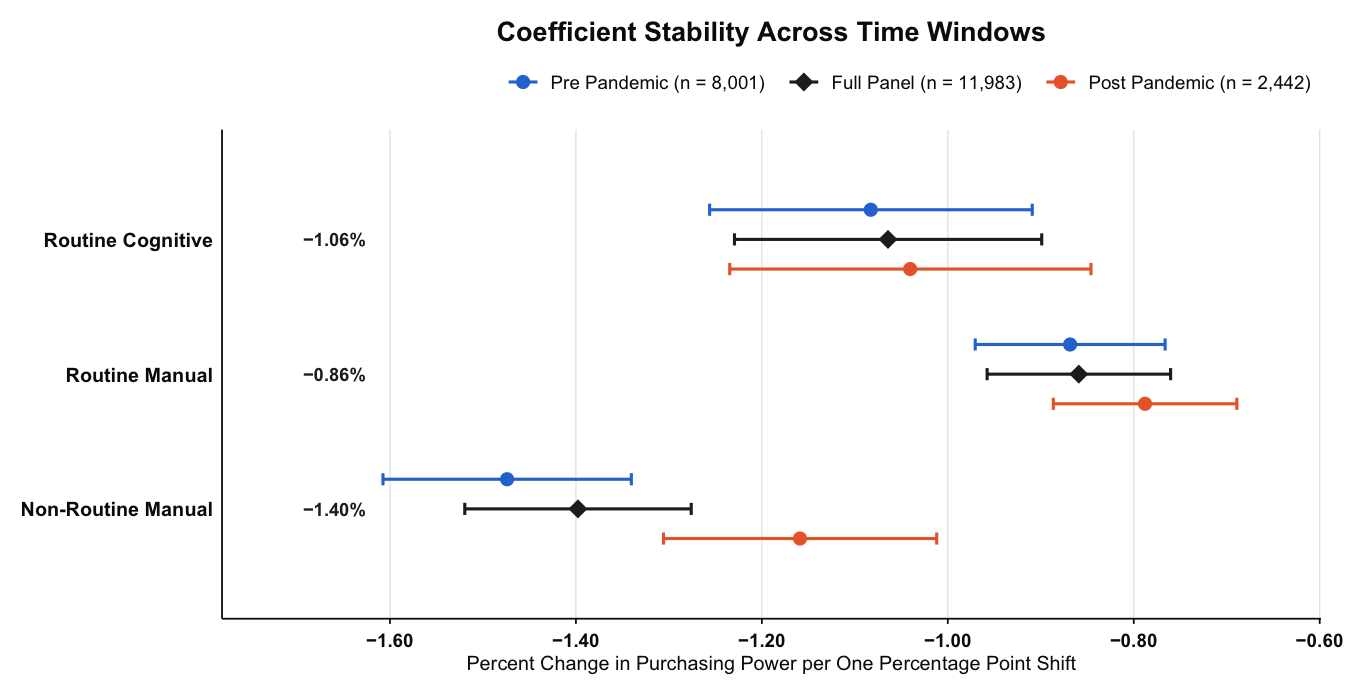

In [92]:
%%R -i stab_long -i window_key -w 9 -h 4.6 -u in -r 150 -b transparent
BLACK <- "#252525"

# rows read top to bottom in the order the prose introduces them, so the first level
# sits at the bottom of a discrete y axis
group_order <- c("Non-Routine Manual", "Routine Manual", "Routine Cognitive")
window_order <- c("2010 to 2019", "Full panel", "2021 to 2023")
stab_long$window <- factor(stab_long$window, levels=window_order)
stab_long$`Task group` <- factor(stab_long$`Task group`, levels=group_order)

# the two windows take the project's blue/orange contrast pair; green is reserved for
# a preferred specification, which neither window is
window_colors <- c("2010 to 2019"="#2A78D6", "Full panel"=BLACK, "2021 to 2023"="#EB6834")
window_shapes <- c("2010 to 2019"=16, "Full panel"=18, "2021 to 2023"=16)
window_sizes  <- c("2010 to 2019"=2.9, "Full panel"=4.0, "2021 to 2023"=2.9)

window_key$window <- factor(window_key$window, levels=window_order)
window_key <- window_key[order(window_key$window), ]
window_labels <- setNames(window_key$legend_label, as.character(window_key$window))

# an explicit offset rather than position_dodge, so the pre pandemic estimate sits
# above the full panel diamond and the post pandemic estimate below it
offsets <- c("2010 to 2019"=0.22, "Full panel"=0, "2021 to 2023"=-0.22)
stab_long$yy <- as.numeric(stab_long$`Task group`) + offsets[as.character(stab_long$window)]

# only the full panel estimate is labelled: three numbers per row collided, and the
# other two windows are read off position against the interval they sit in. The label
# sits at the left margin rather than beside its diamond, which the dodged intervals
# above and below leave no clear room for.
x_lo <- min(stab_long$ci_lo); x_hi <- max(stab_long$ci_hi)
x_span <- x_hi - x_lo
full_lab <- subset(stab_long, window == "Full panel")
full_lab$lx <- x_lo - 0.02 * x_span
full_lab$label <- sub("-", "−", sprintf("%.2f%%", full_lab$value))

ggplot(stab_long, aes(x=value, y=yy, color=window)) +
  geom_errorbarh(aes(xmin=ci_lo, xmax=ci_hi), height=0.09, linewidth=0.7) +
  geom_point(aes(shape=window, size=window)) +
  geom_text(data=full_lab, aes(x=lx, label=label), color=BLACK,
            hjust=1, size=3.1, fontface="bold", show.legend=FALSE) +
  scale_color_manual(values=window_colors, labels=window_labels, name=NULL) +
  scale_shape_manual(values=window_shapes, labels=window_labels, name=NULL) +
  scale_size_manual(values=window_sizes, labels=window_labels, name=NULL) +
  scale_y_continuous(breaks=seq_along(group_order), labels=group_order,
                     expand=expansion(add=c(0.55, 0.55))) +
  scale_x_continuous(breaks=scales::pretty_breaks(n=6),
                     labels=function(v) sub("-", "−", sprintf("%.2f", v))) +
  # coord_cartesian rather than scale limits, so nothing is dropped from the fit data
  coord_cartesian(xlim=c(x_lo - 0.13 * x_span, x_hi + 0.04 * x_span)) +
  guides(color=guide_legend(nrow=1), shape=guide_legend(nrow=1), size=guide_legend(nrow=1)) +
  labs(title="Coefficient Stability Across Time Windows",
       x="Percent Change in Purchasing Power per One Percentage Point Shift",
       y=NULL) +
  # light vertical gridlines only; the shared theme blanks every gridline and tick
  theme(axis.text.y=element_text(face="bold", size=9.5),
        panel.grid.major.x=element_line(color="#E4E3DE", linewidth=0.25),
        panel.border=element_blank(),
        legend.position="top",
        legend.justification="right",
        legend.direction="horizontal",
        legend.key.spacing.x=unit(10, "pt"),
        legend.text=element_text(size=9),
        axis.ticks.x=element_line(color="#0B0B0B", linewidth=0.4),
        axis.ticks.length.x=unit(2.5, "pt"))

The results revealed that county task groups continued to be linked to purchasing power even after accounting for factors such as poverty, unemployment, population, and the year. The largest difference was observed between non-routine manual work and other tasks. A one percentage point shift from non-routine cognitive work to non-routine manual work was associated with a reduction in purchasing power of approximately \$846 at the panel mean, with a 95% confidence interval of ±\$38. Routine cognitive and routine manual work were also negatively associated with purchasing power compared to non-routine cognitive work. Among the variables examined, poverty showed the strongest association with purchasing power, with each additional percentage point associated with a reduction of approximately 2.9%. The random forest analysis indicated that task groups provided additional information beyond the economic controls. Removing the task groups and refitting the model reduced the held out R² by 0.042, while removing poverty and unemployment reduced it by 0.178. Jointly permuting the task groups further reduced the R² value by 0.153, compared to 0.128 for year indicators and 0.008 for state indicators. The geographic analysis showed that counties dominated by non-routine cognitive work had higher purchasing power, while counties dominated by the two manual groups had lower purchasing power. The stability analysis demonstrated that these county differences persisted over time. Routine manual and non-routine cognitive work maintained the most consistent county ordering between 2010 and 2023, while routine cognitive work exhibited the greatest movement. The ordering of the task group coefficients remained unchanged in the full panel, 2010 to 2019, and 2021 to 2023.

The level model, log linear model, random forest, and neural network were compared to find the most suitable representation of the relationship. The level specification produced negative task group associations but showed systematic curvature in the residuals, suggesting that a constant dollar difference across the purchasing power distribution was inadequate. Logging purchasing power reduced residual skew from 1.01 to 0.09, resulting in an in-sample R² of 0.913 and a held-out R² of 0.896. The random forest captured the nonlinear structure visible in the level model but did not improve held-out performance. Its log target specification achieved a held-out R² of 0.877, 0.019 below the log linear model, while the raw target random forest achieved a training R² of 0.989 but only 0.876 on held-out counties. The neural network added further flexibility, but regularization did not improve on either of the other models. Five-fold grouped cross-validation yielded similar general comparisons, with the difference between the log linear and random forest models remaining smaller than the variation across folds. Across these four specifications, the log linear model preserved the task group associations, resolved most of the diagnostic problems in the level model, and scored highest on held-out counties. The implications and limitations of these results are discussed in <a href="#sec-conclusions" class="quarto-xref">Section 6</a>.

# Conclusions

## Summary of findings

Across all counties analyzed over a span of fifteen years, county task groups remained linked to purchasing power after accounting for poverty, unemployment, population, and year. The largest difference was observed for non-routine manual work. A one percentage point shift from non-routine cognitive to non-routine manual work was associated with approximately \$846 lower purchasing power on average, with a 95% confidence interval of ±\$38. Routine cognitive and routine manual work were also negatively associated with purchasing power relative to non-routine cognitive work. Among the variables examined, poverty demonstrated the strongest association with purchasing power, with each additional percentage point associated with approximately 2.9% lower purchasing power. The task groups still carried information beyond these conventional economic measures. Removing them and refitting the random forest reduced the held out R² by 0.042, while jointly permuting them reduced it by 0.153. In comparison, permuting the year indicators reduced R² by 0.128, and permuting the state indicators reduced it by only 0.008.

The sequence of models showed which representation of the relationship the data supported. The level specification identified negative associations but revealed systematic curvature in the residuals, suggesting that a constant dollar relationship was inadequate for the data. Logging purchasing power reduced the residual skew from 1.01 to 0.09, resulting in an in-sample R² of 0.913 and a held-out R² of 0.896. The random forest analysis explored whether nonlinear relationships and interactions improved upon this specification, but its log target version achieved a held-out R² of 0.877. The raw target random forest also demonstrated a closer fit to the training data compared to unseen counties, with R² values of 0.989 and 0.876, respectively. The neural network introduced even greater flexibility but failed to yield further improvements after regularization. Five-fold grouped cross-validation yielded similar general comparisons, with differences between the log linear model and random forest being smaller than the variation across folds. Geographic and stability analyses extended these results beyond model performance. County task group differences persisted from 2010 to 2023, and the ordering of the task group coefficients remained consistent across the entire panel, 2010 to 2019, and 2021 to 2023.

The study also clarified the scope of its findings regarding automation and affordability. The analysis did not measure automation adoption, job displacement, or the likelihood of specific counties losing jobs to new technologies. Instead, it examined the types of tasks already present in county employment and assessed their association with purchasing power. Counties with higher concentrations of routine and manual work, which are often emphasized in the automation literature, tended to have lower purchasing power compared to counties with more non-routine cognitive work. This relationship persisted after adjustment and remained consistent across geography and time. However, it did not establish a causal link between automation and purchasing power differences. Therefore, the study indirectly addressed automation by identifying regions where task structures commonly associated with higher automation potential coincided with lower purchasing power. The consequences of actual technological displacement remain for future research.

## Contributions

The first contribution shifted the outcome from nominal income to purchasing power. Median household income was adjusted using BEA RPPs, directly incorporating local price differences into the measure of household resources. This adjustment distinguished counties with similar nominal incomes where the same income supported varying levels of purchasing power. Instead of comparing income alone, the study examined what that income could purchase after accounting for local price variations.

The second contribution measured task groups at the county level and tracked them over time. The final panel comprised 840 counties from 2008 to 2023, excluding 2020, and represented approximately 84% of the U.S. population. Using counties provided a finer geographic scale than broader labor market areas and directly connected task groups with local purchasing power, poverty, and unemployment. The panel structure demonstrated that these differences were not confined to a single point in time. County task group patterns remained relatively consistent throughout the study period, enabling the analysis to distinguish enduring differences between counties from short-term changes within them.

The county-level analysis also showed that task groups contained information beyond conventional measures of local economic conditions. Removing the task groups and refitting the random forest reduced the held-out R² by 0.042, while jointly permuting them reduced it by 0.153. Poverty exhibited a stronger association with purchasing power than any individual task group, but poverty and unemployment did not fully capture the information contained within the task groups. Counties that appeared similar on these conventional measures could still differ in the types of work residents performed and the purchasing power associated with those differences.

The third contribution determined the most appropriate representation of the relationship between task groups and purchasing power. The level specification revealed systematic residual curvature, while logging purchasing power reduced residual skew from 1.01 to 0.09 and achieved a held-out R² of 0.896. The random forest model achieved 0.877 on the same held-out counties, and a three-hidden-layer neural network provided no further improvement. Therefore, greater model flexibility did not enhance held-out performance once purchasing power was represented proportionally. The contribution lay in applying those models to test whether the data supported a more complex representation of the relationship.

These contributions resulted in a practical framework for comparing local economic conditions. Purchasing power indicated the extent to which household income extended after accounting for local prices, while task groups described the types of work comprising county employment. Consequently, combining the two revealed differences that income, poverty, or unemployment alone could not fully capture. Counties with similar values on conventional economic indicators could still differ in both their task groups and purchasing power. The framework provided policymakers and economic development organizations with a reproducible method to examine local economic conditions using publicly available data.

## Limitations

Five limitations defined the scope of the results. First, the findings were correlational rather than causal. Counties were not randomly assigned to task groups, and the analysis could not isolate task groups from all other characteristics that varied across places. Unobserved factors related to both county employment and purchasing power could therefore contribute to the estimated relationship. The results showed that task groups remained associated with purchasing power after accounting for the measured controls, but they did not establish that differences in task groups caused differences in purchasing power.

Second, the analytical panel was limited to counties above the population threshold required for the occupational data. The final sample included 840 counties, representing approximately 84% of the U.S. population, but smaller and more rural counties were underrepresented. The estimates described the more populous counties included in the panel rather than all U.S. counties. Relationships in counties below the threshold could differ from those observed in the analytical sample.

Third, the geographic precision of RPPs varied across counties. A majority of panel observations relied on a state-level price parity rather than a more local measure, which made purchasing power less geographically precise for those observations. Some within-state differences in local prices were not captured by the outcome. The analysis applied these measures consistently but did not separately test whether the association differed according to the geographic precision of the price measure.

Fourth, purchasing power was measured in nominal dollars, which were not adjusted for changes in the national price level over time. RPPs corrected for price differences within a given year but did not place dollars from different years on a common scale. The year indicators absorbed any shared national price change across all counties. The task group and control coefficients were unaffected. The year coefficients themselves combined inflation with other national conditions that fluctuated between years. They could not be read as a measure of inflation alone. Consequently, dollar comparisons across years represented nominal amounts rather than constant purchasing power.

Finally, the primary panel regression did not include state indicators. Unmeasured state-level differences could have contributed to the estimated associations. The predictive models provided a partial check by including state indicators alongside task groups, poverty, unemployment, and year. Permuting the state indicators reduced the held-out R² by only 0.008, indicating that they contributed relatively little predictive information in that specification. However, the predictive models and panel regression were not identical, and this result did not eliminate the possibility of state-level confounding in the primary estimates.

## Ethical considerations

The study required clear boundaries on how the results were interpreted. Since the county was the unit of analysis, the findings described places rather than individual workers. Applying county-level relationships to individuals would constitute an ecological fallacy. Consequently, the results could not be used to infer a worker’s purchasing power, economic vulnerability, or likelihood of being affected by automation based on their task group.

Representation also necessitated caution. Counties were excluded because occupational data were unavailable below the source publication threshold, not due to an analysis-driven decision. As a result, smaller and more rural counties were underrepresented in the panel. Extending the findings to those counties would require extrapolation beyond the observed data, which was particularly important when comparing geographic patterns or identifying places that might warrant further attention.

The data also carried a selection bias that the analysis could not eliminate. The publication threshold excluded smaller counties before constructing the analytical sample, resulting in a panel that was not a random representation of all U.S. counties. Consequently, rural and less populous counties were underrepresented, making the results more accurate for the included counties than for those excluded by the threshold. This limitation matters because smaller rural counties are often central to discussions about automation and local economic vulnerability.

The associational nature of the findings also limited their use for policy decisions. Treating the estimated relationships as causal could lead to the allocation of resources to change a county’s task groups even if an unmeasured economic or geographic factor contributed to the observed difference. While the results supported identifying where lower purchasing power and specific task groups coexisted, they did not establish which intervention would alter those conditions. Similarly, the language used to describe counties required similar care. Labeling places based on presumed automation risk or economic vulnerability could stigmatize communities or deter investment based on relationships that the study did not establish causally.

Finally, the study relied entirely on publicly available aggregate data. No individual-level records or personally identifiable information entered the analytical dataset, and all reported results described county-level patterns rather than individual people.

## Future directions

Three directions emerge from these limitations. The first is the coverage gap, which could potentially be bridged using satellite imagery. Jean et al. ([2016](#ref-Jean2016))’s estimate of local economic conditions from daytime and nighttime imagery, where survey data are scarce, could be applied here. This approach could generate purchasing power estimates for counties below the ACS publication threshold and assess whether the geographic patterns observed in this study extend to areas outside the analytical panel. This would not expand the task group association itself, because comparable occupational estimates would still be unavailable for those counties. It would still show whether the spatial patterns reported here reflect the country more broadly rather than the more populous counties in the sample.

A second direction is to extend the study beyond 2008-2023 as additional occupational, income, price, poverty, and unemployment data become available. The current analysis revealed that the ordering of the task group associations remained stable across the entire panel and across 2010-2019 and 2021-2023. Extending the panel would directly test whether these relationships persist as local labor markets continue to evolve. Additionally, it would allow the results reported here to be evaluated out of time using observations that were not available when the original models were developed. Replicating the direction, magnitude, and proportional form of the associations in later years would provide stronger evidence that the patterns identified in this study were enduring rather than specific to the observed period.

The third approach is to investigate the underlying reasons for the correlation between task groups and purchasing power. Establishing a causal relationship would necessitate identifying a source of variation in task groups that was not influenced by local purchasing power. This could be achieved through factors such as plant openings and closures, major changes in production technology, or identifiable technology adoption shocks. Such an analysis would require a separate study with distinct data and a research design capable of isolating plausible exogenous changes in local task groups. Such an analysis would go beyond confirming the association observed in this study. It would show whether changes in the types of work performed within a county are accompanied by shifts in purchasing power.

## Conclusion

This study discovered a consistent link between county task groups and purchasing power. Counties with higher concentrations of routine and manual work generally had lower purchasing power compared to those with more non-routine cognitive work, even after accounting for factors like poverty, unemployment, population, and year. The largest difference was observed for non-routine manual work. At the panel mean, a one percentage point shift from non-routine cognitive to non-routine manual work was associated with approximately \$846 lower purchasing power, with a 95% confidence interval of ±\$38.

The relationship persisted across both time and model specifications. County task group patterns remained relatively stable over the fifteen-year panel, and the ordering of the estimated associations remained consistent across the examined periods. Diagnostic testing revealed that the relationship was better represented proportionally than as a constant dollar difference. The log linear specification also achieved stronger held-out performance compared to the random forest, while the neural network provided no further improvement. These results suggested that additional model complexity was unnecessary to capture the primary relationship observed in the data.

The findings did not establish a causal relationship between task groups and purchasing power, nor did the study directly measure automation adoption or job displacement. Instead, the results indicated that the types of work concentrated within a county provided information about purchasing power beyond poverty, unemployment, population, and year. While poverty remained an important indicator of local economic conditions, it did not fully explain the association between task groups and purchasing power. Counties with higher concentrations of routine and manual work consistently exhibited lower purchasing power across geography and time. Therefore, understanding differences in purchasing power across counties required considering household income, local prices, and the types of work that characterized the local economy.

# References

Abadi, Martín, Ashish Agarwal, Paul Barham, Eugene Brevdo, Zhifeng Chen, Craig Citro, Greg S. Corrado, et al. 2016. “TensorFlow: Large-Scale Machine Learning on Heterogeneous Distributed Systems.” <https://www.tensorflow.org/>.

Acemoglu, Daron, and David Autor. 2011. “Skills, Tasks and Technologies: Implications for Employment and Earnings.” In *Handbook of Labor Economics*, edited by David Card and Orley Ashenfelter, 4:1043–1171. Elsevier. <https://doi.org/10.1016/S0169-7218(11)02410-5>.

Autor, David H., and David Dorn. 2013. “The Growth of Low-Skill Service Jobs and the Polarization of the US Labor Market.” *American Economic Review* 103 (5): 1553–97. <https://doi.org/10.1257/aer.103.5.1553>.

Autor, David H., Frank Levy, and Richard J. Murnane. 2003. “The Skill Content of Recent Technological Change: An Empirical Exploration.” *The Quarterly Journal of Economics* 118 (4): 1279–1333. <https://doi.org/10.1162/003355303322552801>.

Chiripanhura, Blessing. 2011. “Median and Mean Income Analyses: Their Implications for Material Living Standards and National Well-Being.” *Economic & Labour Market Review* 5: 45–63. <https://doi.org/10.1057/elmr.2011.17>.

Couch, Kenneth A., and Dana W. Placzek. 2010. “Earnings Losses of Displaced Workers Revisited.” *American Economic Review* 100 (1): 572–89. <https://doi.org/10.1257/aer.100.1.572>.

Cozzi, Marco, and Giulio Fella. 2016. “Job Displacement Risk and Severance Pay.” *Journal of Monetary Economics* 84: 166–81. <https://doi.org/10.1016/j.jmoneco.2016.11.001>.

Curran, Leah Beth, Harold Wolman, Edward W. Hill, and Kimberly Furdell. 2006. “Economic Wellbeing and Where We Live: Accounting for Geographical Cost-of-Living Differences in the US.” *Urban Studies* 43 (13): 2443–66. <https://doi.org/10.1080/00420980600970698>.

Harris, Charles R., K. Jarrod Millman, Stéfan J. van der Walt, Ralf Gommers, Pauli Virtanen, David Cournapeau, Eric Wieser, et al. 2020. “Array Programming with NumPy.” *Nature* 585 (7825): 357–62. <https://doi.org/10.1038/s41586-020-2649-2>.

Jean, Neal, Marshall Burke, Michael Xie, W. Matthew Davis, David B. Lobell, and Stefano Ermon. 2016. “Combining Satellite Imagery and Machine Learning to Predict Poverty.” *Science* 353 (6301): 790–94. <https://doi.org/10.1126/science.aaf7894>.

Jordahl, Kelsey, Joris Van den Bossche, Martin Fleischmann, Jacob Wasserman, James McBride, Jeffrey Gerard, Jeff Tratner, et al. 2020. “Geopandas/Geopandas.” <https://doi.org/10.5281/zenodo.3946761>.

McKinney, Wes. 2010. “Data Structures for Statistical Computing in Python.” In *Proceedings of the 9th Python in Science Conference*, 56–61. <https://doi.org/10.25080/Majora-92bf1922-00a>.

Moretti, Enrico. 2013. “Real Wage Inequality.” *American Economic Journal: Applied Economics* 5 (1): 65–103. <https://doi.org/10.1257/app.5.1.65>.

Pebesma, Edzer. 2018. “Simple Features for R: Standardized Support for Spatial Vector Data.” *The R Journal* 10 (1): 439–46. <https://doi.org/10.32614/RJ-2018-009>.

Pedersen, Thomas Lin. 2024. *Patchwork: The Composer of Plots*. <https://CRAN.R-project.org/package=patchwork>.

Pedregosa, Fabian, Gaël Varoquaux, Alexandre Gramfort, Vincent Michel, Bertrand Thirion, Olivier Grisel, Mathieu Blondel, et al. 2011. “Scikit-Learn: Machine Learning in Python.” *Journal of Machine Learning Research* 12: 2825–30. <https://jmlr.org/papers/v12/pedregosa11a.html>.

R Core Team. 2024. *R: A Language and Environment for Statistical Computing*. Vienna, Austria: R Foundation for Statistical Computing. <https://www.R-project.org/>.

Saad, Lydia. 2023. “More U.S. Workers Fear Technology Making Their Jobs Obsolete.” Gallup. <https://news.gallup.com/poll/510551/workers-fear-technology-making-jobs-obsolete.aspx>.

Seabold, Skipper, and Josef Perktold. 2010. “Statsmodels: Econometric and Statistical Modeling with Python.” In *Proceedings of the 9th Python in Science Conference*, 92–96. <https://doi.org/10.25080/Majora-92bf1922-011>.

Smith, Aaron, and Monica Anderson. 2017. “Automation in Everyday Life.” Pew Research Center. <https://www.pewresearch.org/internet/2017/10/04/automation-in-everyday-life/>.

U.S. Bureau of Economic Analysis. 2024. “Regional Price Parities by State and Metro Area.” <https://www.bea.gov/data/prices-inflation/regional-price-parities-state-and-metro-area>.

U.S. Bureau of Labor Statistics. 2024. “Local Area Unemployment Statistics.” <https://www.bls.gov/lau/>.

U.S. Census Bureau. 2023a. “Core Based Statistical Area Delineation Files.” <https://www.census.gov/geographies/reference-files/time-series/demo/metro-micro/delineation-files.html>.

———. 2023b. “Vintage 2023 Population Estimates.” <https://www.census.gov/programs-surveys/popest.html>.

———. 2024a. “American Community Survey 1-Year Estimates.” <https://www.census.gov/programs-surveys/acs>.

———. 2024b. “Small Area Income and Poverty Estimates.” <https://www.census.gov/programs-surveys/saipe.html>.

Virtanen, Pauli, Ralf Gommers, Travis E. Oliphant, Matt Haberland, Tyler Reddy, David Cournapeau, Evgeni Burovski, et al. 2020. “SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python.” In *Nature Methods*, 17:261–72. <https://doi.org/10.1038/s41592-019-0686-2>.

Wickham, Hadley. 2016. *Ggplot2: Elegant Graphics for Data Analysis*. Springer-Verlag New York. <https://ggplot2-book.org/>.

Wickham, Hadley, Thomas Lin Pedersen, and Dana Seidel. 2023. *Scales: Scale Functions for Visualization*. <https://CRAN.R-project.org/package=scales>.

## Software

Data processing, statistical modeling, and machine learning were conducted in Python using pandas, NumPy, SciPy, statsmodels, scikit-learn, TensorFlow, and GeoPandas ([McKinney 2010](#ref-pandas2010); [Harris et al. 2020](#ref-numpy2020); [Virtanen et al. 2020](#ref-scipy2020); [Seabold and Perktold 2010](#ref-statsmodels2010); [Pedregosa et al. 2011](#ref-sklearn2011); [Abadi et al. 2016](#ref-tensorflow2016); [Jordahl et al. 2020](#ref-geopandas2020)). Figures were produced in R using ggplot2, patchwork, scales, and sf ([R Core Team 2024](#ref-rcoreteam2024); [Wickham 2016](#ref-ggplot2_2016); [Pedersen 2024](#ref-patchwork2024); [Wickham, Pedersen, and Seidel 2023](#ref-scales2023); [Pebesma 2018](#ref-sf2018)).